In [1]:
import os
import sys
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Pandas version: 2.3.3
NumPy version: 2.2.6


In [2]:
from pathlib import Path

current_path = Path.cwd()

print("Current working directory:")
print(current_path)

Current working directory:
C:\Users\PRITI PRAKASH\Summer Internship 2026


In [3]:
files = list(current_path.iterdir())

for file in files:
    print(file)

C:\Users\PRITI PRAKASH\Summer Internship 2026\.ipynb_checkpoints
C:\Users\PRITI PRAKASH\Summer Internship 2026\accepted_2007_to_2018Q4.csv
C:\Users\PRITI PRAKASH\Summer Internship 2026\accepted_2007_to_2018Q4.zip
C:\Users\PRITI PRAKASH\Summer Internship 2026\deepsurv_feature_importance.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\deepsurv_individual_curves.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwin 2.ipynb
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwinai_combined_score.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwinai_evaluation.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwinai_gnn_graph.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwinai_gnn_training.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwinai_health_score.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwinai_shap_beeswarm.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwinai_shap_global.png
C:\Users\PRITI PRAKASH\Summer Internship 2026\fintwinai_shap_i

In [4]:
search_locations = [
    Path.cwd(),
    Path.home() / "Downloads",
    Path.home() / "Documents",
    Path("/mnt/data")
]

dataset_files = []

for location in search_locations:
    if location.exists():
        for pattern in ["*.csv", "*.zip"]:
            dataset_files.extend(location.rglob(pattern))

print("Possible dataset files:\n")

for file in dataset_files:
    print(file)

Possible dataset files:

C:\Users\PRITI PRAKASH\Summer Internship 2026\accepted_2007_to_2018Q4.csv
C:\Users\PRITI PRAKASH\Summer Internship 2026\output\lendingclub_cleaned_week1.csv
C:\Users\PRITI PRAKASH\Summer Internship 2026\output\lendingclub_feature_importance.csv
C:\Users\PRITI PRAKASH\Summer Internship 2026\output\.ipynb_checkpoints\lendingclub_cleaned_week1-checkpoint.csv
C:\Users\PRITI PRAKASH\Summer Internship 2026\accepted_2007_to_2018Q4.zip
C:\Users\PRITI PRAKASH\Downloads\FOR LOGISTIC REGRESSION (1).csv
C:\Users\PRITI PRAKASH\Downloads\FOR LOGISTIC REGRESSION.csv
C:\Users\PRITI PRAKASH\Downloads\backend.zip
C:\Users\PRITI PRAKASH\Downloads\complaints.csv.zip
C:\Users\PRITI PRAKASH\Downloads\creditcard.csv.zip
C:\Users\PRITI PRAKASH\Downloads\drive-download-20230329T202836Z-001.zip
C:\Users\PRITI PRAKASH\Downloads\gemh1dd.zip
C:\Users\PRITI PRAKASH\Downloads\ghmh1dd.zip
C:\Users\PRITI PRAKASH\Downloads\hitman_2_avatars.zip
C:\Users\PRITI PRAKASH\Downloads\hitman_2_manual.zi

In [5]:
zip_path = Path(
    r"C:\Users\PRITI PRAKASH\Summer Internship 2026\accepted_2007_to_2018Q4.zip"
)

print("ZIP exists:", zip_path.exists())
print("ZIP path:", zip_path)

ZIP exists: True
ZIP path: C:\Users\PRITI PRAKASH\Summer Internship 2026\accepted_2007_to_2018Q4.zip


In [6]:
if zip_path.exists():

    with zipfile.ZipFile(zip_path, "r") as zip_ref:

        file_names = zip_ref.namelist()

        print("Number of files:", len(file_names))
        print("\nFiles inside ZIP:\n")

        for name in file_names:
            print(name)

else:
    print("ZIP file not found. Check the path.")

Number of files: 1

Files inside ZIP:

accepted_2007_to_2018Q4.csv


In [7]:
if zip_path.exists():

    with zipfile.ZipFile(zip_path, "r") as zip_ref:

        zip_information = []

        for info in zip_ref.infolist():

            zip_information.append({
                "filename": info.filename,
                "compressed_size_MB": round(
                    info.compress_size / (1024 ** 2), 2
                ),
                "original_size_MB": round(
                    info.file_size / (1024 ** 2), 2
                )
            })

        zip_df = pd.DataFrame(zip_information)

        display(zip_df)

else:
    print("ZIP file not found.")

,filename,compressed_size_MB,original_size_MB
0,accepted_2007_to_2018Q4.csv,391.04,1597.53


In [8]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:

    csv_files = [
        name for name in zip_ref.namelist()
        if name.lower().endswith(".csv")
    ]

print("CSV files found:")

for csv_file in csv_files:
    print(csv_file)

CSV files found:
accepted_2007_to_2018Q4.csv


In [9]:
if len(csv_files) == 0:

    print("No CSV file found inside the ZIP.")

else:

    csv_name = csv_files[0]

    with zipfile.ZipFile(zip_path, "r") as zip_ref:

        with zip_ref.open(csv_name) as file:

            sample_df = pd.read_csv(
                file,
                nrows=1000,
                low_memory=False
            )

    print("Sample shape:", sample_df.shape)

    display(sample_df.head())

Sample shape: (1000, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print("Number of rows in sample:", sample_df.shape[0])
print("Number of columns:", sample_df.shape[1])

print("\nColumn names:\n")

for i, column in enumerate(sample_df.columns, start=1):
    print(i, "→", column)

Number of rows in sample: 1000
Number of columns: 151

Column names:

1 → id
2 → member_id
3 → loan_amnt
4 → funded_amnt
5 → funded_amnt_inv
6 → term
7 → int_rate
8 → installment
9 → grade
10 → sub_grade
11 → emp_title
12 → emp_length
13 → home_ownership
14 → annual_inc
15 → verification_status
16 → issue_d
17 → loan_status
18 → pymnt_plan
19 → url
20 → desc
21 → purpose
22 → title
23 → zip_code
24 → addr_state
25 → dti
26 → delinq_2yrs
27 → earliest_cr_line
28 → fico_range_low
29 → fico_range_high
30 → inq_last_6mths
31 → mths_since_last_delinq
32 → mths_since_last_record
33 → open_acc
34 → pub_rec
35 → revol_bal
36 → revol_util
37 → total_acc
38 → initial_list_status
39 → out_prncp
40 → out_prncp_inv
41 → total_pymnt
42 → total_pymnt_inv
43 → total_rec_prncp
44 → total_rec_int
45 → total_rec_late_fee
46 → recoveries
47 → collection_recovery_fee
48 → last_pymnt_d
49 → last_pymnt_amnt
50 → next_pymnt_d
51 → last_credit_pull_d
52 → last_fico_range_high
53 → last_fico_range_low
54 → coll

In [11]:
dtype_df = pd.DataFrame({
    "column": sample_df.columns,
    "dtype": sample_df.dtypes.astype(str).values,
    "missing_count": sample_df.isna().sum().values,
    "missing_percentage": (
        sample_df.isna().mean().values * 100
    ).round(2)
})

display(dtype_df)

,column,dtype,missing_count,missing_percentage
0,id,int64,0,0.0
1,member_id,float64,1000,100.0
2,loan_amnt,float64,0,0.0
3,funded_amnt,float64,0,0.0
4,funded_amnt_inv,float64,0,0.0
...,...,...,...,...
146,settlement_status,object,978,97.8
147,settlement_date,object,978,97.8
148,settlement_amount,float64,978,97.8
149,settlement_percentage,float64,978,97.8


In [12]:
duplicate_count = sample_df.duplicated().sum()

print("Duplicate rows in sample:", duplicate_count)

Duplicate rows in sample: 0


In [13]:
sample_df.describe(
    include="all"
).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1000.0,NaN,NaN,NaN,68362706.365,392743.665605,65916558.0,68376699.5,68465560.5,68537609.25,68617057.0
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,1000.0,NaN,NaN,NaN,15582.2,8694.53143,1000.0,9000.0,15000.0,21000.0,35000.0
funded_amnt,1000.0,NaN,NaN,NaN,15582.2,8694.53143,1000.0,9000.0,15000.0,21000.0,35000.0
funded_amnt_inv,1000.0,NaN,NaN,NaN,15582.2,8694.53143,1000.0,9000.0,15000.0,21000.0,35000.0
...,...,...,...,...,...,...,...,...,...,...,...
settlement_status,22,3,COMPLETE,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settlement_date,22,15,May-2018,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settlement_amount,22.0,NaN,NaN,NaN,4677.728182,3424.722231,303.0,2737.0,4163.155,6122.14,13403.0
settlement_percentage,22.0,NaN,NaN,NaN,46.675455,3.887082,44.93,45.0,45.0,45.02,60.01


In [14]:
csv_name = "accepted_2007_to_2018Q4.csv"

print("CSV filename:", csv_name)

CSV filename: accepted_2007_to_2018Q4.csv


In [15]:
total_rows = 0
chunk_size = 100_000

with zipfile.ZipFile(zip_path, "r") as zip_ref:

    with zip_ref.open(csv_name) as file:

        for chunk in pd.read_csv(
            file,
            chunksize=chunk_size,
            low_memory=False
        ):

            total_rows += len(chunk)

            print(
                f"Processed rows: {total_rows:,}",
                end="\r"
            )

print("\n")
print("Total rows in complete dataset:", f"{total_rows:,}")

Processed rows: 2,260,701

Total rows in complete dataset: 2,260,701


In [16]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:

    with zip_ref.open(csv_name) as file:

        dtype_sample = pd.read_csv(
            file,
            nrows=1000,
            low_memory=False
        )

dtype_summary = pd.DataFrame({
    "Column": dtype_sample.columns,
    "Data Type": dtype_sample.dtypes.astype(str).values,
    "Missing Values": dtype_sample.isna().sum().values,
    "Missing Percentage": (
        dtype_sample.isna().mean().values * 100
    ).round(2)
})

display(dtype_summary)

,Column,Data Type,Missing Values,Missing Percentage
0,id,int64,0,0.0
1,member_id,float64,1000,100.0
2,loan_amnt,float64,0,0.0
3,funded_amnt,float64,0,0.0
4,funded_amnt_inv,float64,0,0.0
...,...,...,...,...
146,settlement_status,object,978,97.8
147,settlement_date,object,978,97.8
148,settlement_amount,float64,978,97.8
149,settlement_percentage,float64,978,97.8


In [17]:
missing_summary = pd.DataFrame({
    "Column": dtype_sample.columns,
    "Missing Count": dtype_sample.isna().sum().values,
    "Missing Percentage": (
        dtype_sample.isna().mean().values * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_summary.head(30))

,Column,Missing Count,Missing Percentage
1,member_id,1000,100.0
19,desc,1000,100.0
123,sec_app_open_act_il,1000,100.0
119,sec_app_inq_last_6mths,1000,100.0
121,sec_app_open_acc,1000,100.0
120,sec_app_mort_acc,1000,100.0
127,sec_app_mths_since_last_major_derog,1000,100.0
126,sec_app_collections_12_mths_ex_med,1000,100.0
125,sec_app_chargeoff_within_12_mths,1000,100.0
124,sec_app_num_rev_accts,1000,100.0


In [18]:
target_columns = [
    "loan_status",
    "issue_d",
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d",
    "term",
    "grade",
    "sub_grade"
]

available_target_columns = [
    column for column in target_columns
    if column in dtype_sample.columns
]

display(dtype_sample[available_target_columns].head())

,loan_status,issue_d,last_pymnt_d,next_pymnt_d,last_credit_pull_d,term,grade,sub_grade
0,Fully Paid,Dec-2015,Jan-2019,NaN,Mar-2019,36 months,C,C4
1,Fully Paid,Dec-2015,Jun-2016,NaN,Mar-2019,36 months,C,C1
2,Fully Paid,Dec-2015,Jun-2017,NaN,Mar-2019,60 months,B,B4
3,Current,Dec-2015,Feb-2019,Apr-2019,Mar-2019,60 months,C,C5
4,Fully Paid,Dec-2015,Jul-2016,NaN,Mar-2018,60 months,F,F1


In [19]:
print("Loan status categories:\n")

display(
    dtype_sample["loan_status"]
    .value_counts(dropna=False)
)

Loan status categories:



loan_status
Fully Paid            728
Charged Off           145
Current               121
Late (31-120 days)      5
In Grace Period         1
Name: count, dtype: int64

In [20]:
loan_status_distribution = (
    dtype_sample["loan_status"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
    .reset_index()
)

loan_status_distribution.columns = [
    "Loan Status",
    "Percentage"
]

display(loan_status_distribution)

,Loan Status,Percentage
0,Fully Paid,72.8
1,Charged Off,14.5
2,Current,12.1
3,Late (31-120 days),0.5
4,In Grace Period,0.1


In [21]:
from collections import Counter

full_status_counts = Counter()

with zipfile.ZipFile(zip_path, "r") as zip_ref:

    with zip_ref.open(csv_name) as file:

        for chunk in pd.read_csv(
            file,
            usecols=["loan_status"],
            chunksize=100_000,
            low_memory=False
        ):

            status_counts = chunk["loan_status"].value_counts(
                dropna=False
            )

            for status, count in status_counts.items():
                full_status_counts[status] += int(count)

full_status_df = pd.DataFrame(
    full_status_counts.items(),
    columns=["Loan Status", "Count"]
)

full_status_df["Percentage"] = (
    full_status_df["Count"] / total_rows * 100
).round(2)

full_status_df = full_status_df.sort_values(
    by="Count",
    ascending=False
).reset_index(drop=True)

display(full_status_df)

,Loan Status,Count,Percentage
0,Fully Paid,1076751,47.63
1,Current,878317,38.85
2,Charged Off,268559,11.88
3,Late (31-120 days),21467,0.95
4,In Grace Period,8436,0.37
5,Late (16-30 days),4349,0.19
6,Does not meet the credit policy. Status:Fully ...,1988,0.09
7,Does not meet the credit policy. Status:Charge...,761,0.03
8,Default,40,0.00
9,NaN,33,0.00


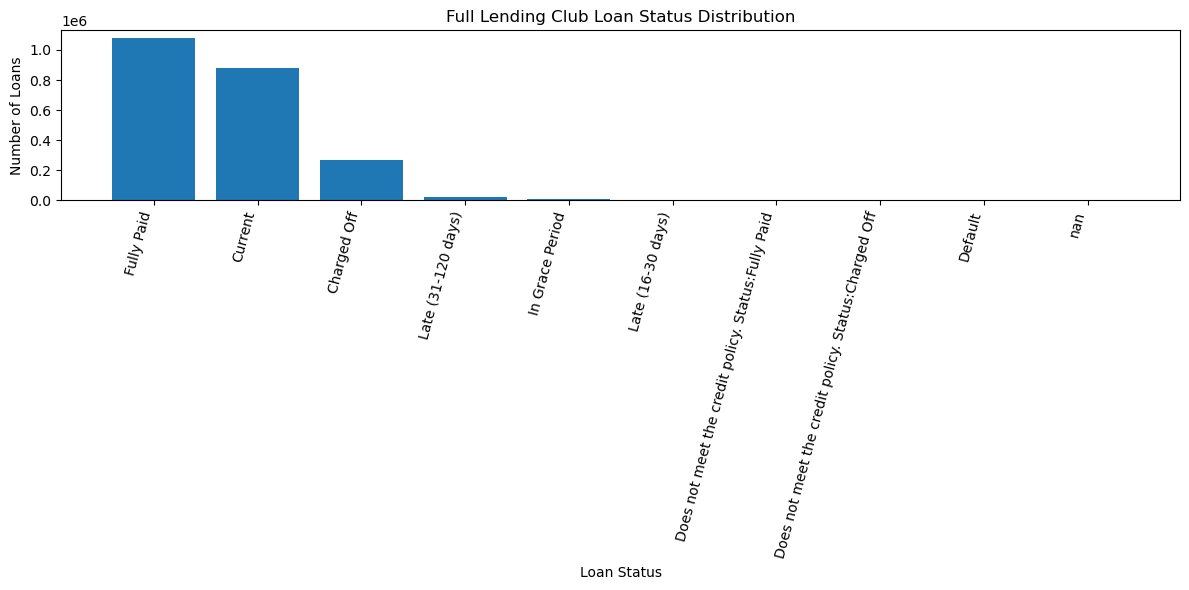

In [22]:
plt.figure(figsize=(12, 6))

plt.bar(
    full_status_df["Loan Status"].astype(str),
    full_status_df["Count"]
)

plt.xticks(rotation=75, ha="right")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.title("Full Lending Club Loan Status Distribution")

plt.tight_layout()
plt.show()

In [23]:
default_statuses = [
    "Charged Off"
]

non_default_statuses = [
    "Fully Paid"
]

excluded_statuses = [
    "Current",
    "Late (31–120 days)",
    "In Grace Period"
]

print("Default statuses:", default_statuses)
print("Non-default statuses:", non_default_statuses)
print("Excluded statuses:", excluded_statuses)

Default statuses: ['Charged Off']
Non-default statuses: ['Fully Paid']
Excluded statuses: ['Current', 'Late (31–120 days)', 'In Grace Period']


In [24]:
usable_statuses = (
    default_statuses +
    non_default_statuses
)

usable_count = full_status_df[
    full_status_df["Loan Status"].isin(usable_statuses)
]["Count"].sum()

excluded_count = total_rows - usable_count

print("Usable binary classification records:", f"{usable_count:,}")
print("Excluded records:", f"{excluded_count:,}")
print(
    "Usable percentage:",
    round(usable_count / total_rows * 100, 2),
    "%"
)

Usable binary classification records: 1,345,310
Excluded records: 915,391
Usable percentage: 59.51 %


In [25]:
issue_dates = []

with zipfile.ZipFile(zip_path, "r") as zip_ref:

    with zip_ref.open(csv_name) as file:

        for chunk in pd.read_csv(
            file,
            usecols=["issue_d"],
            chunksize=100_000,
            low_memory=False
        ):

            issue_dates.extend(
                chunk["issue_d"]
                .dropna()
                .astype(str)
                .unique()
            )

issue_dates = pd.Series(issue_dates).drop_duplicates()

print("Number of unique issue-date values:", len(issue_dates))
print("Issue-date values:")
print(sorted(issue_dates.tolist())[:10])
print("...")
print(sorted(issue_dates.tolist())[-10:])

Number of unique issue-date values: 139
Issue-date values:
['Apr-2008', 'Apr-2009', 'Apr-2010', 'Apr-2011', 'Apr-2012', 'Apr-2013', 'Apr-2014', 'Apr-2015', 'Apr-2016', 'Apr-2017']
...
['Sep-2009', 'Sep-2010', 'Sep-2011', 'Sep-2012', 'Sep-2013', 'Sep-2014', 'Sep-2015', 'Sep-2016', 'Sep-2017', 'Sep-2018']


In [26]:
model_columns = [
    # Identification / time
    "id",
    "issue_d",

    # Loan characteristics
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "term",
    "int_rate",
    "installment",

    # Credit grade
    "grade",
    "sub_grade",

    # Borrower information
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",

    # Loan purpose
    "purpose",

    # Credit risk variables
    "dti",
    "delinq_2yrs",
    "earliest_cr_line",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",

    # Account / credit history
    "acc_now_delinq",
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_open_to_buy",
    "bc_util",

    # Credit age
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl",

    # Mortgage / public record information
    "mort_acc",
    "pub_rec_bankruptcies",
    "tax_liens",

    # Application structure
    "application_type",

    # Target
    "loan_status"
]

print("Number of selected columns:", len(model_columns))

Number of selected columns: 43


In [27]:
missing_model_columns = [
    column
    for column in model_columns
    if column not in dtype_sample.columns
]

if len(missing_model_columns) == 0:
    print("✅ All selected columns exist in the dataset.")
else:
    print("❌ These columns are missing:")
    for column in missing_model_columns:
        print(column)

✅ All selected columns exist in the dataset.


In [28]:
valid_statuses = [
    "Fully Paid",
    "Charged Off",
    "Default"
]

print("Statuses used for initial classification:")
for status in valid_statuses:
    print("→", status)

Statuses used for initial classification:
→ Fully Paid
→ Charged Off
→ Default


In [29]:
model_chunks = []

chunk_size = 100_000

with zipfile.ZipFile(zip_path, "r") as zip_ref:

    with zip_ref.open(csv_name) as file:

        for chunk_number, chunk in enumerate(
            pd.read_csv(
                file,
                usecols=model_columns,
                chunksize=chunk_size,
                low_memory=False
            ),
            start=1
        ):

            # Keep only relevant loan outcomes
            chunk = chunk[
                chunk["loan_status"].isin(valid_statuses)
            ].copy()

            if len(chunk) > 0:
                model_chunks.append(chunk)

            print(
                f"Chunk {chunk_number}: "
                f"{len(chunk):,} usable records | "
                f"Total collected: "
                f"{sum(len(x) for x in model_chunks):,}",
                end="\r"
            )

print("\n")
print("Loading complete.")

Chunk 23: 34,407 usable records | Total collected: 1,345,3508

Loading complete.


In [30]:
df = pd.concat(
    model_chunks,
    ignore_index=True
)

print("Final modelling dataset shape:")
print(df.shape)

Final modelling dataset shape:
(1345350, 43)


In [31]:
del model_chunks

import gc
gc.collect()

print("Temporary chunks deleted.")
print("Current dataset shape:", df.shape)

Temporary chunks deleted.
Current dataset shape: (1345350, 43)


In [32]:
target_distribution = (
    df["loan_status"]
    .value_counts(dropna=False)
    .reset_index()
)

target_distribution.columns = [
    "Loan Status",
    "Count"
]

target_distribution["Percentage"] = (
    target_distribution["Count"]
    / len(df)
    * 100
).round(2)

display(target_distribution)

,Loan Status,Count,Percentage
0,Fully Paid,1076751,80.04
1,Charged Off,268559,19.96
2,Default,40,0.00


In [33]:
df["default"] = (
    df["loan_status"]
    .isin(["Charged Off", "Default"])
    .astype("int8")
)

print("Target created successfully.")

display(
    df["default"]
    .value_counts()
    .rename(index={
        0: "Non-default",
        1: "Default"
    })
)

Target created successfully.


default
Non-default    1076751
Default         268599
Name: count, dtype: int64

In [34]:
target_summary = pd.DataFrame({
    "Class": [
        "Non-default",
        "Default"
    ],
    "Count": [
        (df["default"] == 0).sum(),
        (df["default"] == 1).sum()
    ]
})

target_summary["Percentage"] = (
    target_summary["Count"]
    / len(df)
    * 100
).round(2)

display(target_summary)

,Class,Count,Percentage
0,Non-default,1076751,80.04
1,Default,268599,19.96


In [35]:
print("Total records:", len(df))

duplicate_id_count = df["id"].duplicated().sum()

print("Duplicate loan IDs:", duplicate_id_count)

Total records: 1345350
Duplicate loan IDs: 0


In [36]:
duplicate_row_count = df.duplicated().sum()

print("Duplicate complete rows:", duplicate_row_count)

Duplicate complete rows: 0


In [37]:
memory_mb = df.memory_usage(
    deep=True
).sum() / (1024 ** 2)

print(
    f"Current modelling dataset memory usage: "
    f"{memory_mb:.2f} MB"
)

Current modelling dataset memory usage: 1184.26 MB


In [38]:
df["issue_date"] = pd.to_datetime(
    df["issue_d"],
    format="%b-%Y",
    errors="coerce"
)

print("Date conversion complete.")

print(
    "Minimum issue date:",
    df["issue_date"].min()
)

print(
    "Maximum issue date:",
    df["issue_date"].max()
)

Date conversion complete.
Minimum issue date: 2007-06-01 00:00:00
Maximum issue date: 2018-12-01 00:00:00


In [39]:
df["issue_year"] = df["issue_date"].dt.year
df["issue_month"] = df["issue_date"].dt.month

print(
    df[
        [
            "issue_d",
            "issue_date",
            "issue_year",
            "issue_month"
        ]
    ].head(10)
)

    issue_d issue_date  issue_year  issue_month
0  Dec-2015 2015-12-01        2015           12
1  Dec-2015 2015-12-01        2015           12
2  Dec-2015 2015-12-01        2015           12
3  Dec-2015 2015-12-01        2015           12
4  Dec-2015 2015-12-01        2015           12
5  Dec-2015 2015-12-01        2015           12
6  Dec-2015 2015-12-01        2015           12
7  Dec-2015 2015-12-01        2015           12
8  Dec-2015 2015-12-01        2015           12
9  Dec-2015 2015-12-01        2015           12


In [40]:
year_distribution = (
    df["issue_year"]
    .value_counts()
    .sort_index()
)

display(
    year_distribution.to_frame("Number of Loans")
)

,Number of Loans
issue_year,
2007,251
2008,1562
2009,4716
2010,11536
2011,21721
2012,53367
2013,134804
2014,223103
2015,375546


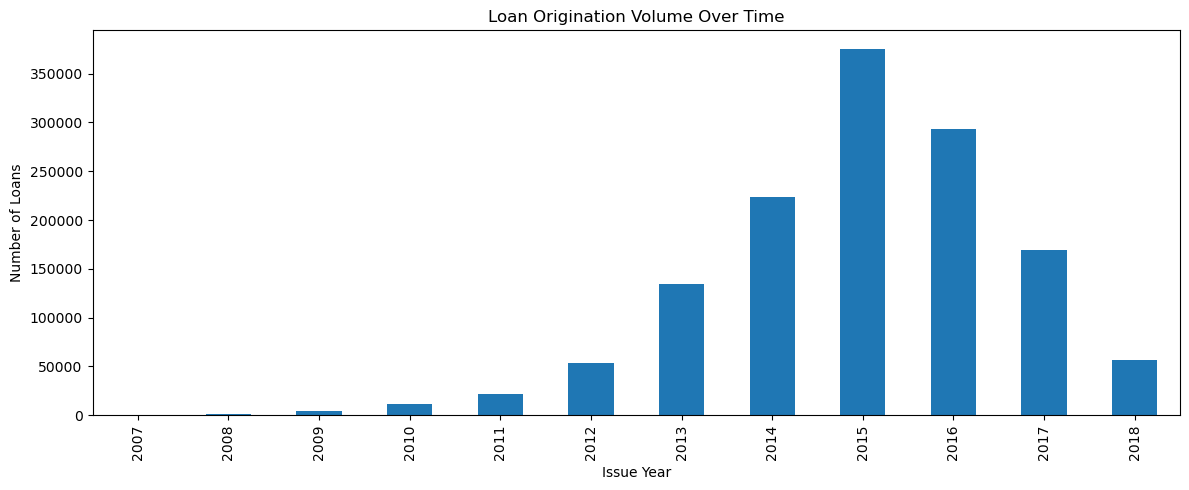

In [41]:
plt.figure(figsize=(12, 5))

year_distribution.plot(kind="bar")

plt.xlabel("Issue Year")
plt.ylabel("Number of Loans")
plt.title("Loan Origination Volume Over Time")

plt.tight_layout()
plt.show()

In [42]:
default_by_year = (
    df.groupby("issue_year")["default"]
    .agg(
        loans="count",
        defaults="sum",
        default_rate="mean"
    )
    .reset_index()
)

default_by_year["default_rate"] = (
    default_by_year["default_rate"] * 100
).round(2)

display(default_by_year)

,issue_year,loans,defaults,default_rate
0,2007,251,45,17.93
1,2008,1562,247,15.81
2,2009,4716,594,12.60
3,2010,11536,1487,12.89
4,2011,21721,3297,15.18
5,2012,53367,8644,16.20
6,2013,134804,21024,15.60
7,2014,223103,41162,18.45
8,2015,375546,75804,20.19
9,2016,293105,68252,23.29


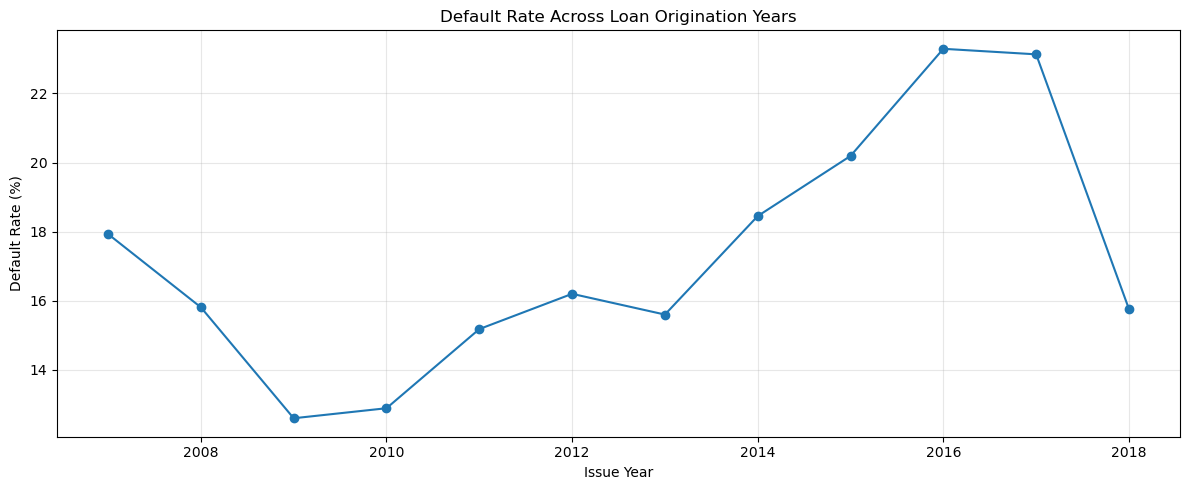

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(
    default_by_year["issue_year"],
    default_by_year["default_rate"],
    marker="o"
)

plt.xlabel("Issue Year")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate Across Loan Origination Years")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
print("Current columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "→", column)

Current columns:

1 → id
2 → loan_amnt
3 → funded_amnt
4 → funded_amnt_inv
5 → term
6 → int_rate
7 → installment
8 → grade
9 → sub_grade
10 → emp_length
11 → home_ownership
12 → annual_inc
13 → verification_status
14 → issue_d
15 → loan_status
16 → purpose
17 → dti
18 → delinq_2yrs
19 → earliest_cr_line
20 → fico_range_low
21 → fico_range_high
22 → inq_last_6mths
23 → open_acc
24 → pub_rec
25 → revol_bal
26 → revol_util
27 → total_acc
28 → application_type
29 → acc_now_delinq
30 → tot_coll_amt
31 → tot_cur_bal
32 → total_rev_hi_lim
33 → acc_open_past_24mths
34 → avg_cur_bal
35 → bc_open_to_buy
36 → bc_util
37 → mo_sin_old_il_acct
38 → mo_sin_old_rev_tl_op
39 → mo_sin_rcnt_rev_tl_op
40 → mo_sin_rcnt_tl
41 → mort_acc
42 → pub_rec_bankruptcies
43 → tax_liens
44 → default
45 → issue_date
46 → issue_year
47 → issue_month


In [45]:
missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isna().sum().values,
    "Missing Percentage": (
        df.isna().mean().values * 100
    ).round(2)
})

missing_report = missing_report.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_report)

,Column,Missing Count,Missing Percentage
36,mo_sin_old_il_acct,105576,7.85
9,emp_length,78516,5.84
37,mo_sin_old_rev_tl_op,67528,5.02
29,tot_coll_amt,67527,5.02
39,mo_sin_rcnt_tl,67527,5.02
30,tot_cur_bal,67527,5.02
33,avg_cur_bal,67549,5.02
38,mo_sin_rcnt_rev_tl_op,67528,5.02
31,total_rev_hi_lim,67527,5.02
35,bc_util,61914,4.60


In [46]:
df_model = df.copy()

print("Working dataset shape:", df_model.shape)
print("Columns:", len(df_model.columns))

Working dataset shape: (1345350, 47)
Columns: 47


In [47]:
numeric_columns = [
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "tot_coll_amt",
    "tot_cur_bal",
    "total_rev_hi_lim",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_open_to_buy",
    "bc_util",
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl",
    "mort_acc",
    "pub_rec_bankruptcies",
    "tax_liens"
]

for column in numeric_columns:

    if column in df_model.columns:

        df_model[column] = pd.to_numeric(
            df_model[column],
            errors="coerce"
        )

print("Numeric conversion completed.")

Numeric conversion completed.


In [48]:
df_model["term_months"] = (
    df_model["term"]
    .astype("string")
    .str.extract(r"(\d+)", expand=False)
)

df_model["term_months"] = pd.to_numeric(
    df_model["term_months"],
    errors="coerce"
)

display(
    df_model[
        ["term", "term_months"]
    ].head(10)
)

,term,term_months
0,36 months,36
1,36 months,36
2,60 months,60
3,60 months,60
4,36 months,36
5,36 months,36
6,36 months,36
7,36 months,36
8,36 months,36
9,36 months,36


In [49]:
df_model["fico_avg"] = (
    df_model["fico_range_low"] +
    df_model["fico_range_high"]
) / 2

df_model["fico_range"] = (
    df_model["fico_range_high"] -
    df_model["fico_range_low"]
)

display(
    df_model[
        [
            "fico_range_low",
            "fico_range_high",
            "fico_avg",
            "fico_range"
        ]
    ].head(10)
)

,fico_range_low,fico_range_high,fico_avg,fico_range
0,675.0,679.0,677.0,4.0
1,715.0,719.0,717.0,4.0
2,695.0,699.0,697.0,4.0
3,695.0,699.0,697.0,4.0
4,690.0,694.0,692.0,4.0
5,680.0,684.0,682.0,4.0
6,705.0,709.0,707.0,4.0
7,685.0,689.0,687.0,4.0
8,700.0,704.0,702.0,4.0
9,700.0,704.0,702.0,4.0


In [50]:
df_model["loan_to_income"] = (
    df_model["loan_amnt"] /
    df_model["annual_inc"].replace(0, np.nan)
)

In [51]:
df_model["installment_to_income"] = (
    (df_model["installment"] * 12) /
    df_model["annual_inc"].replace(0, np.nan)
)

In [52]:
df_model["annual_inc_log"] = np.log1p(
    df_model["annual_inc"].clip(lower=0)
)

df_model["loan_amnt_log"] = np.log1p(
    df_model["loan_amnt"].clip(lower=0)
)

df_model["revol_bal_log"] = np.log1p(
    df_model["revol_bal"].clip(lower=0)
)

df_model["tot_cur_bal_log"] = np.log1p(
    df_model["tot_cur_bal"].clip(lower=0)
)

display(
    df_model[
        [
            "annual_inc",
            "annual_inc_log",
            "loan_amnt",
            "loan_amnt_log"
        ]
    ].head(10)
)

,annual_inc,annual_inc_log,loan_amnt,loan_amnt_log
0,55000.0,10.915107,3600.0,8.188967
1,65000.0,11.082158,24700.0,10.114599
2,63000.0,11.050906,20000.0,9.903538
3,104433.0,11.556311,10400.0,9.249657
4,34000.0,10.434145,11950.0,9.388570
5,180000.0,12.100718,20000.0,9.903538
6,85000.0,11.350418,20000.0,9.903538
7,85000.0,11.350418,10000.0,9.210440
8,42000.0,10.645449,8000.0,8.987322
9,64000.0,11.066654,1400.0,7.244942


In [53]:
df_model["earliest_cr_line_date"] = pd.to_datetime(
    df_model["earliest_cr_line"],
    format="%b-%Y",
    errors="coerce"
)

df_model["credit_history_months"] = (
    (
        df_model["issue_date"].dt.year -
        df_model["earliest_cr_line_date"].dt.year
    ) * 12
    +
    (
        df_model["issue_date"].dt.month -
        df_model["earliest_cr_line_date"].dt.month
    )
)

df_model["credit_history_years"] = (
    df_model["credit_history_months"] / 12
)

display(
    df_model[
        [
            "earliest_cr_line",
            "issue_date",
            "credit_history_years"
        ]
    ].head(10)
)

,earliest_cr_line,issue_date,credit_history_years
0,Aug-2003,2015-12-01,12.333333
1,Dec-1999,2015-12-01,16.000000
2,Aug-2000,2015-12-01,15.333333
3,Jun-1998,2015-12-01,17.500000
4,Oct-1987,2015-12-01,28.166667
5,Jun-1990,2015-12-01,25.500000
6,Feb-1999,2015-12-01,16.833333
7,Apr-2002,2015-12-01,13.666667
8,Nov-1994,2015-12-01,21.083333
9,Jun-1996,2015-12-01,19.500000


In [54]:
def convert_employment_length(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if "< 1 year" in value:
        return 0.5

    if "10+ years" in value:
        return 10.0

    extracted = pd.Series([value]).str.extract(
        r"(\d+)"
    ).iloc[0, 0]

    if pd.isna(extracted):
        return np.nan

    return float(extracted)


df_model["emp_length_years"] = (
    df_model["emp_length"]
    .apply(convert_employment_length)
)

display(
    df_model[
        [
            "emp_length",
            "emp_length_years"
        ]
    ].head(10)
)

,emp_length,emp_length_years
0,10+ years,10.0
1,10+ years,10.0
2,10+ years,10.0
3,3 years,3.0
4,4 years,4.0
5,10+ years,10.0
6,10+ years,10.0
7,6 years,6.0
8,10+ years,10.0
9,3 years,3.0


In [55]:
df_model["interest_rate_decimal"] = (
    df_model["int_rate"] / 100
)

df_model["annual_installment"] = (
    df_model["installment"] * 12
)

df_model["revolving_utilization_decimal"] = (
    df_model["revol_util"] / 100
)

df_model["bc_utilization_decimal"] = (
    df_model["bc_util"] / 100
)

print("Additional financial features created.")

Additional financial features created.


In [56]:
engineered_columns = [
    "term_months",
    "fico_avg",
    "fico_range",
    "loan_to_income",
    "installment_to_income",
    "annual_inc_log",
    "loan_amnt_log",
    "revol_bal_log",
    "tot_cur_bal_log",
    "credit_history_years",
    "emp_length_years",
    "interest_rate_decimal",
    "annual_installment",
    "revolving_utilization_decimal",
    "bc_utilization_decimal"
]

display(
    df_model[engineered_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
term_months,1345350.0,41.790291,10.268378,36.0,36.0,36.0,36.0,60.0
fico_avg,1345350.0,698.185322,31.853122,627.0,672.0,692.0,712.0,847.5
fico_range,1345350.0,4.000138,0.011757,4.0,4.0,4.0,4.0,5.0
loan_to_income,1344989.0,0.397352,70.827648,0.000171,0.124658,0.2,0.290909,40000.0
installment_to_income,1344989.0,0.142369,23.643545,0.000069,0.046261,0.072199,0.105402,13207.92
annual_inc_log,1345350.0,11.081912,0.570397,0.0,10.731624,11.082158,11.407576,16.213333
loan_amnt_log,1345350.0,9.367167,0.696397,6.216606,8.987322,9.392745,9.903538,10.59666
revol_bal_log,1345350.0,9.192369,1.225368,0.0,8.690138,9.317849,9.891213,14.881888
tot_cur_bal_log,1277823.0,11.204451,1.290245,0.0,10.289566,11.292678,12.258267,15.894962
credit_history_years,1345350.0,16.259347,7.506083,3.0,11.25,14.75,20.0,83.25


In [57]:
leakage_columns = [
    "loan_status",
    "default",

    # Post-origination payment information
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d",

    # Post-origination credit information
    "last_fico_range_high",
    "last_fico_range_low",

    # Hardship and settlement information
    "hardship_flag",
    "hardship_type",
    "hardship_reason",
    "hardship_status",
    "hardship_amount",
    "hardship_start_date",
    "hardship_end_date",
    "hardship_loan_status",
    "settlement_status",
    "settlement_date",
    "settlement_amount",
    "settlement_percentage",
    "settlement_term"
]

available_leakage_columns = [
    column
    for column in leakage_columns
    if column in df_model.columns
]

print("Leakage-related columns identified:")

for column in available_leakage_columns:
    print("→", column)

Leakage-related columns identified:
→ loan_status
→ default


In [58]:
feature_columns = [
    # Original loan features
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "int_rate",
    "installment",
    "term_months",

    # Grade information
    "grade",
    "sub_grade",

    # Borrower information
    "emp_length_years",
    "home_ownership",
    "annual_inc",
    "annual_inc_log",
    "verification_status",
    "purpose",

    # Credit information
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "fico_avg",
    "fico_range",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_bal_log",
    "revol_util",
    "total_acc",

    # Account information
    "acc_now_delinq",
    "tot_coll_amt",
    "tot_cur_bal",
    "tot_cur_bal_log",
    "total_rev_hi_lim",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_open_to_buy",
    "bc_util",

    # Credit age
    "credit_history_years",
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl",

    # Other information
    "mort_acc",
    "pub_rec_bankruptcies",
    "tax_liens",
    "application_type",

    # Engineered ratios
    "loan_to_income",
    "installment_to_income",
    "interest_rate_decimal",
    "annual_installment",
    "revolving_utilization_decimal",
    "bc_utilization_decimal"
]

available_features = [
    column
    for column in feature_columns
    if column in df_model.columns
]

missing_features = [
    column
    for column in feature_columns
    if column not in df_model.columns
]

print("Available features:", len(available_features))
print("Missing features:", missing_features)

Available features: 51
Missing features: []


In [59]:
selected_columns = (
    available_features +
    [
        "default",
        "issue_date",
        "issue_year",
        "id"
    ]
)

selected_columns = list(dict.fromkeys(selected_columns))

model_data = df_model[selected_columns].copy()

print("Modelling table shape:", model_data.shape)

display(model_data.head())

Modelling table shape: (1345350, 55)


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,term_months,grade,sub_grade,emp_length_years,home_ownership,...,loan_to_income,installment_to_income,interest_rate_decimal,annual_installment,revolving_utilization_decimal,bc_utilization_decimal,default,issue_date,issue_year,id
0,3600.0,3600.0,3600.0,13.99,123.03,36,C,C4,10.0,MORTGAGE,...,0.065455,0.026843,0.1399,1476.36,0.297,0.372,0,2015-12-01,2015,68407277
1,24700.0,24700.0,24700.0,11.99,820.28,36,C,C1,10.0,MORTGAGE,...,0.380000,0.151436,0.1199,9843.36,0.192,0.271,0,2015-12-01,2015,68355089
2,20000.0,20000.0,20000.0,10.78,432.66,60,B,B4,10.0,MORTGAGE,...,0.317460,0.082411,0.1078,5191.92,0.562,0.559,0,2015-12-01,2015,68341763
3,10400.0,10400.0,10400.0,22.45,289.91,60,F,F1,3.0,MORTGAGE,...,0.099585,0.033312,0.2245,3478.92,0.645,0.775,0,2015-12-01,2015,68476807
4,11950.0,11950.0,11950.0,13.44,405.18,36,C,C3,4.0,RENT,...,0.351471,0.143005,0.1344,4862.16,0.684,0.910,0,2015-12-01,2015,68426831


In [60]:
print(
    "Missing target values:",
    model_data["default"].isna().sum()
)

print(
    "Missing issue dates:",
    model_data["issue_date"].isna().sum()
)

Missing target values: 0
Missing issue dates: 0


In [61]:
year_counts = (
    model_data["issue_year"]
    .value_counts()
    .sort_index()
)

display(
    year_counts.to_frame("Number of Records")
)

,Number of Records
issue_year,
2007,251
2008,1562
2009,4716
2010,11536
2011,21721
2012,53367
2013,134804
2014,223103
2015,375546


In [62]:
train_data = model_data[
    model_data["issue_year"] <= 2015
].copy()

validation_data = model_data[
    model_data["issue_year"] == 2016
].copy()

test_data = model_data[
    model_data["issue_year"] >= 2017
].copy()

print("Training shape:", train_data.shape)
print("Validation shape:", validation_data.shape)
print("Testing shape:", test_data.shape)

Training shape: (826606, 55)
Validation shape: (293105, 55)
Testing shape: (225639, 55)


In [63]:
def split_summary(data, split_name):

    total = len(data)
    defaults = data["default"].sum()
    default_rate = defaults / total * 100 if total > 0 else np.nan

    return {
        "Split": split_name,
        "Records": total,
        "Defaults": int(defaults),
        "Non-defaults": int(total - defaults),
        "Default Rate (%)": round(default_rate, 2)
    }


split_summary_df = pd.DataFrame([
    split_summary(train_data, "Training"),
    split_summary(validation_data, "Validation"),
    split_summary(test_data, "Testing")
])

display(split_summary_df)

,Split,Records,Defaults,Non-defaults,Default Rate (%)
0,Training,826606,152304,674302,18.43
1,Validation,293105,68252,224853,23.29
2,Testing,225639,48043,177596,21.29


In [64]:
print(
    "Maximum training year:",
    train_data["issue_year"].max()
)

print(
    "Minimum validation year:",
    validation_data["issue_year"].min()
)

print(
    "Maximum validation year:",
    validation_data["issue_year"].max()
)

print(
    "Minimum testing year:",
    test_data["issue_year"].min()
)

Maximum training year: 2015
Minimum validation year: 2016
Maximum validation year: 2016
Minimum testing year: 2017


In [65]:
output_path = "fintwinai_model_data.csv"

model_data.to_csv(
    output_path,
    index=False
)

print("Saved file:", output_path)

file_size_mb = (
    Path(output_path).stat().st_size / (1024 ** 2)
)

print(
    f"File size: {file_size_mb:.2f} MB"
)

Saved file: fintwinai_model_data.csv
File size: 528.65 MB


In [66]:
# Check infinite values in numerical columns

numeric_check_columns = [
    column
    for column in available_features
    if column in model_data.columns
]

infinity_report = {}

for column in numeric_check_columns:

    if pd.api.types.is_numeric_dtype(model_data[column]):

        infinity_count = np.isinf(
            model_data[column].dropna()
        ).sum()

        if infinity_count > 0:
            infinity_report[column] = infinity_count

print("Columns containing infinite values:")

if len(infinity_report) == 0:
    print("✅ No infinite values found.")
else:
    display(
        pd.DataFrame(
            list(infinity_report.items()),
            columns=["Column", "Infinite Count"]
        )
    )

Columns containing infinite values:
✅ No infinite values found.


In [67]:
# Replace positive and negative infinity with missing values

model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Infinite values replaced with NaN.")

Infinite values replaced with NaN.


In [68]:
# Predictor variables
X = model_data[available_features].copy()

# Target variable
y = model_data["default"].copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

Predictor shape: (1345350, 51)
Target shape: (1345350,)

Target distribution:


default
0    1076751
1     268599
Name: count, dtype: int64

In [69]:
# Training data
X_train = train_data[available_features].copy()
y_train = train_data["default"].copy()

# Validation data
X_val = validation_data[available_features].copy()
y_val = validation_data["default"].copy()

# Testing data
X_test = test_data[available_features].copy()
y_test = test_data["default"].copy()

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (826606, 51) (826606,)
Validation: (293105, 51) (293105,)
Testing: (225639, 51) (225639,)


In [70]:
# Identify numerical columns
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

# Identify categorical columns
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 45
Number of categorical features: 6

Numerical features:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'term_months', 'emp_length_years', 'annual_inc', 'annual_inc_log', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'fico_avg', 'fico_range', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_bal_log', 'revol_util', 'total_acc', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'tot_cur_bal_log', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'credit_history_years', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens', 'loan_to_income', 'installment_to_income', 'interest_rate_decimal', 'annual_installment', 'revolving_utilization_decimal', 'bc_utilization_decimal']

Categorical features:
['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'application_type']


In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [72]:
# Compatibility for different scikit-learn versions

try:

    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    )

except TypeError:

    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=True
    )

print("OneHotEncoder created successfully.")

OneHotEncoder created successfully.


In [73]:
# Numerical preprocessing
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            encoder
        )
    ]
)

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [74]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=100,
    random_state=42
)

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            logistic_model
        )
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [75]:
import time

start_time = time.time()

print("Training Logistic Regression...")
print("Training records:", len(X_train))

logistic_pipeline.fit(
    X_train,
    y_train
)

elapsed_time = time.time() - start_time

print("\n✅ Logistic Regression training completed.")
print(f"Training time: {elapsed_time / 60:.2f} minutes")

Training Logistic Regression...
Training records: 826606

✅ Logistic Regression training completed.
Training time: 1.71 minutes


In [76]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Evaluation libraries imported successfully.")

Evaluation libraries imported successfully.


In [77]:
import time

start_time = time.time()

print("Generating validation predictions...")

val_probability = logistic_pipeline.predict_proba(X_val)[:, 1]

val_prediction = (
    val_probability >= 0.5
).astype(int)

print("Generating test predictions...")

test_probability = logistic_pipeline.predict_proba(X_test)[:, 1]

test_prediction = (
    test_probability >= 0.5
).astype(int)

elapsed_time = time.time() - start_time

print("\n✅ Predictions generated.")
print(f"Time taken: {elapsed_time / 60:.2f} minutes")

Generating validation predictions...
Generating test predictions...

✅ Predictions generated.
Time taken: 0.04 minutes


In [78]:
def evaluate_model(
    y_true,
    probability,
    prediction,
    dataset_name
):

    results = {

        "Dataset": dataset_name,

        "ROC-AUC": roc_auc_score(
            y_true,
            probability
        ),

        "PR-AUC": average_precision_score(
            y_true,
            probability
        ),

        "Brier Score": brier_score_loss(
            y_true,
            probability
        ),

        "Log Loss": log_loss(
            y_true,
            probability
        ),

        "Accuracy": accuracy_score(
            y_true,
            prediction
        ),

        "Precision": precision_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            prediction,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_true,
            prediction,
            zero_division=0
        )
    }

    return results

In [79]:
validation_results = evaluate_model(
    y_val,
    val_probability,
    val_prediction,
    "Validation"
)

test_results = evaluate_model(
    y_test,
    test_probability,
    test_prediction,
    "Testing"
)

baseline_results = pd.DataFrame([
    validation_results,
    test_results
])

display(
    baseline_results.style.format({
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "Brier Score": "{:.4f}",
        "Log Loss": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Dataset,ROC-AUC,PR-AUC,Brier Score,Log Loss,Accuracy,Precision,Recall,F1 Score
0,Validation,0.7121,0.4179,0.2111,0.6092,0.6591,0.3670,0.6402,0.4666
1,Testing,0.6987,0.3577,0.2101,0.6170,0.6622,0.3369,0.6058,0.4330


In [80]:
cm = confusion_matrix(
    y_test,
    test_prediction
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Non-default",
        "Actual Default"
    ],
    columns=[
        "Predicted Non-default",
        "Predicted Default"
    ]
)

display(cm_df)

,Predicted Non-default,Predicted Default
Actual Non-default,120319,57277
Actual Default,18939,29104


In [81]:
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "Non-default",
            "Default"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 Non-default       0.86      0.68      0.76    177596
     Default       0.34      0.61      0.43     48043

    accuracy                           0.66    225639
   macro avg       0.60      0.64      0.60    225639
weighted avg       0.75      0.66      0.69    225639



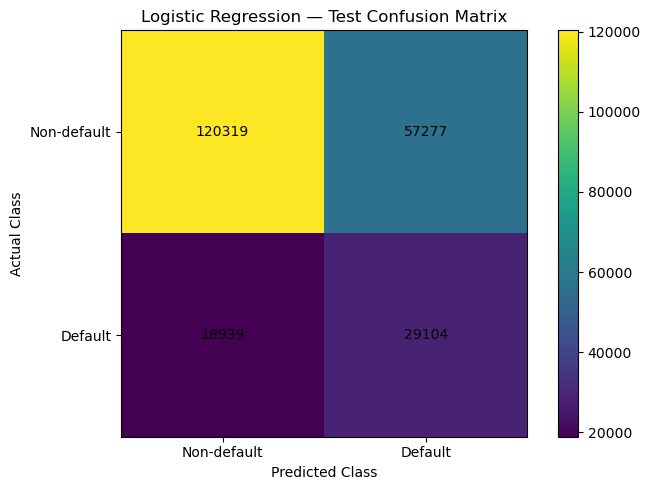

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Logistic Regression — Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Non-default", "Default"]
)

plt.yticks(
    [0, 1],
    ["Non-default", "Default"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


In [84]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

print("Calibration and curve libraries imported.")

Calibration and curve libraries imported.


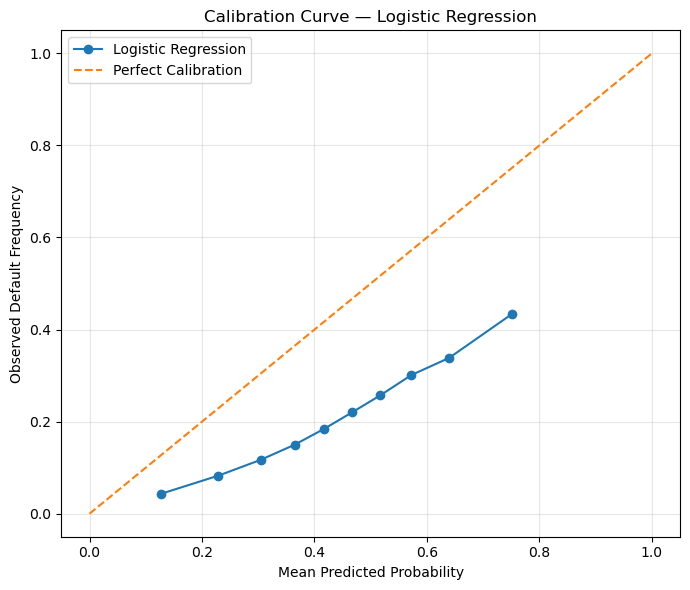

In [85]:
prob_true, prob_pred = calibration_curve(
    y_test,
    test_probability,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Frequency")
plt.title("Calibration Curve — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

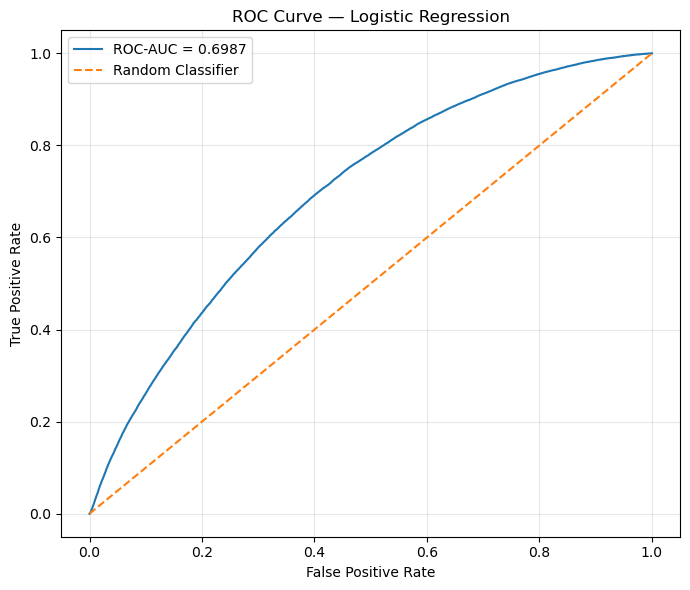

In [86]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    test_probability
)

test_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

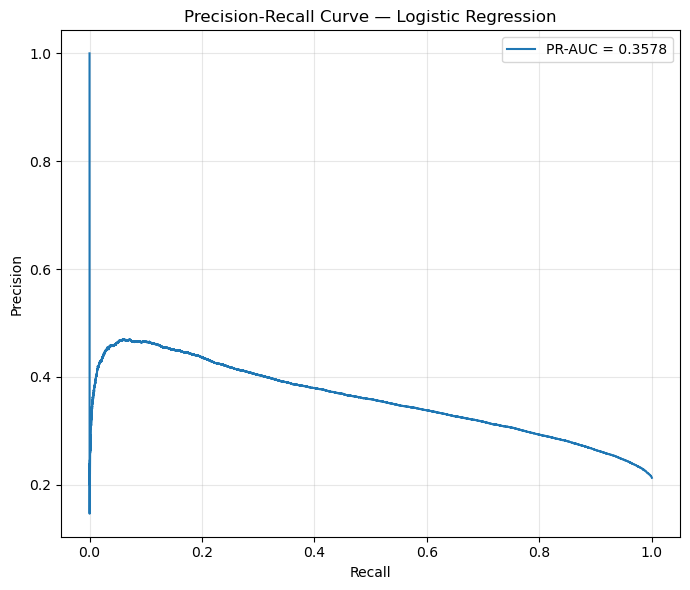

In [87]:
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        test_probability
    )
)

test_pr_auc = auc(
    recall_values,
    precision_values
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"PR-AUC = {test_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [88]:
threshold_values = np.arange(
    0.10,
    0.91,
    0.02
)

threshold_results = []

for threshold in threshold_values:

    validation_prediction_threshold = (
        val_probability >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(
            y_val,
            validation_prediction_threshold,
            zero_division=0
        ),

        "Recall": recall_score(
            y_val,
            validation_prediction_threshold,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_val,
            validation_prediction_threshold,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_results_df.style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.2377,0.9980,0.3839
1,0.12,0.2409,0.9954,0.3879
2,0.14,0.2443,0.9923,0.3921
3,0.16,0.2477,0.9883,0.3961
4,0.18,0.2511,0.9834,0.4001
5,0.20,0.2547,0.9782,0.4041
6,0.22,0.2584,0.9717,0.4083
7,0.24,0.2625,0.9639,0.4127
8,0.26,0.2670,0.9541,0.4173
9,0.28,0.2723,0.9433,0.4226


In [89]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print(
    f"Selected threshold: {best_threshold:.2f}"
)

print(
    f"Validation F1: "
    f"{best_threshold_row['F1 Score']:.4f}"
)

print(
    f"Validation Precision: "
    f"{best_threshold_row['Precision']:.4f}"
)

print(
    f"Validation Recall: "
    f"{best_threshold_row['Recall']:.4f}"
)

Selected threshold: 0.48
Validation F1: 0.4673
Validation Precision: 0.3555
Validation Recall: 0.6819


In [90]:
optimized_test_prediction = (
    test_probability >= best_threshold
).astype(int)

optimized_test_results = evaluate_model(
    y_test,
    test_probability,
    optimized_test_prediction,
    f"Testing — Threshold {best_threshold:.2f}"
)

optimized_test_df = pd.DataFrame([
    optimized_test_results
])

display(
    optimized_test_df.style.format({
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "Brier Score": "{:.4f}",
        "Log Loss": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Dataset,ROC-AUC,PR-AUC,Brier Score,Log Loss,Accuracy,Precision,Recall,F1 Score
0,Testing — Threshold 0.48,0.6987,0.3577,0.2101,0.6170,0.6404,0.3269,0.6504,0.4351


In [91]:
default_threshold_prediction = (
    test_probability >= 0.5
).astype(int)

default_threshold_f1 = f1_score(
    y_test,
    default_threshold_prediction,
    zero_division=0
)

optimized_threshold_f1 = f1_score(
    y_test,
    optimized_test_prediction,
    zero_division=0
)

threshold_comparison = pd.DataFrame({

    "Threshold Type": [
        "Default 0.50",
        "Validation-optimized"
    ],

    "Threshold": [
        0.50,
        best_threshold
    ],

    "F1 Score": [
        default_threshold_f1,
        optimized_threshold_f1
    ],

    "Precision": [
        precision_score(
            y_test,
            default_threshold_prediction,
            zero_division=0
        ),
        precision_score(
            y_test,
            optimized_test_prediction,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            default_threshold_prediction,
            zero_division=0
        ),
        recall_score(
            y_test,
            optimized_test_prediction,
            zero_division=0
        )
    ]
})

display(
    threshold_comparison.style.format({
        "Threshold": "{:.2f}",
        "F1 Score": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}"
    })
)

,Threshold Type,Threshold,F1 Score,Precision,Recall
0,Default 0.50,0.50,0.4330,0.3369,0.6058
1,Validation-optimized,0.48,0.4351,0.3269,0.6504


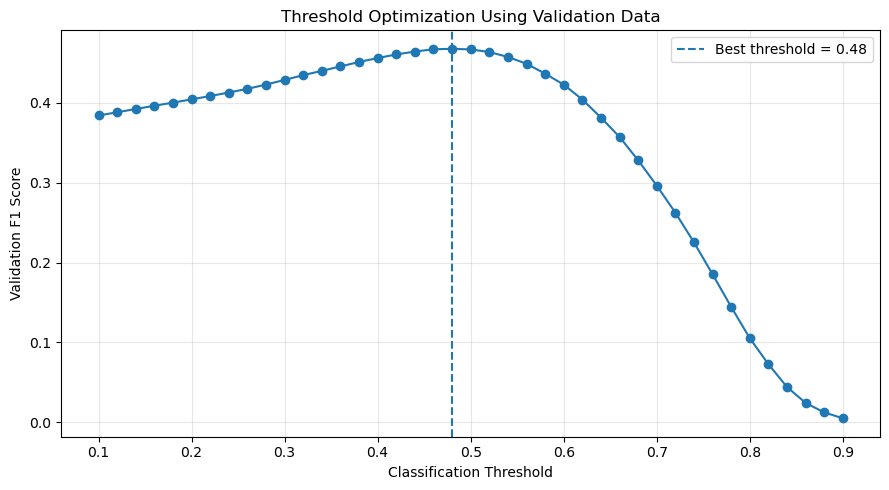

In [92]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1 Score"],
    marker="o"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Validation F1 Score")
plt.title("Threshold Optimization Using Validation Data")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
print("Pipeline steps:")

for step_name, step_object in logistic_pipeline.named_steps.items():
    print(
        step_name,
        "→",
        type(step_object).__name__
    )

Pipeline steps:
preprocessing → ColumnTransformer
model → LogisticRegression


In [94]:
try:

    import xgboost as xgb

    print("XGBoost version:", xgb.__version__)
    print("✅ XGBoost imported successfully.")

except ImportError:

    print(
        "XGBoost is not installed. "
        "Run: %pip install xgboost"
    )

XGBoost version: 3.2.0
✅ XGBoost imported successfully.


In [95]:
preprocessor = logistic_pipeline[:-1]

print("Preprocessing component extracted.")
print(type(preprocessor).__name__)

Preprocessing component extracted.
Pipeline


In [96]:
import time

start_time = time.time()

print("Transforming training data...")

X_train_xgb = preprocessor.transform(X_train)

print("Transforming validation data...")

X_val_xgb = preprocessor.transform(X_val)

print("Transforming testing data...")

X_test_xgb = preprocessor.transform(X_test)

elapsed_time = time.time() - start_time

print("\n✅ Transformation completed.")

print("Training shape:", X_train_xgb.shape)
print("Validation shape:", X_val_xgb.shape)
print("Testing shape:", X_test_xgb.shape)

print(f"Time taken: {elapsed_time / 60:.2f} minutes")

Transforming training data...
Transforming validation data...
Transforming testing data...

✅ Transformation completed.
Training shape: (826606, 112)
Validation shape: (293105, 112)
Testing shape: (225639, 112)
Time taken: 0.11 minutes


In [97]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Non-default records:", negative_count)
print("Default records:", positive_count)

print(
    "Scale positive weight:",
    round(scale_pos_weight, 4)
)

Non-default records: 674302
Default records: 152304
Scale positive weight: 4.4273


In [98]:
xgb_model = xgb.XGBClassifier(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=6,

    min_child_weight=5,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="auc",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",

    n_jobs=-1,

    random_state=42
)

print("✅ XGBoost model created.")

✅ XGBoost model created.


In [99]:
start_time = time.time()

print("Starting XGBoost training...")

xgb_model.fit(

    X_train_xgb,
    y_train,

    eval_set=[
        (X_train_xgb, y_train),
        (X_val_xgb, y_val)
    ],

    verbose=50
)

elapsed_time = time.time() - start_time

print("\n✅ XGBoost training completed.")
print(f"Training time: {elapsed_time / 60:.2f} minutes")

Starting XGBoost training...
[0]	validation_0-auc:0.70774	validation_1-auc:0.69685
[50]	validation_0-auc:0.72398	validation_1-auc:0.71120
[100]	validation_0-auc:0.73069	validation_1-auc:0.71588
[150]	validation_0-auc:0.73511	validation_1-auc:0.71810
[200]	validation_0-auc:0.73876	validation_1-auc:0.71923
[250]	validation_0-auc:0.74204	validation_1-auc:0.72001
[300]	validation_0-auc:0.74488	validation_1-auc:0.72031
[350]	validation_0-auc:0.74739	validation_1-auc:0.72076
[400]	validation_0-auc:0.74973	validation_1-auc:0.72091
[450]	validation_0-auc:0.75205	validation_1-auc:0.72105
[499]	validation_0-auc:0.75414	validation_1-auc:0.72115

✅ XGBoost training completed.
Training time: 2.53 minutes


In [100]:
start_time = time.time()

print("Generating XGBoost validation predictions...")

xgb_val_probability = xgb_model.predict_proba(
    X_val_xgb
)[:, 1]

print("Generating XGBoost test predictions...")

xgb_test_probability = xgb_model.predict_proba(
    X_test_xgb
)[:, 1]

elapsed_time = time.time() - start_time

print("\n✅ XGBoost predictions generated.")
print(f"Time taken: {elapsed_time / 60:.2f} minutes")

Generating XGBoost validation predictions...
Generating XGBoost test predictions...

✅ XGBoost predictions generated.
Time taken: 0.02 minutes


In [101]:
xgb_val_prediction = (
    xgb_val_probability >= 0.5
).astype(int)

xgb_test_prediction = (
    xgb_test_probability >= 0.5
).astype(int)

xgb_validation_results = evaluate_model(
    y_val,
    xgb_val_probability,
    xgb_val_prediction,
    "XGBoost Validation"
)

xgb_test_results = evaluate_model(
    y_test,
    xgb_test_probability,
    xgb_test_prediction,
    "XGBoost Testing"
)

xgb_results_df = pd.DataFrame([
    xgb_validation_results,
    xgb_test_results
])

display(
    xgb_results_df.style.format({
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "Brier Score": "{:.4f}",
        "Log Loss": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Dataset,ROC-AUC,PR-AUC,Brier Score,Log Loss,Accuracy,Precision,Recall,F1 Score
0,XGBoost Validation,0.7211,0.4347,0.2065,0.5974,0.6695,0.3763,0.6376,0.4733
1,XGBoost Testing,0.7105,0.3844,0.2068,0.5976,0.6681,0.3449,0.6218,0.4437


In [102]:
logistic_test_results = evaluate_model(
    y_test,
    test_probability,
    test_prediction,
    "Logistic Regression"
)

xgb_test_results = evaluate_model(
    y_test,
    xgb_test_probability,
    xgb_test_prediction,
    "XGBoost"
)

model_comparison_df = pd.DataFrame([
    logistic_test_results,
    xgb_test_results
])

display(
    model_comparison_df.style.format({
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "Brier Score": "{:.4f}",
        "Log Loss": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Dataset,ROC-AUC,PR-AUC,Brier Score,Log Loss,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6987,0.3577,0.2101,0.6170,0.6622,0.3369,0.6058,0.4330
1,XGBoost,0.7105,0.3844,0.2068,0.5976,0.6681,0.3449,0.6218,0.4437


In [103]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)
print("✅ SHAP imported successfully.")

SHAP version: 0.51.0
✅ SHAP imported successfully.


In [104]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

print("\nFirst 20 feature names:")
print(feature_names[:20])

Number of transformed features: 112

First 20 feature names:
['numerical__loan_amnt' 'numerical__funded_amnt'
 'numerical__funded_amnt_inv' 'numerical__int_rate'
 'numerical__installment' 'numerical__term_months'
 'numerical__emp_length_years' 'numerical__annual_inc'
 'numerical__annual_inc_log' 'numerical__dti' 'numerical__delinq_2yrs'
 'numerical__fico_range_low' 'numerical__fico_range_high'
 'numerical__fico_avg' 'numerical__fico_range' 'numerical__inq_last_6mths'
 'numerical__open_acc' 'numerical__pub_rec' 'numerical__revol_bal'
 'numerical__revol_bal_log']


In [105]:
shap_sample_size = min(5000, X_test_xgb.shape[0])

rng = np.random.default_rng(42)

shap_indices = rng.choice(
    X_test_xgb.shape[0],
    size=shap_sample_size,
    replace=False
)

X_shap = X_test_xgb[shap_indices]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (5000, 112)


In [106]:
print("Creating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(
    xgb_model
)

print("✅ SHAP explainer created.")

Creating SHAP TreeExplainer...
✅ SHAP explainer created.


In [107]:
import time

start_time = time.time()

print("Calculating SHAP values...")

shap_values = explainer.shap_values(
    X_shap
)

elapsed_time = time.time() - start_time

print("\n✅ SHAP values calculated.")
print("SHAP values shape:", np.asarray(shap_values).shape)
print(f"Time taken: {elapsed_time / 60:.2f} minutes")

Calculating SHAP values...

✅ SHAP values calculated.
SHAP values shape: (5000, 112)
Time taken: 0.12 minutes


In [108]:
shap_array = np.asarray(shap_values)

mean_abs_shap = np.mean(
    np.abs(shap_array),
    axis=0
)

shap_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Mean Absolute SHAP": mean_abs_shap

}).sort_values(
    by="Mean Absolute SHAP",
    ascending=False
).reset_index(drop=True)

display(
    shap_importance_df.head(20).style.format({
        "Mean Absolute SHAP": "{:.6f}"
    })
)

,Feature,Mean Absolute SHAP
0,numerical__int_rate,0.337358
1,numerical__term_months,0.267176
2,numerical__acc_open_past_24mths,0.158720
3,numerical__dti,0.107564
4,numerical__loan_to_income,0.086636
5,numerical__fico_range_low,0.077045
6,numerical__avg_cur_bal,0.074829
7,categorical__grade_A,0.065226
8,numerical__mo_sin_old_rev_tl_op,0.062462
9,numerical__total_acc,0.046961


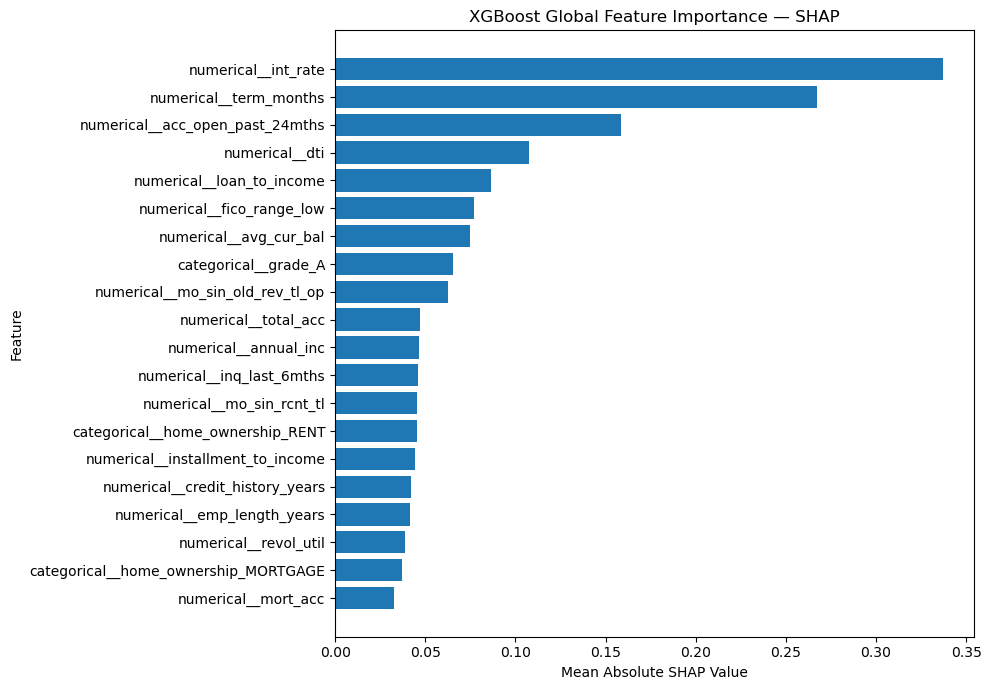

In [109]:
top_features = shap_importance_df.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean Absolute SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("XGBoost Global Feature Importance — SHAP")

plt.tight_layout()
plt.show()

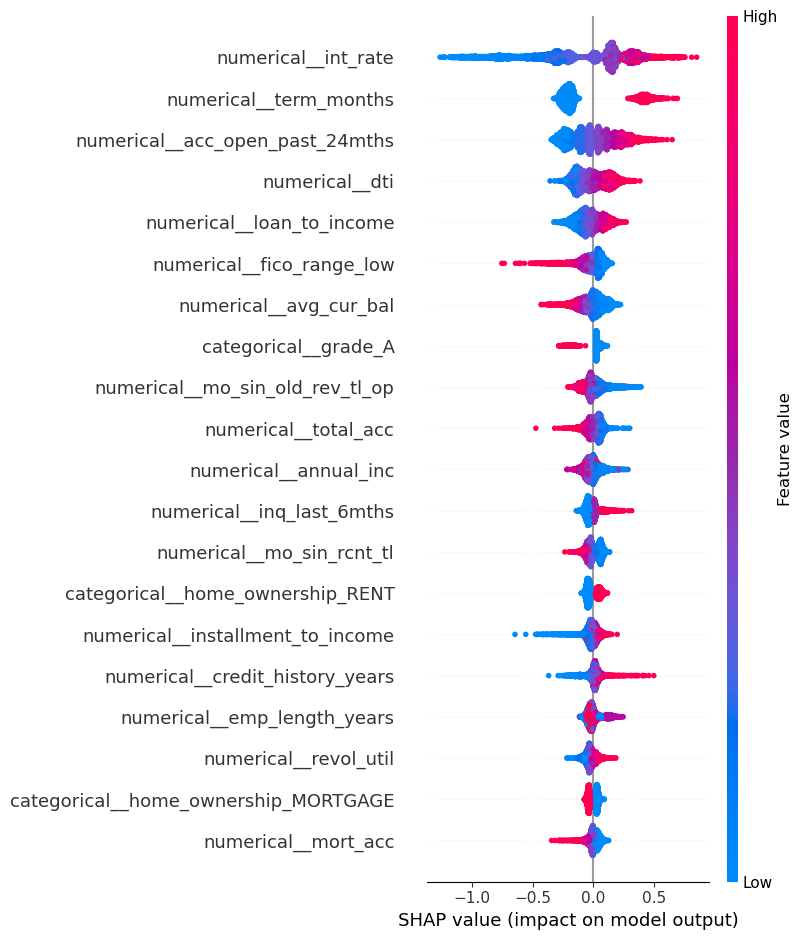

In [110]:
shap.summary_plot(
    shap_array,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=True
)

In [111]:
shap_importance_df.to_csv(
    "xgboost_shap_feature_importance.csv",
    index=False
)

print("✅ SHAP importance table saved.")

✅ SHAP importance table saved.


In [112]:
signed_shap_importance = pd.DataFrame({

    "Feature": feature_names,

    "Mean_Absolute_SHAP": np.mean(
        np.abs(shap_array),
        axis=0
    ),

    "Mean_Signed_SHAP": np.mean(
        shap_array,
        axis=0
    )

}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(
    signed_shap_importance.head(20).style.format({
        "Mean_Absolute_SHAP": "{:.6f}",
        "Mean_Signed_SHAP": "{:.6f}"
    })
)

,Feature,Mean_Absolute_SHAP,Mean_Signed_SHAP
0,numerical__int_rate,0.337358,-0.081625
1,numerical__term_months,0.267176,-0.053421
2,numerical__acc_open_past_24mths,0.158720,0.010372
3,numerical__dti,0.107564,-0.012619
4,numerical__loan_to_income,0.086636,-0.028565
5,numerical__fico_range_low,0.077045,-0.026035
6,numerical__avg_cur_bal,0.074829,-0.010969
7,categorical__grade_A,0.065226,0.000214
8,numerical__mo_sin_old_rev_tl_op,0.062462,0.005802
9,numerical__total_acc,0.046961,0.006167


In [113]:
direction_results = []

for i, feature in enumerate(feature_names):

    feature_values = np.asarray(X_shap[:, i]).ravel()
    feature_shap = shap_array[:, i]

    correlation = np.corrcoef(
        feature_values,
        feature_shap
    )[0, 1]

    direction_results.append({

        "Feature": feature,

        "Mean_Absolute_SHAP": np.mean(
            np.abs(feature_shap)
        ),

        "Mean_SHAP": np.mean(
            feature_shap
        ),

        "Feature_SHAP_Correlation": correlation

    })

direction_df = pd.DataFrame(direction_results)

direction_df = direction_df.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(
    direction_df.head(20).style.format({
        "Mean_Absolute_SHAP": "{:.6f}",
        "Mean_SHAP": "{:.6f}",
        "Feature_SHAP_Correlation": "{:.6f}"
    })
)

,Feature,Mean_Absolute_SHAP,Mean_SHAP,Feature_SHAP_Correlation
0,numerical__int_rate,0.337358,-0.081625,0.891595
1,numerical__term_months,0.267177,-0.053421,0.989286
2,numerical__acc_open_past_24mths,0.158720,0.010372,0.937354
3,numerical__dti,0.107563,-0.012619,0.766883
4,numerical__loan_to_income,0.086636,-0.028565,0.738240
5,numerical__fico_range_low,0.077045,-0.026035,-0.958436
6,numerical__avg_cur_bal,0.074829,-0.010969,-0.884871
7,categorical__grade_A,0.065226,0.000214,-0.966844
8,numerical__mo_sin_old_rev_tl_op,0.062462,0.005802,-0.817339
9,numerical__total_acc,0.046961,0.006167,-0.917907


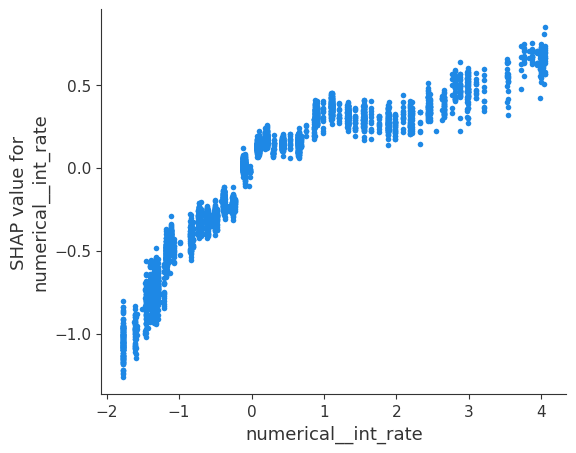

In [114]:
interest_rate_index = list(feature_names).index(
    "numerical__int_rate"
)

shap.dependence_plot(
    interest_rate_index,
    shap_array,
    X_shap,
    feature_names=feature_names,
    interaction_index=None,
    show=True
)

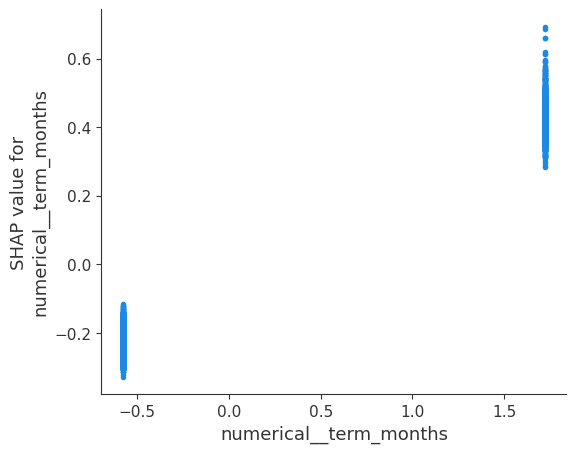

In [115]:
term_index = list(feature_names).index(
    "numerical__term_months"
)

shap.dependence_plot(
    term_index,
    shap_array,
    X_shap,
    feature_names=feature_names,
    interaction_index=None,
    show=True
)

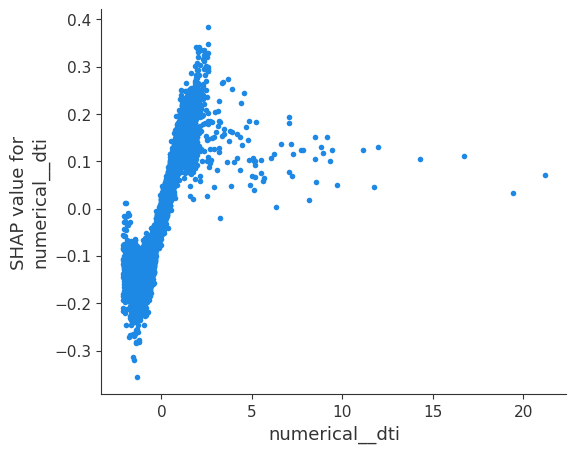

In [116]:
dti_index = list(feature_names).index(
    "numerical__dti"
)

shap.dependence_plot(
    dti_index,
    shap_array,
    X_shap,
    feature_names=feature_names,
    interaction_index=None,
    show=True
)

In [117]:
borrower_position = 0

individual_shap_values = shap_array[borrower_position]

individual_explanation = pd.DataFrame({

    "Feature": feature_names,

    "SHAP_Value": individual_shap_values,

    "Absolute_SHAP": np.abs(individual_shap_values)

}).sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(
    individual_explanation.head(15).style.format({
        "SHAP_Value": "{:.6f}",
        "Absolute_SHAP": "{:.6f}"
    })
)

,Feature,SHAP_Value,Absolute_SHAP
0,numerical__int_rate,0.335230,0.335230
1,numerical__acc_open_past_24mths,0.273449,0.273449
2,numerical__term_months,-0.199965,0.199965
3,numerical__dti,0.157842,0.157842
4,numerical__avg_cur_bal,-0.135341,0.135341
5,categorical__grade_D,-0.115987,0.115987
6,numerical__loan_to_income,0.099578,0.099578
7,categorical__application_type_Individual,-0.094827,0.094827
8,categorical__purpose_other,0.069919,0.069919
9,numerical__emp_length_years,0.066556,0.066556


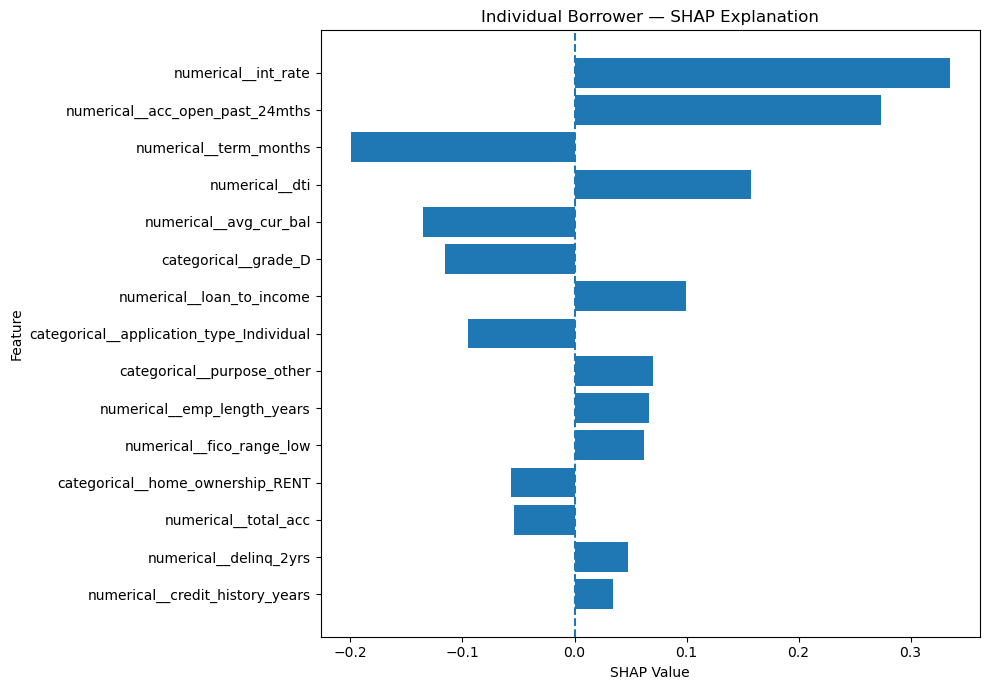

In [118]:
top_individual_features = individual_explanation.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_individual_features["Feature"][::-1],
    top_individual_features["SHAP_Value"][::-1]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Individual Borrower — SHAP Explanation")

plt.tight_layout()
plt.show()

In [129]:
print("AVAILABLE VARIABLES:\n")

for name, value in list(globals().items()):

    if name.startswith("X_"):

        try:
            print(name, "→", value.shape)

        except AttributeError:
            print(name, "→ Not a DataFrame/Array")

AVAILABLE VARIABLES:

X_train → (826606, 51)
X_val → (293105, 51)
X_test → (225639, 51)
X_train_xgb → (826606, 112)
X_val_xgb → (293105, 112)
X_test_xgb → (225639, 112)
X_shap → (5000, 112)


In [130]:
print("PREPROCESSING VARIABLES:\n")

for name in list(globals().keys()):

    if any(word in name.lower() for word in [
        "transform",
        "preprocess",
        "encoder",
        "pipeline"
    ]):

        print(name)

PREPROCESSING VARIABLES:

ColumnTransformer
Pipeline
OneHotEncoder
encoder
numeric_pipeline
categorical_pipeline
preprocessor
logistic_pipeline


In [131]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)

# Validation probabilities
xgb_val_prob = xgb_model.predict_proba(
    X_val_xgb
)[:, 1]

# Testing probabilities
xgb_test_prob = xgb_model.predict_proba(
    X_test_xgb
)[:, 1]

print(
    "Validation probabilities generated:",
    len(xgb_val_prob)
)

print(
    "Testing probabilities generated:",
    len(xgb_test_prob)
)

print("\nValidation probability range:")

print(
    xgb_val_prob.min(),
    "to",
    xgb_val_prob.max()
)

print("\nTesting probability range:")

print(
    xgb_test_prob.min(),
    "to",
    xgb_test_prob.max()
)

Validation probabilities generated: 293105
Testing probabilities generated: 225639

Validation probability range:
0.012046745 to 0.9515697

Testing probability range:
0.009872922 to 0.9529636


In [132]:
from sklearn.linear_model import LogisticRegression

# Reshape probabilities into a 2D array
xgb_val_prob_2d = xgb_val_prob.reshape(-1, 1)
xgb_test_prob_2d = xgb_test_prob.reshape(-1, 1)

# Create calibration model
platt_calibrator = LogisticRegression(
    max_iter=1000
)

# Fit only on validation probabilities
platt_calibrator.fit(
    xgb_val_prob_2d,
    y_val
)

# Calibrated test probabilities
xgb_test_prob_calibrated = (
    platt_calibrator.predict_proba(
        xgb_test_prob_2d
    )[:, 1]
)

print("Probability calibration completed.")

Probability calibration completed.


In [133]:
calibration_results = pd.DataFrame({

    "Metric": [
        "Brier Score",
        "Log Loss",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Before_Calibration": [

        brier_score_loss(
            y_test,
            xgb_test_prob
        ),

        log_loss(
            y_test,
            xgb_test_prob
        ),

        roc_auc_score(
            y_test,
            xgb_test_prob
        ),

        average_precision_score(
            y_test,
            xgb_test_prob
        )
    ],

    "After_Calibration": [

        brier_score_loss(
            y_test,
            xgb_test_prob_calibrated
        ),

        log_loss(
            y_test,
            xgb_test_prob_calibrated
        ),

        roc_auc_score(
            y_test,
            xgb_test_prob_calibrated
        ),

        average_precision_score(
            y_test,
            xgb_test_prob_calibrated
        )
    ]

})

display(
    calibration_results.style.format({
        "Before_Calibration": "{:.4f}",
        "After_Calibration": "{:.4f}"
    })
)

,Metric,Before_Calibration,After_Calibration
0,Brier Score,0.2068,0.1525
1,Log Loss,0.5976,0.4711
2,ROC-AUC,0.7105,0.7105
3,PR-AUC,0.3844,0.3844


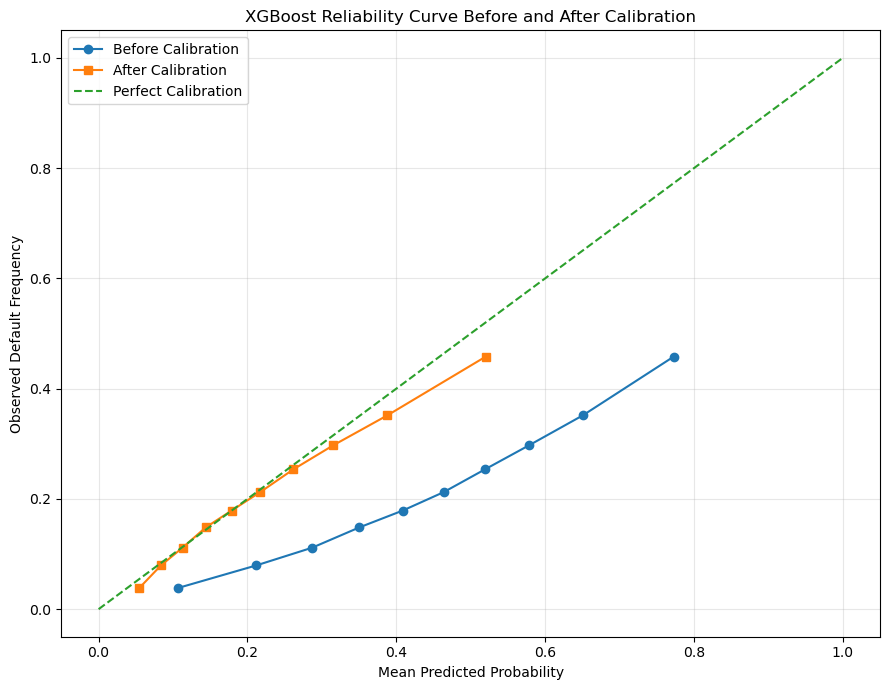

In [134]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true_before, prob_pred_before = calibration_curve(
    y_test,
    xgb_test_prob,
    n_bins=10,
    strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_test,
    xgb_test_prob_calibrated,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(9, 7))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="Before Calibration"
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="s",
    label="After Calibration"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Frequency")

plt.title(
    "XGBoost Reliability Curve Before and After Calibration"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [135]:
# Save calibrated test probabilities for future use
np.save(
    "xgb_test_prob_calibrated.npy",
    xgb_test_prob_calibrated
)

np.save(
    "xgb_test_prob_original.npy",
    xgb_test_prob
)

print("Calibrated probabilities saved successfully.")

Calibrated probabilities saved successfully.


In [136]:
# Calibrate validation probabilities
xgb_val_prob_calibrated = (
    platt_calibrator.predict_proba(
        xgb_val_prob.reshape(-1, 1)
    )[:, 1]
)

print(
    "Validation calibrated probabilities generated:",
    len(xgb_val_prob_calibrated)
)

Validation calibrated probabilities generated: 293105


In [137]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.02)

for threshold in thresholds:

    y_val_pred_threshold = (
        xgb_val_prob_calibrated >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred_threshold,
        zero_division=0
    )

    threshold_results.append({

        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1

    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1_Score": "{:.4f}"
    })
)

,Threshold,Precision,Recall,F1_Score
0,0.10,0.2733,0.9477,0.4243
1,0.12,0.2883,0.9148,0.4384
2,0.14,0.3033,0.8771,0.4507
3,0.16,0.3173,0.8346,0.4598
4,0.18,0.3312,0.7902,0.4668
5,0.20,0.3451,0.7442,0.4716
6,0.22,0.3584,0.6973,0.4735
7,0.24,0.3722,0.6503,0.4734
8,0.26,0.3867,0.6040,0.4715
9,0.28,0.4003,0.5564,0.4656


In [138]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1_Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Optimal validation threshold:", round(best_threshold, 2))
print("Validation precision:", round(
    best_threshold_row["Precision"], 4
))
print("Validation recall:", round(
    best_threshold_row["Recall"], 4
))
print("Validation F1-score:", round(
    best_threshold_row["F1_Score"], 4
))

Optimal validation threshold: 0.22
Validation precision: 0.3584
Validation recall: 0.6973
Validation F1-score: 0.4735


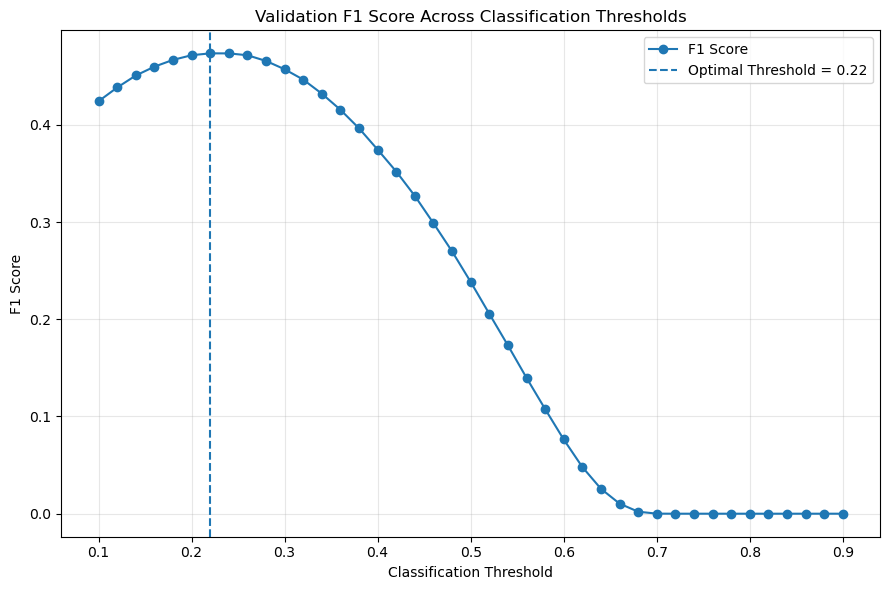

In [139]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1_Score"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Optimal Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")

plt.title("Validation F1 Score Across Classification Thresholds")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [140]:
print("Probability variables available:\n")

available_probabilities = {}

for name, value in list(globals().items()):
    if "prob" in name.lower():
        try:
            if hasattr(value, "shape"):
                available_probabilities[name] = value.shape
        except Exception:
            pass

for name, shape in available_probabilities.items():
    print(f"{name} → {shape}")

Probability variables available:

val_probability → (293105,)
test_probability → (225639,)
prob_true → (10,)
prob_pred → (10,)
xgb_val_probability → (293105,)
xgb_test_probability → (225639,)
xgb_val_prob → (293105,)
xgb_test_prob → (225639,)
xgb_val_prob_2d → (293105, 1)
xgb_test_prob_2d → (225639, 1)
xgb_test_prob_calibrated → (225639,)
prob_true_before → (10,)
prob_pred_before → (10,)
prob_true_after → (10,)
prob_pred_after → (10,)
xgb_val_prob_calibrated → (293105,)


In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Use validation probabilities
validation_probabilities = xgb_val_probability

# Check target variable
print("Checking validation target...")

try:
    validation_target = y_val
    print("Validation target found: y_val")

except NameError:
    print("ERROR: y_val variable was not found.")

Checking validation target...
Validation target found: y_val


In [142]:
thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into binary predictions
    predicted_class = (
        validation_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        validation_target,
        predicted_class,
        zero_division=0
    )

    recall = recall_score(
        validation_target,
        predicted_class,
        zero_division=0
    )

    f1 = f1_score(
        validation_target,
        predicted_class,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,Threshold,Precision,Recall,F1_Score
0,0.10,0.240333,0.996513,0.387267
1,0.11,0.241792,0.995268,0.389064
2,0.12,0.243378,0.993890,0.391008
3,0.13,0.245014,0.992454,0.393004
4,0.14,0.246738,0.991077,0.395110
...,...,...,...,...
76,0.86,0.675356,0.028468,0.054633
77,0.87,0.691941,0.021259,0.041251
78,0.88,0.715072,0.015223,0.029811
79,0.89,0.732308,0.010461,0.020628


In [143]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1_Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]
best_validation_f1 = best_threshold_row["F1_Score"]

print("BEST VALIDATION THRESHOLD")
print("-" * 35)

print(f"Threshold: {best_threshold:.2f}")
print(f"Validation F1 Score: {best_validation_f1:.4f}")
print(f"Precision: {best_threshold_row['Precision']:.4f}")
print(f"Recall: {best_threshold_row['Recall']:.4f}")

BEST VALIDATION THRESHOLD
-----------------------------------
Threshold: 0.48
Validation F1 Score: 0.4738
Precision: 0.3649
Recall: 0.6754


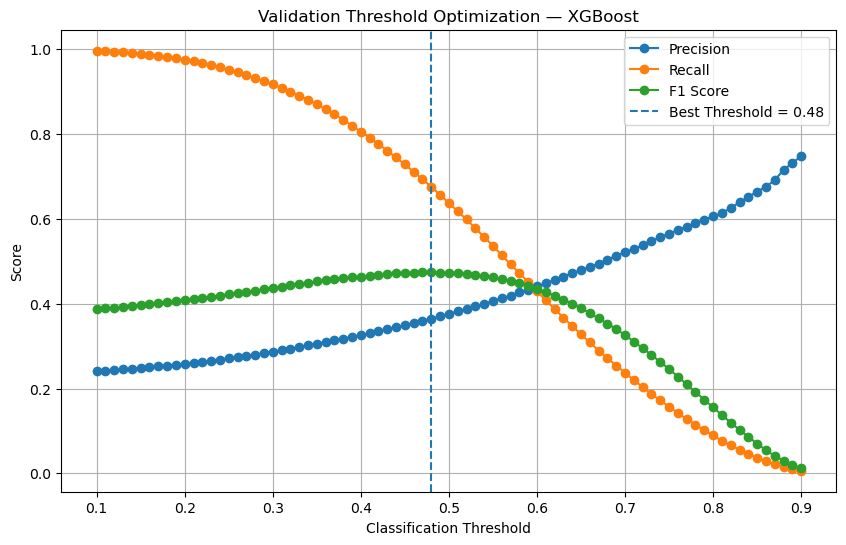

In [144]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1_Score"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Validation Threshold Optimization — XGBoost")
plt.legend()
plt.grid(True)
plt.show()

In [145]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Use the threshold selected from validation
test_predictions_optimal = (
    xgb_test_probability >= best_threshold
).astype(int)

# Test metrics
test_accuracy = accuracy_score(
    y_test,
    test_predictions_optimal
)

test_precision = precision_score(
    y_test,
    test_predictions_optimal,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions_optimal,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions_optimal,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    xgb_test_probability
)

test_pr_auc = average_precision_score(
    y_test,
    xgb_test_probability
)

print("XGBOOST TEST EVALUATION")
print("=" * 45)

print(f"Selected threshold: {best_threshold:.2f}")
print(f"Accuracy:            {test_accuracy:.4f}")
print(f"Precision:           {test_precision:.4f}")
print(f"Recall:              {test_recall:.4f}")
print(f"F1 Score:            {test_f1:.4f}")
print(f"ROC-AUC:             {test_roc_auc:.4f}")
print(f"PR-AUC:              {test_pr_auc:.4f}")

XGBOOST TEST EVALUATION
Selected threshold: 0.48
Accuracy:            0.6485
Precision:           0.3350
Recall:              0.6608
F1 Score:            0.4446
ROC-AUC:             0.7105
PR-AUC:              0.3844


Confusion Matrix:
[[114571  63025]
 [ 16296  31747]]


<Figure size 700x600 with 0 Axes>

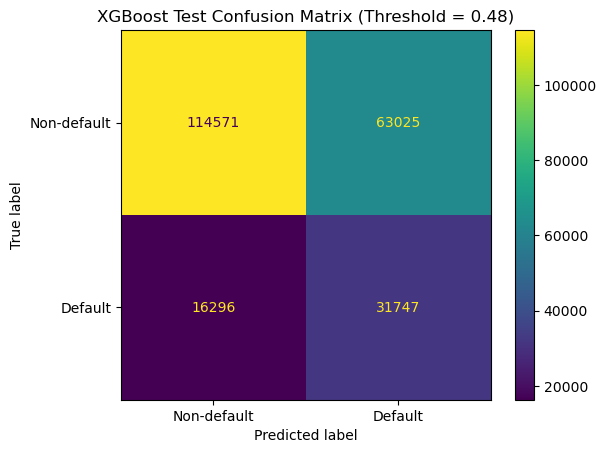

In [146]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_test_optimal = confusion_matrix(
    y_test,
    test_predictions_optimal
)

print("Confusion Matrix:")
print(cm_test_optimal)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_optimal,
    display_labels=["Non-default", "Default"]
)

disp.plot(values_format="d")

plt.title(
    f"XGBoost Test Confusion Matrix "
    f"(Threshold = {best_threshold:.2f})"
)

plt.show()

In [147]:
print("CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_test,
        test_predictions_optimal,
        target_names=["Non-default", "Default"],
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Non-default       0.88      0.65      0.74    177596
     Default       0.33      0.66      0.44     48043

    accuracy                           0.65    225639
   macro avg       0.61      0.65      0.59    225639
weighted avg       0.76      0.65      0.68    225639



In [148]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

threshold_comparison = []

for threshold, threshold_name in [
    (0.50, "Default 0.50"),
    (best_threshold, "Validation Optimized")
]:

    predictions = (
        xgb_test_probability >= threshold
    ).astype(int)

    threshold_comparison.append({
        "Threshold Type": threshold_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test, predictions
        ),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        )
    })

threshold_comparison_df = pd.DataFrame(
    threshold_comparison
)

display(
    threshold_comparison_df.round(4)
)

,Threshold Type,Threshold,Accuracy,Precision,Recall,F1 Score
0,Default 0.50,0.50,0.6681,0.3449,0.6218,0.4437
1,Validation Optimized,0.48,0.6485,0.3350,0.6608,0.4446


In [149]:
from sklearn.metrics import confusion_matrix

for threshold, threshold_name in [
    (0.50, "Default 0.50"),
    (best_threshold, "Validation Optimized")
]:

    predictions = (
        xgb_test_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    print(f"\n{threshold_name}")
    print("-" * 35)
    print(f"True Negatives:  {tn:,}")
    print(f"False Positives: {fp:,}")
    print(f"False Negatives: {fn:,}")
    print(f"True Positives:  {tp:,}")


Default 0.50
-----------------------------------
True Negatives:  120,866
False Positives: 56,730
False Negatives: 18,170
True Positives:  29,873

Validation Optimized
-----------------------------------
True Negatives:  114,571
False Positives: 63,025
False Negatives: 16,296
True Positives:  31,747


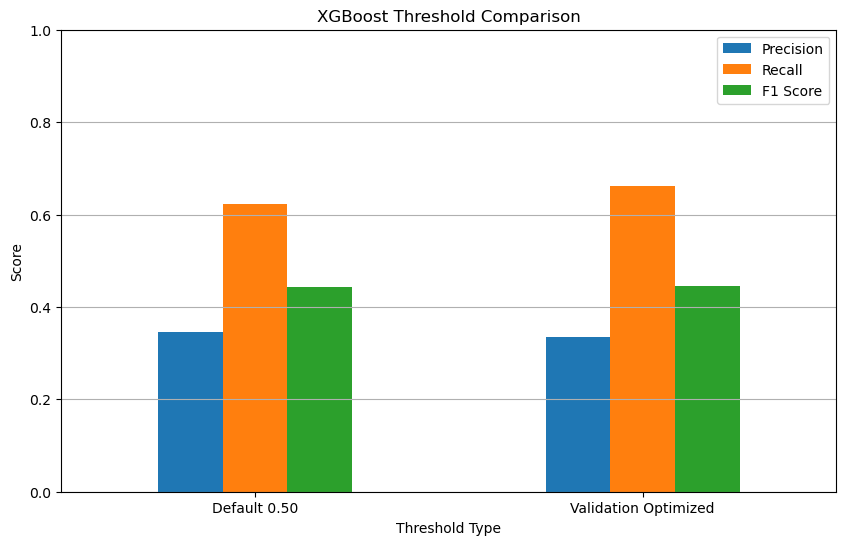

In [150]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1 Score"
]

comparison_plot_df = threshold_comparison_df.set_index(
    "Threshold Type"
)[metrics_to_plot]

comparison_plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("XGBoost Threshold Comparison")
plt.xlabel("Threshold Type")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend()
plt.show()

In [151]:
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score
)

# Original XGBoost probabilities
original_test_prob = xgb_test_probability

# Calibrated XGBoost probabilities
calibrated_test_prob = xgb_test_prob_calibrated

calibration_comparison = pd.DataFrame({
    "Metric": [
        "Brier Score",
        "Log Loss",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Before Calibration": [
        brier_score_loss(y_test, original_test_prob),
        log_loss(y_test, original_test_prob),
        roc_auc_score(y_test, original_test_prob),
        average_precision_score(y_test, original_test_prob)
    ],
    "After Calibration": [
        brier_score_loss(y_test, calibrated_test_prob),
        log_loss(y_test, calibrated_test_prob),
        roc_auc_score(y_test, calibrated_test_prob),
        average_precision_score(y_test, calibrated_test_prob)
    ]
})

display(calibration_comparison.round(4))

,Metric,Before Calibration,After Calibration
0,Brier Score,0.2068,0.1525
1,Log Loss,0.5976,0.4711
2,ROC-AUC,0.7105,0.7105
3,PR-AUC,0.3844,0.3844


In [152]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Calibrated validation probabilities
calibrated_val_prob = xgb_val_prob_calibrated

thresholds = np.arange(0.05, 0.91, 0.01)

calibrated_threshold_results = []

for threshold in thresholds:

    predictions = (
        calibrated_val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    calibrated_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1
    })

calibrated_threshold_df = pd.DataFrame(
    calibrated_threshold_results
)

display(
    calibrated_threshold_df.round(4)
)

,Threshold,Precision,Recall,F1_Score
0,0.05,0.2386,0.9977,0.3851
1,0.06,0.2453,0.9922,0.3934
2,0.07,0.2521,0.9852,0.4015
3,0.08,0.2589,0.9746,0.4091
4,0.09,0.2659,0.9619,0.4166
...,...,...,...,...
81,0.86,0.0000,0.0000,0.0000
82,0.87,0.0000,0.0000,0.0000
83,0.88,0.0000,0.0000,0.0000
84,0.89,0.0000,0.0000,0.0000


In [153]:
best_calibrated_row = calibrated_threshold_df.loc[
    calibrated_threshold_df["F1_Score"].idxmax()
]

best_calibrated_threshold = (
    best_calibrated_row["Threshold"]
)

print("BEST CALIBRATED VALIDATION THRESHOLD")
print("=" * 50)

print(
    f"Threshold: {best_calibrated_threshold:.2f}"
)

print(
    f"Validation F1 Score: "
    f"{best_calibrated_row['F1_Score']:.4f}"
)

print(
    f"Precision: "
    f"{best_calibrated_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_calibrated_row['Recall']:.4f}"
)

BEST CALIBRATED VALIDATION THRESHOLD
Threshold: 0.23
Validation F1 Score: 0.4737
Precision: 0.3652
Recall: 0.6738


In [154]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calibrated test predictions
calibrated_test_predictions = (
    xgb_test_prob_calibrated >= best_calibrated_threshold
).astype(int)

# Calculate metrics
calibrated_test_accuracy = accuracy_score(
    y_test,
    calibrated_test_predictions
)

calibrated_test_precision = precision_score(
    y_test,
    calibrated_test_predictions,
    zero_division=0
)

calibrated_test_recall = recall_score(
    y_test,
    calibrated_test_predictions,
    zero_division=0
)

calibrated_test_f1 = f1_score(
    y_test,
    calibrated_test_predictions,
    zero_division=0
)

print("CALIBRATED XGBOOST TEST RESULTS")
print("=" * 50)

print(f"Threshold:  {best_calibrated_threshold:.2f}")
print(f"Accuracy:   {calibrated_test_accuracy:.4f}")
print(f"Precision:  {calibrated_test_precision:.4f}")
print(f"Recall:     {calibrated_test_recall:.4f}")
print(f"F1 Score:   {calibrated_test_f1:.4f}")

CALIBRATED XGBOOST TEST RESULTS
Threshold:  0.23
Accuracy:   0.6493
Precision:  0.3354
Recall:     0.6593
F1 Score:   0.4446


In [155]:
cm_calibrated = confusion_matrix(
    y_test,
    calibrated_test_predictions
)

print("Confusion Matrix:")
print(cm_calibrated)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        calibrated_test_predictions,
        target_names=["Non-default", "Default"],
        zero_division=0
    )
)

Confusion Matrix:
[[114823  62773]
 [ 16367  31676]]

Classification Report:
              precision    recall  f1-score   support

 Non-default       0.88      0.65      0.74    177596
     Default       0.34      0.66      0.44     48043

    accuracy                           0.65    225639
   macro avg       0.61      0.65      0.59    225639
weighted avg       0.76      0.65      0.68    225639



In [156]:
# Final XGBoost results

xgb_final_results = pd.DataFrame({
    "Model": ["XGBoost Calibrated"],
    "Threshold": [best_calibrated_threshold],
    "Accuracy": [calibrated_test_accuracy],
    "Precision": [calibrated_test_precision],
    "Recall": [calibrated_test_recall],
    "F1 Score": [calibrated_test_f1],
    "ROC-AUC": [test_roc_auc],
    "PR-AUC": [test_pr_auc]
})

display(xgb_final_results.round(4))

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost Calibrated,0.23,0.6493,0.3354,0.6593,0.4446,0.7105,0.3844


In [157]:
print("AVAILABLE DATA VARIABLES")
print("=" * 40)

variables_to_check = [
    "model_data",
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test"
]

for variable_name in variables_to_check:

    if variable_name in globals():

        variable = globals()[variable_name]

        try:
            print(
                f"{variable_name}: "
                f"shape = {variable.shape}"
            )

        except AttributeError:

            print(
                f"{variable_name}: "
                f"type = {type(variable)}"
            )

    else:

        print(f"{variable_name}: NOT FOUND")

AVAILABLE DATA VARIABLES
model_data: shape = (1345350, 55)
X_train: shape = (826606, 51)
X_val: shape = (293105, 51)
X_test: shape = (225639, 51)
y_train: shape = (826606,)
y_val: shape = (293105,)
y_test: shape = (225639,)


In [158]:
# ============================================
# GNN CELL 1: IMPORTS AND DATA CHECK
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

print("✅ Basic libraries imported successfully.")

# Check PyTorch
print("\nPyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Check existing datasets
print("\nAVAILABLE DATASETS")
print("=" * 40)

print("model_data shape:", model_data.shape)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

# Display column names
print("\nMODEL DATA COLUMNS")
print("=" * 40)

print(model_data.columns.tolist())

✅ Basic libraries imported successfully.

PyTorch version: 2.13.0+cpu
CUDA available: False

AVAILABLE DATASETS
model_data shape: (1345350, 55)
X_train shape: (826606, 51)
X_val shape: (293105, 51)
X_test shape: (225639, 51)

y_train shape: (826606,)
y_val shape: (293105,)
y_test shape: (225639,)

MODEL DATA COLUMNS
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'term_months', 'grade', 'sub_grade', 'emp_length_years', 'home_ownership', 'annual_inc', 'annual_inc_log', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'fico_avg', 'fico_range', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_bal_log', 'revol_util', 'total_acc', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'tot_cur_bal_log', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'credit_history_years', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'p

In [159]:
# ============================================
# GNN CELL 2: GRAPH FEATURE SELECTION
# ============================================

print("STARTING GRAPH FEATURE SELECTION")
print("=" * 50)

# Features used to represent borrower/loan characteristics
gnn_features = [
    "loan_amnt",
    "int_rate",
    "installment",
    "term_months",
    "emp_length_years",
    "annual_inc_log",
    "dti",
    "delinq_2yrs",
    "fico_avg",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal_log",
    "revol_util",
    "total_acc",
    "tot_cur_bal_log",
    "total_rev_hi_lim",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_util",
    "credit_history_years",
    "mort_acc",
    "loan_to_income",
    "installment_to_income",
    "revolving_utilization_decimal",
    "bc_utilization_decimal"
]

# Check whether all features exist
missing_gnn_features = [
    feature for feature in gnn_features
    if feature not in model_data.columns
]

print("Total selected features:", len(gnn_features))
print("Missing features:", missing_gnn_features)

# Stop if any feature is missing
if len(missing_gnn_features) > 0:
    raise ValueError(
        f"Missing GNN features: {missing_gnn_features}"
    )

# Create feature dataset
gnn_feature_data = model_data[gnn_features].copy()

# Replace infinite values
gnn_feature_data = gnn_feature_data.replace(
    [np.inf, -np.inf],
    np.nan
)

# Display missing values
missing_summary = (
    gnn_feature_data.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nMISSING VALUES")
print("=" * 50)

display(
    missing_summary[
        missing_summary > 0
    ].to_frame("Missing Count")
)

# Fill missing values using median
gnn_feature_data = gnn_feature_data.fillna(
    gnn_feature_data.median()
)

print("\nFinal feature dataset shape:")
print(gnn_feature_data.shape)

print("\nRemaining missing values:")
print(gnn_feature_data.isnull().sum().sum())

print("\n✅ GNN feature selection completed.")

STARTING GRAPH FEATURE SELECTION
Total selected features: 26
Missing features: []

MISSING VALUES


,Missing Count
emp_length_years,78516
avg_cur_bal,67549
total_rev_hi_lim,67527
tot_cur_bal_log,67527
bc_util,61914
bc_utilization_decimal,61914
mort_acc,47281
acc_open_past_24mths,47281
revol_util,857
revolving_utilization_decimal,857



Final feature dataset shape:
(1345350, 26)

Remaining missing values:
0

✅ GNN feature selection completed.


In [160]:
# ============================================
# GNN CELL 3: DATASET DISTRIBUTION CHECK
# ============================================

print("GNN DATASET DISTRIBUTION")
print("=" * 50)

# Check issue-year distribution
print("\n1. ISSUE YEAR DISTRIBUTION")
print("-" * 50)

year_distribution = (
    model_data["issue_year"]
    .value_counts()
    .sort_index()
)

display(
    year_distribution.to_frame("Number of Records")
)

# Check default distribution by year
print("\n2. DEFAULT DISTRIBUTION BY YEAR")
print("-" * 50)

default_by_year = pd.crosstab(
    model_data["issue_year"],
    model_data["default"]
)

display(default_by_year)

# Overall target distribution
print("\n3. OVERALL TARGET DISTRIBUTION")
print("-" * 50)

target_distribution = (
    model_data["default"]
    .value_counts(dropna=False)
    .sort_index()
)

display(
    target_distribution.to_frame("Number of Records")
)

# Default rate by year
print("\n4. DEFAULT RATE BY YEAR (%)")
print("-" * 50)

default_rate_by_year = (
    model_data.groupby("issue_year")["default"]
    .mean()
    .mul(100)
    .round(2)
)

display(
    default_rate_by_year.to_frame("Default Rate (%)")
)

print("\n✅ Distribution check completed.")

GNN DATASET DISTRIBUTION

1. ISSUE YEAR DISTRIBUTION
--------------------------------------------------


,Number of Records
issue_year,
2007,251
2008,1562
2009,4716
2010,11536
2011,21721
2012,53367
2013,134804
2014,223103
2015,375546



2. DEFAULT DISTRIBUTION BY YEAR
--------------------------------------------------


default,0,1
issue_year,,
2007,206,45
2008,1315,247
2009,4122,594
2010,10049,1487
2011,18424,3297
2012,44723,8644
2013,113780,21024
2014,181941,41162
2015,299742,75804



3. OVERALL TARGET DISTRIBUTION
--------------------------------------------------


,Number of Records
default,
0,1076751
1,268599



4. DEFAULT RATE BY YEAR (%)
--------------------------------------------------


,Default Rate (%)
issue_year,
2007,17.93
2008,15.81
2009,12.60
2010,12.89
2011,15.18
2012,16.20
2013,15.60
2014,18.45
2015,20.19



✅ Distribution check completed.


In [162]:
# ============================================
# GNN CELL 4: CORRECTED GRAPH SAMPLING
# ============================================

import pandas as pd
import numpy as np

print("CREATING GNN GRAPH SAMPLE")
print("=" * 55)

# --------------------------------------------
# 1. Copy dataset and convert year to numeric
# --------------------------------------------

graph_data = model_data.copy()

graph_data["issue_year_numeric"] = pd.to_numeric(
    graph_data["issue_year"],
    errors="coerce"
)

# Remove records with invalid years
graph_data = graph_data.dropna(
    subset=["issue_year_numeric"]
).copy()

graph_data["issue_year_numeric"] = (
    graph_data["issue_year_numeric"].astype(int)
)

# --------------------------------------------
# 2. Create temporal split labels
# --------------------------------------------

graph_data["graph_split"] = np.select(
    [
        graph_data["issue_year_numeric"] <= 2015,
        graph_data["issue_year_numeric"] == 2016,
        graph_data["issue_year_numeric"] >= 2017
    ],
    [
        "train",
        "validation",
        "test"
    ],
    default="unknown"
)

# --------------------------------------------
# 3. Check split sizes
# --------------------------------------------

print("\nTEMPORAL SPLIT DISTRIBUTION")
print("-" * 55)

split_counts = graph_data["graph_split"].value_counts()

display(
    split_counts.to_frame("Number of Records")
)

# --------------------------------------------
# 4. Define sample sizes
# --------------------------------------------

sample_sizes = {
    "train": 20000,
    "validation": 5000,
    "test": 5000
}

sampled_parts = []

# --------------------------------------------
# 5. Stratified sampling manually
# --------------------------------------------

for split_name, sample_size in sample_sizes.items():

    split_data = graph_data[
        graph_data["graph_split"] == split_name
    ].copy()

    print(
        f"\n{split_name.upper()} records available:",
        len(split_data)
    )

    if len(split_data) == 0:
        raise ValueError(
            f"No records found for '{split_name}'. "
            "Check the temporal split conditions."
        )

    actual_sample_size = min(
        sample_size,
        len(split_data)
    )

    # Proportional sampling from each target class
    sampled_data = (
        split_data
        .groupby("default", group_keys=False)
        .apply(
            lambda group: group.sample(
                n=max(
                    1,
                    round(
                        actual_sample_size
                        * len(group)
                        / len(split_data)
                    )
                ),
                random_state=42
            )
        )
        .reset_index(drop=True)
    )

    # Correct sample size if rounding creates extra records
    if len(sampled_data) > actual_sample_size:

        sampled_data = sampled_data.sample(
            n=actual_sample_size,
            random_state=42
        )

    sampled_parts.append(sampled_data)

    print(
        f"{split_name.upper()} records selected:",
        len(sampled_data)
    )

# --------------------------------------------
# 6. Combine sampled records
# --------------------------------------------

gnn_sample = (
    pd.concat(sampled_parts, axis=0)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# --------------------------------------------
# 7. Extract features and labels
# --------------------------------------------

gnn_sample_features = gnn_sample[
    gnn_features
].copy()

gnn_sample_labels = gnn_sample[
    "default"
].astype(int).copy()

gnn_sample_split = gnn_sample[
    "graph_split"
].copy()

# --------------------------------------------
# 8. Final verification
# --------------------------------------------

print("\nFINAL GNN SAMPLE")
print("=" * 55)

print("Feature shape:", gnn_sample_features.shape)
print("Label shape:", gnn_sample_labels.shape)
print("Total graph nodes:", len(gnn_sample))

print("\nSplit distribution:")
display(
    gnn_sample_split.value_counts()
)

print("\nDefault distribution:")
display(
    gnn_sample_labels.value_counts()
)

print("\nDefault rate by split:")
display(
    pd.crosstab(
        gnn_sample_split,
        gnn_sample_labels,
        normalize="index"
    ).round(4)
)

print("\n✅ Corrected GNN graph sample created.")

CREATING GNN GRAPH SAMPLE

TEMPORAL SPLIT DISTRIBUTION
-------------------------------------------------------


,Number of Records
graph_split,
train,826606
validation,293105
test,225639



TRAIN records available: 826606
TRAIN records selected: 20000

VALIDATION records available: 293105
VALIDATION records selected: 5000

TEST records available: 225639
TEST records selected: 5000

FINAL GNN SAMPLE
Feature shape: (30000, 26)
Label shape: (30000,)
Total graph nodes: 30000

Split distribution:


graph_split
train         20000
validation     5000
test           5000
Name: count, dtype: int64


Default distribution:


default
0    24086
1     5914
Name: count, dtype: int64


Default rate by split:


default,0,1
graph_split,,
test,0.7870,0.2130
train,0.8158,0.1842
validation,0.7672,0.2328



✅ Corrected GNN graph sample created.


In [163]:
# ============================================
# GNN CELL 5: FEATURE STANDARDIZATION
# ============================================

from sklearn.preprocessing import StandardScaler
import numpy as np

print("STANDARDIZING GNN FEATURES")
print("=" * 55)

# --------------------------------------------
# 1. Identify training nodes
# --------------------------------------------

train_mask = (
    gnn_sample_split == "train"
).to_numpy()

validation_mask = (
    gnn_sample_split == "validation"
).to_numpy()

test_mask = (
    gnn_sample_split == "test"
).to_numpy()

# --------------------------------------------
# 2. Fit scaler only on training features
# --------------------------------------------

gnn_scaler = StandardScaler()

gnn_scaler.fit(
    gnn_sample_features.loc[train_mask]
)

# --------------------------------------------
# 3. Transform all feature data
# --------------------------------------------

gnn_features_scaled = gnn_scaler.transform(
    gnn_sample_features
)

# --------------------------------------------
# 4. Check results
# --------------------------------------------

print("Original feature shape:")
print(gnn_sample_features.shape)

print("\nScaled feature shape:")
print(gnn_features_scaled.shape)

print("\nTraining feature mean:")
print(
    np.mean(
        gnn_features_scaled[train_mask],
        axis=0
    ).round(4)
)

print("\nTraining feature standard deviation:")
print(
    np.std(
        gnn_features_scaled[train_mask],
        axis=0
    ).round(4)
)

print("\nAny NaN values:")
print(
    np.isnan(gnn_features_scaled).sum()
)

print("\nAny infinite values:")
print(
    np.isinf(gnn_features_scaled).sum()
)

print("\n✅ GNN feature standardization completed.")

STANDARDIZING GNN FEATURES
Original feature shape:
(30000, 26)

Scaled feature shape:
(30000, 26)

Training feature mean:
[-0. -0.  0.  0. nan -0. -0.  0.  0.  0.  0.  0.  0. nan  0. nan nan nan
 nan nan  0. nan -0.  0. nan nan]

Training feature standard deviation:
[ 1.  1.  1.  1. nan  1.  1.  1.  1.  1.  1.  1.  1. nan  1. nan nan nan
 nan nan  1. nan  1.  1. nan nan]

Any NaN values:
12132

Any infinite values:
0

✅ GNN feature standardization completed.


In [164]:
# ============================================
# GNN CELL 6: DIAGNOSE REMAINING NaN VALUES
# ============================================

print("DIAGNOSING NaN VALUES")
print("=" * 55)

# --------------------------------------------
# 1. Check NaN values in original sample
# --------------------------------------------

original_nan_counts = (
    gnn_sample_features
    .isna()
    .sum()
)

print("\nNaN VALUES IN ORIGINAL FEATURES:")
display(
    original_nan_counts[
        original_nan_counts > 0
    ].sort_values(ascending=False)
)

# --------------------------------------------
# 2. Check NaN values after scaling
# --------------------------------------------

scaled_nan_counts = pd.Series(
    np.isnan(gnn_features_scaled).sum(axis=0),
    index=gnn_features
)

print("\nNaN VALUES AFTER STANDARDIZATION:")
display(
    scaled_nan_counts[
        scaled_nan_counts > 0
    ].sort_values(ascending=False)
)

# --------------------------------------------
# 3. Check training medians
# --------------------------------------------

training_medians = (
    gnn_sample_features.loc[train_mask]
    .median()
)

print("\nTRAINING MEDIANS THAT ARE NaN:")
display(
    training_medians[
        training_medians.isna()
    ]
)

# --------------------------------------------
# 4. Identify constant columns
# --------------------------------------------

training_std = (
    gnn_sample_features.loc[train_mask]
    .std()
)

print("\nCONSTANT OR ZERO-VARIANCE COLUMNS:")
display(
    training_std[
        (training_std == 0) |
        (training_std.isna())
    ]
)

print("\n✅ NaN diagnosis completed.")

DIAGNOSING NaN VALUES

NaN VALUES IN ORIGINAL FEATURES:


emp_length_years                 1772
total_rev_hi_lim                 1664
tot_cur_bal_log                  1664
avg_cur_bal                      1664
bc_util                          1489
bc_utilization_decimal           1489
acc_open_past_24mths             1165
mort_acc                         1165
revol_util                         19
revolving_utilization_decimal      19
dti                                 8
installment_to_income               7
loan_to_income                      7
dtype: int64


NaN VALUES AFTER STANDARDIZATION:


emp_length_years                 1772
total_rev_hi_lim                 1664
tot_cur_bal_log                  1664
avg_cur_bal                      1664
bc_util                          1489
bc_utilization_decimal           1489
acc_open_past_24mths             1165
mort_acc                         1165
revol_util                         19
revolving_utilization_decimal      19
dti                                 8
installment_to_income               7
loan_to_income                      7
dtype: int64


TRAINING MEDIANS THAT ARE NaN:


Series([], dtype: Float64)


CONSTANT OR ZERO-VARIANCE COLUMNS:


Series([], dtype: Float64)


✅ NaN diagnosis completed.


In [165]:
# ============================================
# GNN CELL 7: FIX NaN AND STANDARDIZE
# ============================================

print("FIXING MISSING VALUES")
print("=" * 55)

# --------------------------------------------
# 1. Calculate medians using training data only
# --------------------------------------------

training_medians = (
    gnn_sample_features.loc[train_mask]
    .median()
)

# --------------------------------------------
# 2. Fill missing values in all splits
# --------------------------------------------

gnn_sample_features_clean = (
    gnn_sample_features
    .fillna(training_medians)
)

# --------------------------------------------
# 3. Handle any remaining missing values
# --------------------------------------------

remaining_nan = (
    gnn_sample_features_clean
    .isna()
    .sum()
)

print("Remaining NaN values before scaling:")
display(
    remaining_nan[remaining_nan > 0]
)

# --------------------------------------------
# 4. Fit scaler only on training data
# --------------------------------------------

gnn_scaler = StandardScaler()

gnn_scaler.fit(
    gnn_sample_features_clean.loc[train_mask]
)

# --------------------------------------------
# 5. Transform all data
# --------------------------------------------

gnn_features_scaled = gnn_scaler.transform(
    gnn_sample_features_clean
)

# --------------------------------------------
# 6. Final validation
# --------------------------------------------

print("\nFINAL VALIDATION")
print("=" * 55)

print(
    "Scaled shape:",
    gnn_features_scaled.shape
)

print(
    "Total NaN values:",
    np.isnan(gnn_features_scaled).sum()
)

print(
    "Total infinite values:",
    np.isinf(gnn_features_scaled).sum()
)

print("\nTraining mean:")
print(
    np.mean(
        gnn_features_scaled[train_mask],
        axis=0
    ).round(4)
)

print("\nTraining standard deviation:")
print(
    np.std(
        gnn_features_scaled[train_mask],
        axis=0
    ).round(4)
)

print("\n✅ Missing values fixed and features standardized.")

FIXING MISSING VALUES
Remaining NaN values before scaling:


Series([], dtype: int64)


FINAL VALIDATION
Scaled shape: (30000, 26)
Total NaN values: 0
Total infinite values: 0

Training mean:
[-0. -0.  0.  0.  0. -0. -0.  0.  0.  0.  0.  0.  0.  0.  0. -0. -0.  0.
 -0. -0.  0.  0. -0.  0.  0.  0.]

Training standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]

✅ Missing values fixed and features standardized.


In [166]:
# ============================================
# GNN CELL 8: CONVERT DATA TO PYTORCH TENSORS
# ============================================

import torch

print("CONVERTING DATA TO PYTORCH TENSORS")
print("=" * 55)

# --------------------------------------------
# 1. Convert features
# --------------------------------------------

gnn_x = torch.tensor(
    gnn_features_scaled,
    dtype=torch.float32
)

# --------------------------------------------
# 2. Convert labels
# --------------------------------------------

gnn_y = torch.tensor(
    gnn_sample_labels.to_numpy(),
    dtype=torch.long
)

# --------------------------------------------
# 3. Convert split masks
# --------------------------------------------

gnn_train_mask = torch.tensor(
    train_mask,
    dtype=torch.bool
)

gnn_validation_mask = torch.tensor(
    validation_mask,
    dtype=torch.bool
)

gnn_test_mask = torch.tensor(
    test_mask,
    dtype=torch.bool
)

# --------------------------------------------
# 4. Display tensor information
# --------------------------------------------

print("Feature tensor shape:", gnn_x.shape)
print("Label tensor shape:", gnn_y.shape)

print("Feature tensor dtype:", gnn_x.dtype)
print("Label tensor dtype:", gnn_y.dtype)

print("\nTraining nodes:", gnn_train_mask.sum().item())
print("Validation nodes:", gnn_validation_mask.sum().item())
print("Testing nodes:", gnn_test_mask.sum().item())

print("\nFeature tensor device:", gnn_x.device)

print("\n✅ PyTorch tensors created successfully.")

CONVERTING DATA TO PYTORCH TENSORS
Feature tensor shape: torch.Size([30000, 26])
Label tensor shape: torch.Size([30000])
Feature tensor dtype: torch.float32
Label tensor dtype: torch.int64

Training nodes: 20000
Validation nodes: 5000
Testing nodes: 5000

Feature tensor device: cpu

✅ PyTorch tensors created successfully.


In [167]:
# ============================================
# GNN CELL 9: BUILD KNN SIMILARITY GRAPH
# ============================================

from sklearn.neighbors import NearestNeighbors
import numpy as np

print("BUILDING KNN SIMILARITY GRAPH")
print("=" * 55)

# --------------------------------------------
# 1. Define number of neighbors
# --------------------------------------------

k_neighbors = 8

# --------------------------------------------
# 2. Fit KNN on standardized features
# --------------------------------------------

knn_model = NearestNeighbors(
    n_neighbors=k_neighbors + 1,
    metric="euclidean",
    algorithm="auto",
    n_jobs=-1
)

knn_model.fit(gnn_features_scaled)

# --------------------------------------------
# 3. Find nearest neighbors
# --------------------------------------------

distances, neighbor_indices = (
    knn_model.kneighbors(gnn_features_scaled)
)

# --------------------------------------------
# 4. Remove self-neighbor
# --------------------------------------------

neighbor_indices = neighbor_indices[:, 1:]
distances = distances[:, 1:]

# --------------------------------------------
# 5. Display graph information
# --------------------------------------------

number_of_nodes = gnn_x.shape[0]
number_of_edges_directed = (
    number_of_nodes * k_neighbors
)

print("Number of nodes:", number_of_nodes)
print("Neighbors per node:", k_neighbors)

print(
    "Directed edges:",
    number_of_edges_directed
)

print("Neighbor index shape:", neighbor_indices.shape)
print("Distance shape:", distances.shape)

print("\nExample neighbors of node 0:")
print(neighbor_indices[0])

print("\nExample distances of node 0:")
print(distances[0].round(4))

print("\nMinimum distance:", distances.min())
print("Maximum distance:", distances.max())

print("\n✅ KNN neighbor search completed.")

BUILDING KNN SIMILARITY GRAPH
Number of nodes: 30000
Neighbors per node: 8
Directed edges: 240000
Neighbor index shape: (30000, 8)
Distance shape: (30000, 8)

Example neighbors of node 0:
[23538 15124 14672 15642 12109  3718 18701 23960]

Example distances of node 0:
[3.9145 4.5043 4.5614 4.7609 5.229  5.3268 5.6792 5.7137]

Minimum distance: 0.19047142835307806
Maximum distance: 305516.2546928513

✅ KNN neighbor search completed.


In [168]:
# ============================================
# GNN CELL 10: CREATE EDGE INDEX
# ============================================

print("CREATING GRAPH EDGE INDEX")
print("=" * 55)

# --------------------------------------------
# 1. Create source node indices
# --------------------------------------------

source_nodes = np.repeat(
    np.arange(number_of_nodes),
    k_neighbors
)

# --------------------------------------------
# 2. Flatten neighbor indices
# --------------------------------------------

target_nodes = neighbor_indices.reshape(-1)

# --------------------------------------------
# 3. Convert edges into PyTorch tensor
# --------------------------------------------

gnn_edge_index = torch.tensor(
    np.vstack([
        source_nodes,
        target_nodes
    ]),
    dtype=torch.long
)

# --------------------------------------------
# 4. Validate edge index
# --------------------------------------------

print("Edge index shape:", gnn_edge_index.shape)

print(
    "Number of edges:",
    gnn_edge_index.shape[1]
)

print(
    "Minimum node index:",
    gnn_edge_index.min().item()
)

print(
    "Maximum node index:",
    gnn_edge_index.max().item()
)

print("\nFirst 10 edges:")
print(gnn_edge_index[:, :10])

print("\nExpected node index range:")
print(f"0 to {number_of_nodes - 1}")

print("\n✅ Edge index created successfully.")

CREATING GRAPH EDGE INDEX
Edge index shape: torch.Size([2, 240000])
Number of edges: 240000
Minimum node index: 0
Maximum node index: 29999

First 10 edges:
tensor([[    0,     0,     0,     0,     0,     0,     0,     0,     1,     1],
        [23538, 15124, 14672, 15642, 12109,  3718, 18701, 23960, 15830, 10018]])

Expected node index range:
0 to 29999

✅ Edge index created successfully.


In [169]:
# ============================================
# GNN CELL 11: MAKE GRAPH UNDIRECTED
# ============================================

print("CONVERTING GRAPH TO UNDIRECTED")
print("=" * 55)

# Reverse every edge
reverse_edge_index = gnn_edge_index[
    [1, 0], :
]

# Combine original and reverse edges
gnn_edge_index_undirected = torch.cat(
    [
        gnn_edge_index,
        reverse_edge_index
    ],
    dim=1
)

# Remove duplicate edges
gnn_edge_index_undirected = torch.unique(
    gnn_edge_index_undirected,
    dim=1
)

# Final validation
print(
    "Original edge count:",
    gnn_edge_index.shape[1]
)

print(
    "Undirected edge count:",
    gnn_edge_index_undirected.shape[1]
)

print(
    "Edge index shape:",
    gnn_edge_index_undirected.shape
)

print(
    "Minimum node index:",
    gnn_edge_index_undirected.min().item()
)

print(
    "Maximum node index:",
    gnn_edge_index_undirected.max().item()
)

print("\n✅ Undirected graph created successfully.")

CONVERTING GRAPH TO UNDIRECTED
Original edge count: 240000
Undirected edge count: 369098
Edge index shape: torch.Size([2, 369098])
Minimum node index: 0
Maximum node index: 29999

✅ Undirected graph created successfully.


In [170]:
# ============================================
# GNN CELL 12: CREATE PYTORCH GEOMETRIC DATA
# ============================================

from torch_geometric.data import Data

print("CREATING PYTORCH GEOMETRIC DATA")
print("=" * 55)

# Create graph data object
gnn_data = Data(
    x=gnn_x,
    edge_index=gnn_edge_index_undirected,
    y=gnn_y
)

# Attach train, validation, and test masks
gnn_data.train_mask = gnn_train_mask
gnn_data.val_mask = gnn_validation_mask
gnn_data.test_mask = gnn_test_mask

# Display graph information
print("Graph Data Object:")
print(gnn_data)

print("\nNode feature shape:", gnn_data.x.shape)
print("Edge index shape:", gnn_data.edge_index.shape)
print("Label shape:", gnn_data.y.shape)

print("\nTraining nodes:", gnn_data.train_mask.sum().item())
print("Validation nodes:", gnn_data.val_mask.sum().item())
print("Testing nodes:", gnn_data.test_mask.sum().item())

print("\nNumber of node features:", gnn_data.num_node_features)
print("Number of nodes:", gnn_data.num_nodes)
print("Number of edges:", gnn_data.num_edges)

print("\n✅ PyTorch Geometric data object created.")

CREATING PYTORCH GEOMETRIC DATA
Graph Data Object:
Data(x=[30000, 26], edge_index=[2, 369098], y=[30000], train_mask=[30000], val_mask=[30000], test_mask=[30000])

Node feature shape: torch.Size([30000, 26])
Edge index shape: torch.Size([2, 369098])
Label shape: torch.Size([30000])

Training nodes: 20000
Validation nodes: 5000
Testing nodes: 5000

Number of node features: 26
Number of nodes: 30000
Number of edges: 369098

✅ PyTorch Geometric data object created.


In [171]:
# ============================================
# GNN CELL 13: GRAPH QUALITY CHECK
# ============================================

print("GRAPH QUALITY CHECK")
print("=" * 55)

# --------------------------------------------
# 1. Check invalid edge indices
# --------------------------------------------

edge_min = gnn_data.edge_index.min().item()
edge_max = gnn_data.edge_index.max().item()

print("Minimum edge index:", edge_min)
print("Maximum edge index:", edge_max)

assert edge_min >= 0
assert edge_max < gnn_data.num_nodes

print("Edge indices: VALID")

# --------------------------------------------
# 2. Calculate node degrees
# --------------------------------------------

source_nodes = gnn_data.edge_index[0]

node_degrees = torch.bincount(
    source_nodes,
    minlength=gnn_data.num_nodes
)

print("\nMinimum node degree:", node_degrees.min().item())
print("Maximum node degree:", node_degrees.max().item())
print("Average node degree:", node_degrees.float().mean().item())

# --------------------------------------------
# 3. Check isolated nodes
# --------------------------------------------

isolated_nodes = (
    node_degrees == 0
).sum().item()

print("\nIsolated nodes:", isolated_nodes)

# --------------------------------------------
# 4. Check self-loops
# --------------------------------------------

self_loops = (
    gnn_data.edge_index[0]
    == gnn_data.edge_index[1]
).sum().item()

print("Self-loops:", self_loops)

# --------------------------------------------
# 5. Final result
# --------------------------------------------

print("\n✅ Graph quality check completed.")

GRAPH QUALITY CHECK
Minimum edge index: 0
Maximum edge index: 29999
Edge indices: VALID

Minimum node degree: 8
Maximum node degree: 43
Average node degree: 12.303266525268555

Isolated nodes: 0
Self-loops: 0

✅ Graph quality check completed.


In [172]:
# ============================================
# GNN CELL 14: IMPORT GNN LAYERS
# ============================================

import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GraphSAGE

print("GNN LAYERS IMPORTED SUCCESSFULLY")
print("=" * 55)

print("PyTorch version:", torch.__version__)
print("GraphSAGE layer:", GraphSAGE)

print("\n✅ Ready to define the GraphSAGE model.")

GNN LAYERS IMPORTED SUCCESSFULLY
PyTorch version: 2.13.0+cpu
GraphSAGE layer: <class 'torch_geometric.nn.models.basic_gnn.GraphSAGE'>

✅ Ready to define the GraphSAGE model.


In [173]:
# ============================================
# GNN CELL 15: DEFINE GRAPHSAGE MODEL
# ============================================

print("DEFINING GRAPHSAGE MODEL")
print("=" * 55)

# --------------------------------------------
# 1. Define model architecture
# --------------------------------------------

gnn_model = GraphSAGE(
    in_channels=gnn_data.num_node_features,
    hidden_channels=64,
    num_layers=3,
    out_channels=2,
    dropout=0.3
)

# --------------------------------------------
# 2. Display model
# --------------------------------------------

print(gnn_model)

# --------------------------------------------
# 3. Count trainable parameters
# --------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in gnn_model.parameters()
    if parameter.requires_grad
)

print("\nTotal trainable parameters:", total_parameters)

# --------------------------------------------
# 4. Select device
# --------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Training device:", device)

print("\n✅ GraphSAGE model defined successfully.")

DEFINING GRAPHSAGE MODEL
GraphSAGE(26, 2, num_layers=3)

Total trainable parameters: 11906
Training device: cpu

✅ GraphSAGE model defined successfully.


In [174]:
# ============================================
# GNN CELL 16: PREPARE MODEL AND GRAPH
# ============================================

print("PREPARING MODEL AND GRAPH")
print("=" * 55)

# Move model to device
gnn_model = gnn_model.to(device)

# Move graph data to device
gnn_data = gnn_data.to(device)

# Verify device placement
print("Model device:")
print(next(gnn_model.parameters()).device)

print("\nFeature tensor device:")
print(gnn_data.x.device)

print("\nEdge index device:")
print(gnn_data.edge_index.device)

print("\nLabel tensor device:")
print(gnn_data.y.device)

print("\n✅ Model and graph data prepared successfully.")

PREPARING MODEL AND GRAPH
Model device:
cpu

Feature tensor device:
cpu

Edge index device:
cpu

Label tensor device:
cpu

✅ Model and graph data prepared successfully.


In [175]:
# GNN CELL 17: FORWARD PASS TEST

gnn_model.eval()

with torch.no_grad():
    gnn_logits = gnn_model(
        gnn_data.x,
        gnn_data.edge_index
    )

print("Logits shape:", gnn_logits.shape)
print("Expected shape:", (gnn_data.num_nodes, 2))
print("Contains NaN:", torch.isnan(gnn_logits).any().item())
print("Contains Inf:", torch.isinf(gnn_logits).any().item())

assert gnn_logits.shape == (gnn_data.num_nodes, 2)
assert not torch.isnan(gnn_logits).any()
assert not torch.isinf(gnn_logits).any()

print("✅ Forward pass successful")

Logits shape: torch.Size([30000, 2])
Expected shape: (30000, 2)
Contains NaN: False
Contains Inf: False
✅ Forward pass successful


In [177]:
# GNN CELL 18: CLASS-WEIGHTED LOSS

train_labels = gnn_data.y[gnn_data.train_mask]

class_counts = torch.bincount(train_labels, minlength=2).float()

class_weights = class_counts.sum() / (2 * class_counts)

class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Training class counts:", class_counts.tolist())
print("Class weights:", class_weights.tolist())
print("✅ Weighted loss function created")

Training class counts: [16315.0, 3685.0]
Class weights: [0.6129328608512878, 2.7137041091918945]
✅ Weighted loss function created


In [178]:
# GNN CELL 19: OPTIMIZER SETUP

torch.manual_seed(42)

optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

num_epochs = 100
patience = 15

best_val_loss = float("inf")
patience_counter = 0

training_history = []
best_model_state = None

print("Optimizer: Adam")
print("Learning rate:", 0.001)
print("Weight decay:", 1e-4)
print("Maximum epochs:", num_epochs)
print("Early stopping patience:", patience)
print("✅ Training configuration ready")

Optimizer: Adam
Learning rate: 0.001
Weight decay: 0.0001
Maximum epochs: 100
Early stopping patience: 15
✅ Training configuration ready


In [179]:
# GNN CELL 20: MODEL TRAINING

import copy

for epoch in range(1, num_epochs + 1):

    # -------------------------
    # TRAINING
    # -------------------------
    gnn_model.train()
    optimizer.zero_grad()

    logits = gnn_model(
        gnn_data.x,
        gnn_data.edge_index
    )

    train_loss = criterion(
        logits[gnn_data.train_mask],
        gnn_data.y[gnn_data.train_mask]
    )

    train_loss.backward()
    optimizer.step()

    # -------------------------
    # VALIDATION
    # -------------------------
    gnn_model.eval()

    with torch.no_grad():

        val_logits = gnn_model(
            gnn_data.x,
            gnn_data.edge_index
        )

        val_loss = criterion(
            val_logits[gnn_data.val_mask],
            gnn_data.y[gnn_data.val_mask]
        )

    train_loss_value = train_loss.item()
    val_loss_value = val_loss.item()

    training_history.append({
        "epoch": epoch,
        "train_loss": train_loss_value,
        "val_loss": val_loss_value
    })

    # -------------------------
    # EARLY STOPPING
    # -------------------------
    if val_loss_value < best_val_loss:

        best_val_loss = val_loss_value
        patience_counter = 0

        best_model_state = copy.deepcopy(
            gnn_model.state_dict()
        )

    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss_value:.4f} | "
            f"Val Loss: {val_loss_value:.4f}"
        )

    if patience_counter >= patience:

        print(f"\nEarly stopping at epoch {epoch}")
        break


# Restore best model
if best_model_state is not None:
    gnn_model.load_state_dict(best_model_state)

print("\n✅ GraphSAGE training completed")
print("Best validation loss:", round(best_val_loss, 4))
print("Total epochs completed:", len(training_history))

Epoch 001 | Train Loss: 0.6957 | Val Loss: 1.4185
Epoch 010 | Train Loss: 0.6436 | Val Loss: 1.0896
Epoch 020 | Train Loss: 0.6302 | Val Loss: 1.5078

Early stopping at epoch 29

✅ GraphSAGE training completed
Best validation loss: 0.8122
Total epochs completed: 29


In [180]:
# GNN CELL 21: TEST SET EVALUATION

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

gnn_model.eval()

with torch.no_grad():
    test_logits = gnn_model(
        gnn_data.x,
        gnn_data.edge_index
    )

    test_probabilities = torch.softmax(
        test_logits,
        dim=1
    )[:, 1]

    test_predictions = torch.argmax(
        test_logits,
        dim=1
    )

# Convert to NumPy
y_test_gnn = gnn_data.y[gnn_data.test_mask].cpu().numpy()
y_pred_gnn = test_predictions[gnn_data.test_mask].cpu().numpy()
y_prob_gnn = test_probabilities[gnn_data.test_mask].cpu().numpy()

# Calculate metrics
test_accuracy = accuracy_score(y_test_gnn, y_pred_gnn)

test_precision = precision_score(
    y_test_gnn,
    y_pred_gnn,
    zero_division=0
)

test_recall = recall_score(
    y_test_gnn,
    y_pred_gnn,
    zero_division=0
)

test_f1 = f1_score(
    y_test_gnn,
    y_pred_gnn,
    zero_division=0
)

test_auc = roc_auc_score(
    y_test_gnn,
    y_prob_gnn
)

print("========== GRAPHSAGE TEST RESULTS ==========")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_gnn,
        y_pred_gnn,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test_gnn, y_pred_gnn))

print("\n✅ Test evaluation completed")

========== GRAPHSAGE TEST RESULTS ==========
Accuracy : 0.6432
Precision: 0.3221
Recall   : 0.6113
F1 Score : 0.4219
ROC-AUC  : 0.6858

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.65      0.74      3935
           1       0.32      0.61      0.42      1065

    accuracy                           0.64      5000
   macro avg       0.59      0.63      0.58      5000
weighted avg       0.75      0.64      0.67      5000

Confusion Matrix:
[[2565 1370]
 [ 414  651]]

✅ Test evaluation completed


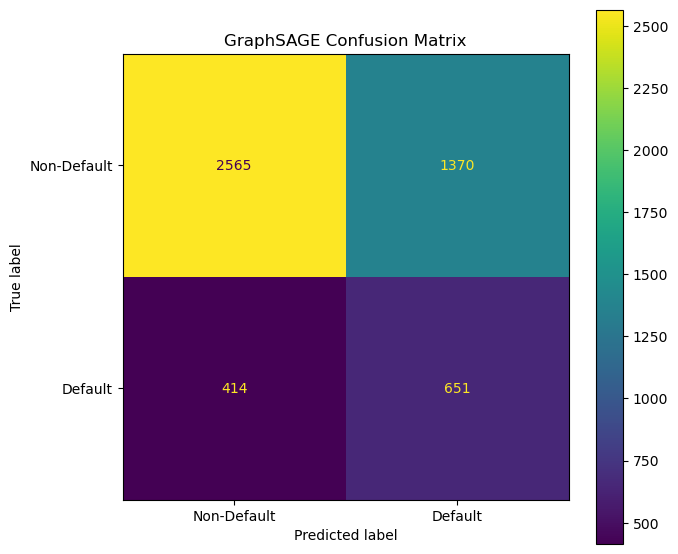

In [181]:
# GNN CELL 22: CONFUSION MATRIX VISUALIZATION

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_gnn,
    y_pred_gnn
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title("GraphSAGE Confusion Matrix")
plt.tight_layout()
plt.show()

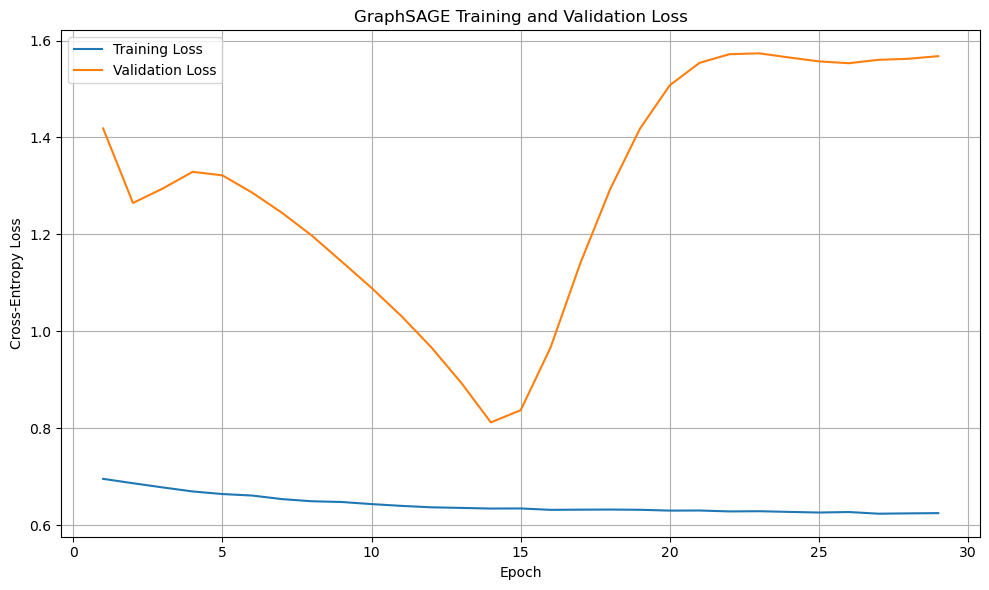

In [182]:
# GNN CELL 23: TRAINING AND VALIDATION LOSS CURVE

history_df = pd.DataFrame(training_history)

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("GraphSAGE Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

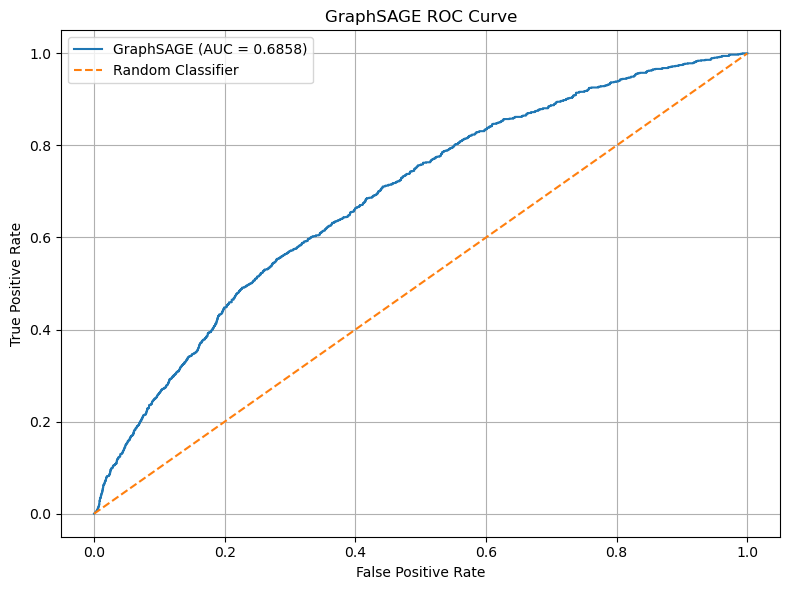

In [183]:
# GNN CELL 24: ROC CURVE

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test_gnn,
    y_prob_gnn
)

roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"GraphSAGE (AUC = {roc_auc_value:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GraphSAGE ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

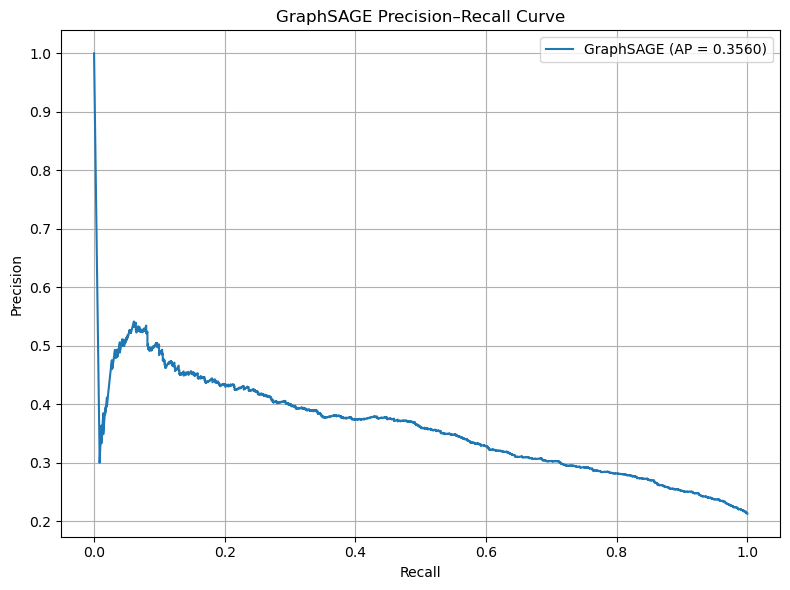

Average Precision: 0.356


In [184]:
# GNN CELL 25: PRECISION-RECALL CURVE

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test_gnn,
        y_prob_gnn
    )
)

average_precision = average_precision_score(
    y_test_gnn,
    y_prob_gnn
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"GraphSAGE (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("GraphSAGE Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Average Precision:", round(average_precision, 4))

In [185]:
# GNN CELL 26: VALIDATION PROBABILITIES

gnn_model.eval()

with torch.no_grad():
    validation_logits = gnn_model(
        gnn_data.x,
        gnn_data.edge_index
    )

    validation_probabilities = torch.softmax(
        validation_logits,
        dim=1
    )[:, 1]

y_val_gnn = gnn_data.y[
    gnn_data.val_mask
].cpu().numpy()

y_val_prob_gnn = validation_probabilities[
    gnn_data.val_mask
].cpu().numpy()

print("Validation samples:", len(y_val_gnn))
print("Validation probabilities:", len(y_val_prob_gnn))
print("✅ Validation probabilities generated")

Validation samples: 5000
Validation probabilities: 5000
✅ Validation probabilities generated


In [186]:
# GNN CELL 27: THRESHOLD ANALYSIS

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

thresholds_to_test = np.arange(
    0.10,
    0.91,
    0.05
)

for threshold in thresholds_to_test:

    y_val_pred_threshold = (
        y_val_prob_gnn >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_gnn,
        y_val_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val_gnn,
        y_val_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val_gnn,
        y_val_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,threshold,precision,recall,f1_score
0,0.10,0.2338,0.9983,0.3789
1,0.15,0.2385,0.9957,0.3848
2,0.20,0.2445,0.9820,0.3916
3,0.25,0.2566,0.9596,0.4049
4,0.30,0.2719,0.9227,0.4200
5,0.35,0.2902,0.8797,0.4364
6,0.40,0.3113,0.8119,0.4500
7,0.45,0.3331,0.7208,0.4556
8,0.50,0.3635,0.6478,0.4657
9,0.55,0.3879,0.5455,0.4534


In [187]:
# GNN CELL 28: BEST VALIDATION THRESHOLD

best_threshold_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

best_threshold = float(
    best_threshold_row["threshold"]
)

best_validation_f1 = float(
    best_threshold_row["f1_score"]
)

print("Best validation threshold:", best_threshold)
print(
    "Best validation F1 score:",
    round(best_validation_f1, 4)
)

print("\nSelected threshold criteria: Maximum validation F1")
print("✅ Threshold selected using validation data")

Best validation threshold: 0.5
Best validation F1 score: 0.4657

Selected threshold criteria: Maximum validation F1
✅ Threshold selected using validation data


In [188]:
# GNN CELL 29: THRESHOLD-BASED TEST EVALUATION

y_test_pred_threshold = (
    y_prob_gnn >= best_threshold
).astype(int)

threshold_test_precision = precision_score(
    y_test_gnn,
    y_test_pred_threshold,
    zero_division=0
)

threshold_test_recall = recall_score(
    y_test_gnn,
    y_test_pred_threshold,
    zero_division=0
)

threshold_test_f1 = f1_score(
    y_test_gnn,
    y_test_pred_threshold,
    zero_division=0
)

threshold_test_accuracy = accuracy_score(
    y_test_gnn,
    y_test_pred_threshold
)

threshold_test_cm = confusion_matrix(
    y_test_gnn,
    y_test_pred_threshold
)

print("===== THRESHOLD-BASED TEST RESULTS =====")
print("Selected threshold:", best_threshold)
print(f"Accuracy : {threshold_test_accuracy:.4f}")
print(f"Precision: {threshold_test_precision:.4f}")
print(f"Recall   : {threshold_test_recall:.4f}")
print(f"F1 Score : {threshold_test_f1:.4f}")

print("\nConfusion Matrix:")
print(threshold_test_cm)

print("\n✅ Final threshold-based evaluation completed")

===== THRESHOLD-BASED TEST RESULTS =====
Selected threshold: 0.5
Accuracy : 0.6432
Precision: 0.3221
Recall   : 0.6113
F1 Score : 0.4219

Confusion Matrix:
[[2565 1370]
 [ 414  651]]

✅ Final threshold-based evaluation completed


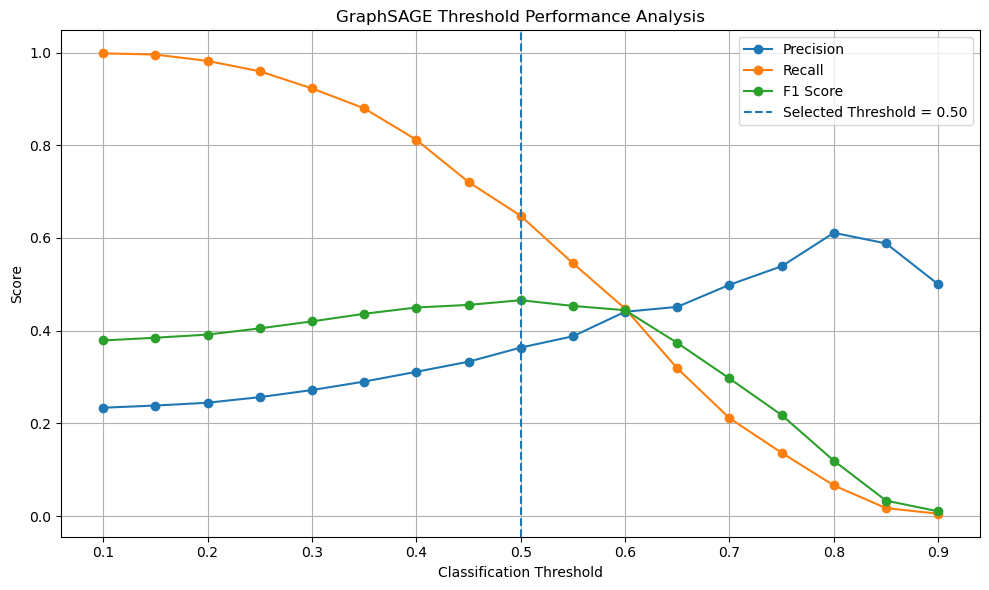

In [189]:
# GNN CELL 30: THRESHOLD PERFORMANCE CURVES

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1_score"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    x=best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("GraphSAGE Threshold Performance Analysis")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [190]:
# GNN CELL 31: FINAL GRAPHSAGE RESULTS SUMMARY

gnn_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Average Precision",
        "Selected Threshold",
        "Best Validation F1"
    ],
    "Value": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc,
        average_precision,
        best_threshold,
        best_validation_f1
    ]
})

display(gnn_results.round(4))

,Metric,Value
0,Accuracy,0.6432
1,Precision,0.3221
2,Recall,0.6113
3,F1 Score,0.4219
4,ROC-AUC,0.6858
5,Average Precision,0.3560
6,Selected Threshold,0.5000
7,Best Validation F1,0.4657


In [191]:
# GNN CELL 32: SAVE MODEL AND RESULTS

import os

os.makedirs("fintwinai_outputs", exist_ok=True)

# Save trained model
torch.save(
    {
        "model_state_dict": gnn_model.state_dict(),
        "input_features": gnn_data.num_node_features,
        "hidden_channels": 64,
        "num_layers": 3,
        "output_classes": 2,
        "best_threshold": best_threshold
    },
    "fintwinai_outputs/graphsage_model.pt"
)

# Save metrics
gnn_results.to_csv(
    "fintwinai_outputs/graphsage_results.csv",
    index=False
)

# Save threshold analysis
threshold_df.to_csv(
    "fintwinai_outputs/threshold_analysis.csv",
    index=False
)

print("✅ GraphSAGE model saved")
print("✅ Results saved")
print("✅ Threshold analysis saved")

✅ GraphSAGE model saved
✅ Results saved
✅ Threshold analysis saved


In [192]:
# GNN CELL 33: SAVE CONFUSION MATRIX

cm_df = pd.DataFrame(
    threshold_test_cm,
    index=["Actual Non-Default", "Actual Default"],
    columns=["Predicted Non-Default", "Predicted Default"]
)

cm_df.to_csv(
    "fintwinai_outputs/graphsage_confusion_matrix.csv"
)

print("✅ Confusion matrix saved")
print("\nSaved files:")

for filename in os.listdir("fintwinai_outputs"):
    print("-", filename)

✅ Confusion matrix saved

Saved files:
- graphsage_confusion_matrix.csv
- graphsage_model.pt
- graphsage_results.csv
- threshold_analysis.csv


In [193]:
# MLP CELL 1: PREPARE MLP DATA

mlp_x = gnn_data.x
mlp_y = gnn_data.y

mlp_train_mask = gnn_data.train_mask
mlp_val_mask = gnn_data.val_mask
mlp_test_mask = gnn_data.test_mask

print("Feature shape:", mlp_x.shape)
print("Label shape:", mlp_y.shape)
print("Training samples:", mlp_train_mask.sum().item())
print("Validation samples:", mlp_val_mask.sum().item())
print("Test samples:", mlp_test_mask.sum().item())

Feature shape: torch.Size([30000, 26])
Label shape: torch.Size([30000])
Training samples: 20000
Validation samples: 5000
Test samples: 5000


In [194]:
# MLP CELL 2: DEFINE MLP MODEL

class MLPBaseline(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        output_dim=2,
        dropout=0.3
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.network(x)


mlp_model = MLPBaseline(
    input_dim=mlp_x.shape[1],
    hidden_dim=64,
    output_dim=2,
    dropout=0.3
).to(device)

mlp_parameters = sum(
    parameter.numel()
    for parameter in mlp_model.parameters()
    if parameter.requires_grad
)

print("MLP architecture:")
print(mlp_model)
print("\nTrainable parameters:", mlp_parameters)
print("Device:", device)

MLP architecture:
MLPBaseline(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

Trainable parameters: 6018
Device: cpu


In [195]:
# MLP CELL 3: LOSS AND OPTIMIZER

mlp_class_counts = torch.bincount(
    mlp_y[mlp_train_mask],
    minlength=2
).float()

mlp_class_weights = (
    mlp_class_counts.sum()
    / (2 * mlp_class_counts)
).to(device)

mlp_criterion = nn.CrossEntropyLoss(
    weight=mlp_class_weights
)

mlp_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

mlp_num_epochs = 100
mlp_patience = 15

print("Class counts:", mlp_class_counts.tolist())
print("Class weights:", mlp_class_weights.tolist())
print("Learning rate:", 0.001)
print("Maximum epochs:", mlp_num_epochs)
print("Early stopping patience:", mlp_patience)
print("✅ MLP configuration ready")

Class counts: [16315.0, 3685.0]
Class weights: [0.6129328608512878, 2.7137041091918945]
Learning rate: 0.001
Maximum epochs: 100
Early stopping patience: 15
✅ MLP configuration ready


In [196]:
# MLP CELL 4: MODEL TRAINING

import copy

mlp_best_val_loss = float("inf")
mlp_patience_counter = 0
mlp_training_history = []
mlp_best_model_state = None

for epoch in range(1, mlp_num_epochs + 1):

    # Training
    mlp_model.train()
    mlp_optimizer.zero_grad()

    mlp_logits = mlp_model(
        mlp_x[mlp_train_mask]
    )

    mlp_train_loss = mlp_criterion(
        mlp_logits,
        mlp_y[mlp_train_mask]
    )

    mlp_train_loss.backward()
    mlp_optimizer.step()

    # Validation
    mlp_model.eval()

    with torch.no_grad():

        mlp_val_logits = mlp_model(
            mlp_x[mlp_val_mask]
        )

        mlp_val_loss = mlp_criterion(
            mlp_val_logits,
            mlp_y[mlp_val_mask]
        )

    train_loss_value = mlp_train_loss.item()
    val_loss_value = mlp_val_loss.item()

    mlp_training_history.append({
        "epoch": epoch,
        "train_loss": train_loss_value,
        "val_loss": val_loss_value
    })

    # Save best model
    if val_loss_value < mlp_best_val_loss:

        mlp_best_val_loss = val_loss_value
        mlp_patience_counter = 0

        mlp_best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )

    else:
        mlp_patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss_value:.4f} | "
            f"Val Loss: {val_loss_value:.4f}"
        )

    if mlp_patience_counter >= mlp_patience:

        print(f"\nEarly stopping at epoch {epoch}")
        break

# Restore best model
if mlp_best_model_state is not None:
    mlp_model.load_state_dict(mlp_best_model_state)

print("\n✅ MLP training completed")
print(
    "Best validation loss:",
    round(mlp_best_val_loss, 4)
)
print(
    "Total epochs completed:",
    len(mlp_training_history)
)

Epoch 001 | Train Loss: 0.7013 | Val Loss: 1.8240
Epoch 010 | Train Loss: 0.6658 | Val Loss: 3.6737

Early stopping at epoch 16

✅ MLP training completed
Best validation loss: 1.824
Total epochs completed: 16


In [197]:
# MLP CELL 5: TEST SET EVALUATION

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

mlp_model.eval()

with torch.no_grad():

    mlp_test_logits = mlp_model(
        mlp_x[mlp_test_mask]
    )

    mlp_test_probabilities = torch.softmax(
        mlp_test_logits,
        dim=1
    )[:, 1]

    mlp_test_predictions = torch.argmax(
        mlp_test_logits,
        dim=1
    )

# Convert to NumPy
y_test_mlp = mlp_y[mlp_test_mask].cpu().numpy()

y_pred_mlp = (
    mlp_test_predictions.cpu().numpy()
)

y_prob_mlp = (
    mlp_test_probabilities.cpu().numpy()
)

# Metrics
mlp_accuracy = accuracy_score(
    y_test_mlp,
    y_pred_mlp
)

mlp_precision = precision_score(
    y_test_mlp,
    y_pred_mlp,
    zero_division=0
)

mlp_recall = recall_score(
    y_test_mlp,
    y_pred_mlp,
    zero_division=0
)

mlp_f1 = f1_score(
    y_test_mlp,
    y_pred_mlp,
    zero_division=0
)

mlp_auc = roc_auc_score(
    y_test_mlp,
    y_prob_mlp
)

mlp_average_precision = average_precision_score(
    y_test_mlp,
    y_prob_mlp
)

print("========== MLP TEST RESULTS ==========")
print(f"Accuracy : {mlp_accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall   : {mlp_recall:.4f}")
print(f"F1 Score : {mlp_f1:.4f}")
print(f"ROC-AUC  : {mlp_auc:.4f}")
print(f"Average Precision: {mlp_average_precision:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_mlp,
        y_pred_mlp,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test_mlp,
        y_pred_mlp
    )
)

print("\n✅ MLP test evaluation completed")

========== MLP TEST RESULTS ==========
Accuracy : 0.7430
Precision: 0.2430
Recall   : 0.0977
F1 Score : 0.1393
ROC-AUC  : 0.5533
Average Precision: 0.2417

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85      3935
           1       0.24      0.10      0.14      1065

    accuracy                           0.74      5000
   macro avg       0.52      0.51      0.49      5000
weighted avg       0.67      0.74      0.70      5000

Confusion Matrix:
[[3611  324]
 [ 961  104]]

✅ MLP test evaluation completed


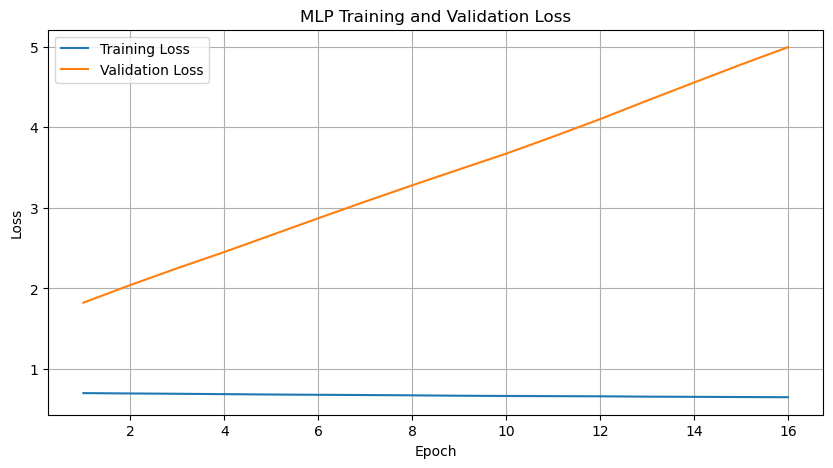

In [198]:
import matplotlib.pyplot as plt
import pandas as pd

mlp_history_df = pd.DataFrame(mlp_training_history)

plt.figure(figsize=(10, 5))

plt.plot(
    mlp_history_df["epoch"],
    mlp_history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    mlp_history_df["epoch"],
    mlp_history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

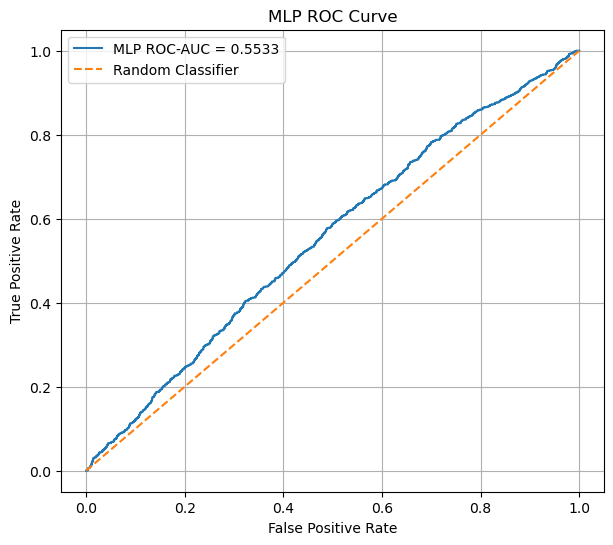

In [199]:
from sklearn.metrics import roc_curve, roc_auc_score

mlp_fpr, mlp_tpr, mlp_thresholds = roc_curve(
    y_test_mlp,
    y_prob_mlp
)

mlp_roc_auc = roc_auc_score(
    y_test_mlp,
    y_prob_mlp
)

plt.figure(figsize=(7, 6))

plt.plot(
    mlp_fpr,
    mlp_tpr,
    label=f"MLP ROC-AUC = {mlp_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

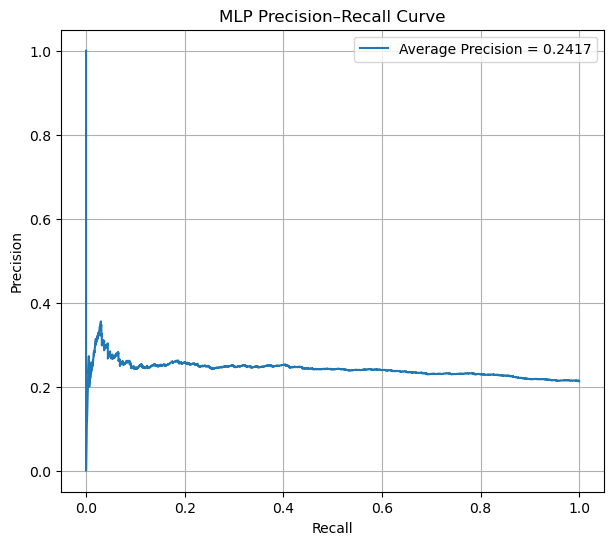

In [200]:
from sklearn.metrics import precision_recall_curve, average_precision_score

mlp_precision_curve, mlp_recall_curve, mlp_pr_thresholds = (
    precision_recall_curve(
        y_test_mlp,
        y_prob_mlp
    )
)

mlp_ap = average_precision_score(
    y_test_mlp,
    y_prob_mlp
)

plt.figure(figsize=(7, 6))

plt.plot(
    mlp_recall_curve,
    mlp_precision_curve,
    label=f"Average Precision = {mlp_ap:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("MLP Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [201]:
import pandas as pd

comparison_results = pd.DataFrame({
    "Model": ["MLP", "GraphSAGE"],
    "Accuracy": [0.7430, 0.6432],
    "Precision": [0.2430, 0.3221],
    "Recall": [0.0977, 0.6113],
    "F1 Score": [0.1393, 0.4219],
    "ROC-AUC": [0.5533, 0.6858],
    "Average Precision": [0.2417, 0.3560]
})

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,MLP,0.7430,0.2430,0.0977,0.1393,0.5533,0.2417
1,GraphSAGE,0.6432,0.3221,0.6113,0.4219,0.6858,0.3560


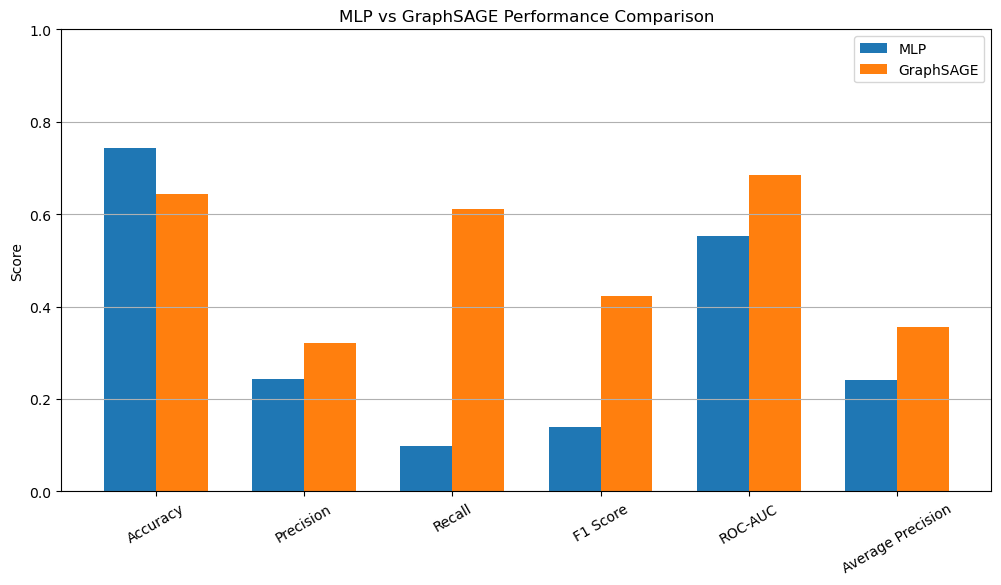

In [202]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Average Precision"
]

x = np.arange(len(metrics))
width = 0.35

mlp_values = comparison_results.iloc[0][metrics].values.astype(float)
graphsage_values = comparison_results.iloc[1][metrics].values.astype(float)

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    mlp_values,
    width,
    label="MLP"
)

plt.bar(
    x + width / 2,
    graphsage_values,
    width,
    label="GraphSAGE"
)

plt.xticks(x, metrics, rotation=30)
plt.ylabel("Score")
plt.title("MLP vs GraphSAGE Performance Comparison")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")

plt.show()

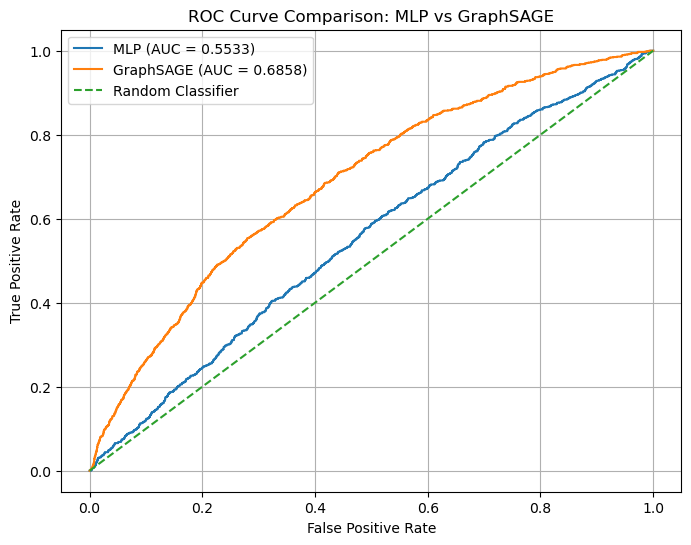

In [212]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# MLP ROC curve
mlp_fpr, mlp_tpr, _ = roc_curve(
    y_test_mlp,
    y_prob_mlp
)

# GraphSAGE ROC curve
graphsage_fpr, graphsage_tpr, _ = roc_curve(
    y_test_gnn,
    y_prob_gnn
)

plt.figure(figsize=(8, 6))

plt.plot(
    mlp_fpr,
    mlp_tpr,
    label=f"MLP (AUC = {mlp_auc:.4f})"
)

plt.plot(
    graphsage_fpr,
    graphsage_tpr,
    label=f"GraphSAGE (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: MLP vs GraphSAGE")
plt.legend()
plt.grid(True)

plt.show()

In [213]:
comparison_results.to_csv(
    "fintwinai_outputs/model_comparison.csv",
    index=False
)

print("✅ Model comparison saved successfully")

✅ Model comparison saved successfully


In [214]:
print("MLP probability shape:", y_prob_mlp.shape)
print("GraphSAGE probability shape:", y_prob_gnn.shape)

print("MLP labels shape:", y_test_mlp.shape)
print("GraphSAGE labels shape:", y_test_gnn.shape)

MLP probability shape: (5000,)
GraphSAGE probability shape: (5000,)
MLP labels shape: (5000,)
GraphSAGE labels shape: (5000,)


In [215]:
import torch
import numpy as np
import pandas as pd

# ---------- MLP Validation Probabilities ----------
mlp_model.eval()

with torch.no_grad():
    mlp_val_logits_current = mlp_model(
        mlp_x[mlp_val_mask]
    )

mlp_val_prob_current = torch.softmax(
    mlp_val_logits_current,
    dim=1
)[:, 1].cpu().numpy()

y_val_mlp_current = mlp_y[
    mlp_val_mask
].cpu().numpy()


# ---------- GraphSAGE Validation Probabilities ----------
gnn_model.eval()

with torch.no_grad():
    gnn_val_logits_current = gnn_model(
        gnn_data.x,
        gnn_data.edge_index
    )[gnn_validation_mask]

gnn_val_prob_current = torch.softmax(
    gnn_val_logits_current,
    dim=1
)[:, 1].cpu().numpy()

y_val_gnn_current = gnn_data.y[
    gnn_validation_mask
].cpu().numpy()

print("MLP validation samples:", len(y_val_mlp_current))
print("GraphSAGE validation samples:", len(y_val_gnn_current))

MLP validation samples: 5000
GraphSAGE validation samples: 5000


In [216]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds_to_test = np.arange(0.10, 0.91, 0.05)

threshold_rows = []

for threshold in thresholds_to_test:

    # MLP predictions
    mlp_predictions_threshold = (
        mlp_val_prob_current >= threshold
    ).astype(int)

    # GraphSAGE predictions
    gnn_predictions_threshold = (
        gnn_val_prob_current >= threshold
    ).astype(int)

    threshold_rows.append({
        "Threshold": round(threshold, 2),

        "MLP_Accuracy": accuracy_score(
            y_val_mlp_current,
            mlp_predictions_threshold
        ),

        "MLP_Precision": precision_score(
            y_val_mlp_current,
            mlp_predictions_threshold,
            zero_division=0
        ),

        "MLP_Recall": recall_score(
            y_val_mlp_current,
            mlp_predictions_threshold,
            zero_division=0
        ),

        "MLP_F1": f1_score(
            y_val_mlp_current,
            mlp_predictions_threshold,
            zero_division=0
        ),

        "GraphSAGE_Accuracy": accuracy_score(
            y_val_gnn_current,
            gnn_predictions_threshold
        ),

        "GraphSAGE_Precision": precision_score(
            y_val_gnn_current,
            gnn_predictions_threshold,
            zero_division=0
        ),

        "GraphSAGE_Recall": recall_score(
            y_val_gnn_current,
            gnn_predictions_threshold,
            zero_division=0
        ),

        "GraphSAGE_F1": f1_score(
            y_val_gnn_current,
            gnn_predictions_threshold,
            zero_division=0
        )
    })

threshold_analysis_df = pd.DataFrame(threshold_rows)

threshold_analysis_df

,Threshold,MLP_Accuracy,MLP_Precision,MLP_Recall,MLP_F1,GraphSAGE_Accuracy,GraphSAGE_Precision,GraphSAGE_Recall,GraphSAGE_F1
0,0.10,0.2328,0.232800,1.000000,0.377677,0.2380,0.233803,0.998282,0.378872
1,0.15,0.2328,0.232800,1.000000,0.377677,0.2588,0.238477,0.995704,0.384794
2,0.20,0.2328,0.232800,1.000000,0.377677,0.2896,0.244544,0.981959,0.391572
3,0.25,0.2328,0.232800,1.000000,0.377677,0.3434,0.256605,0.959622,0.404930
4,0.30,0.2328,0.232800,1.000000,0.377677,0.4068,0.271899,0.922680,0.420023
5,0.35,0.2330,0.232633,0.998282,0.377334,0.4710,0.290167,0.879725,0.436395
6,0.40,0.2434,0.233354,0.984536,0.377284,0.5380,0.311265,0.811856,0.450000
7,0.45,0.4770,0.254484,0.646048,0.365137,0.5990,0.333069,0.720790,0.455607
8,0.50,0.7396,0.270000,0.069588,0.110656,0.6540,0.363549,0.647766,0.465720
9,0.55,0.7668,0.416667,0.004296,0.008503,0.6938,0.387905,0.545533,0.453409


In [217]:
# Best MLP threshold
best_mlp_row = threshold_analysis_df.loc[
    threshold_analysis_df["MLP_F1"].idxmax()
]

# Best GraphSAGE threshold
best_gnn_row = threshold_analysis_df.loc[
    threshold_analysis_df["GraphSAGE_F1"].idxmax()
]

best_mlp_threshold = best_mlp_row["Threshold"]
best_gnn_threshold = best_gnn_row["Threshold"]

print("========== BEST THRESHOLDS ==========")

print(
    f"MLP threshold: {best_mlp_threshold:.2f}"
)

print(
    f"MLP validation F1: {best_mlp_row['MLP_F1']:.4f}"
)

print(
    f"GraphSAGE threshold: {best_gnn_threshold:.2f}"
)

print(
    f"GraphSAGE validation F1: "
    f"{best_gnn_row['GraphSAGE_F1']:.4f}"
)

========== BEST THRESHOLDS ==========
MLP threshold: 0.10
MLP validation F1: 0.3777
GraphSAGE threshold: 0.50
GraphSAGE validation F1: 0.4657


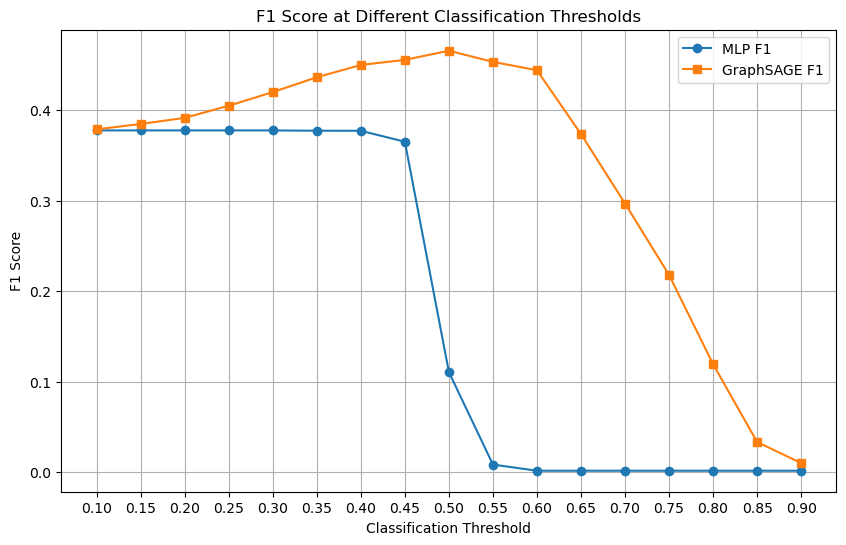

In [218]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_analysis_df["Threshold"],
    threshold_analysis_df["MLP_F1"],
    marker="o",
    label="MLP F1"
)

plt.plot(
    threshold_analysis_df["Threshold"],
    threshold_analysis_df["GraphSAGE_F1"],
    marker="s",
    label="GraphSAGE F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score at Different Classification Thresholds")
plt.xticks(thresholds_to_test)
plt.legend()
plt.grid(True)

plt.show()

In [219]:
from sklearn.metrics import classification_report, confusion_matrix

# ---------- MLP Test at Optimal Threshold ----------
mlp_test_predictions_optimal = (
    y_prob_mlp >= best_mlp_threshold
).astype(int)

print("========== MLP OPTIMAL THRESHOLD RESULTS ==========")

print(
    classification_report(
        y_test_mlp,
        mlp_test_predictions_optimal,
        zero_division=0
    )
)

print("MLP Confusion Matrix:")
print(
    confusion_matrix(
        y_test_mlp,
        mlp_test_predictions_optimal
    )
)


# ---------- GraphSAGE Test at Optimal Threshold ----------
gnn_test_predictions_optimal = (
    y_prob_gnn >= best_gnn_threshold
).astype(int)

print("\n========== GRAPHSAGE OPTIMAL THRESHOLD RESULTS ==========")

print(
    classification_report(
        y_test_gnn,
        gnn_test_predictions_optimal,
        zero_division=0
    )
)

print("GraphSAGE Confusion Matrix:")
print(
    confusion_matrix(
        y_test_gnn,
        gnn_test_predictions_optimal
    )
)

========== MLP OPTIMAL THRESHOLD RESULTS ==========
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3935
           1       0.21      1.00      0.35      1065

    accuracy                           0.21      5000
   macro avg       0.11      0.50      0.18      5000
weighted avg       0.05      0.21      0.07      5000

MLP Confusion Matrix:
[[   0 3935]
 [   0 1065]]

========== GRAPHSAGE OPTIMAL THRESHOLD RESULTS ==========
              precision    recall  f1-score   support

           0       0.86      0.65      0.74      3935
           1       0.32      0.61      0.42      1065

    accuracy                           0.64      5000
   macro avg       0.59      0.63      0.58      5000
weighted avg       0.75      0.64      0.67      5000

GraphSAGE Confusion Matrix:
[[2565 1370]
 [ 414  651]]


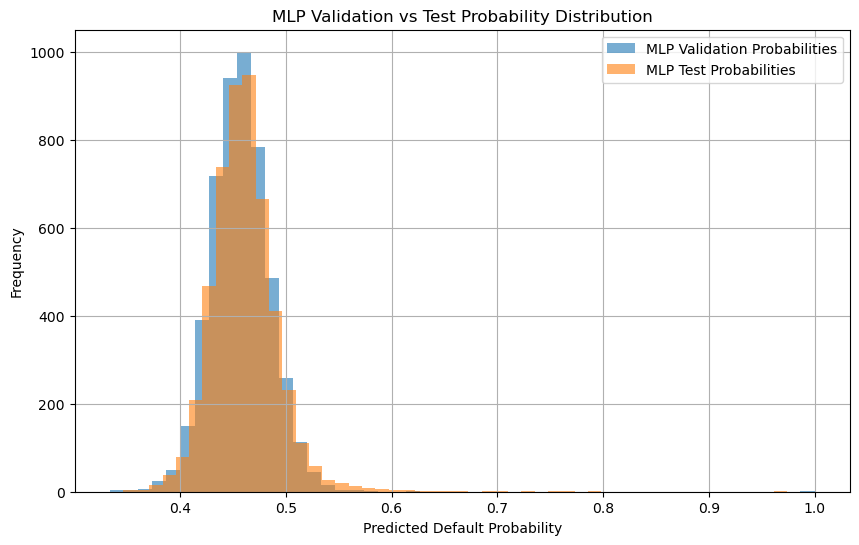

In [220]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    mlp_val_prob_current,
    bins=50,
    alpha=0.6,
    label="MLP Validation Probabilities"
)

plt.hist(
    y_prob_mlp,
    bins=50,
    alpha=0.6,
    label="MLP Test Probabilities"
)

plt.xlabel("Predicted Default Probability")
plt.ylabel("Frequency")
plt.title("MLP Validation vs Test Probability Distribution")
plt.legend()
plt.grid(True)

plt.show()

In [221]:
probability_summary = pd.DataFrame({
    "Dataset": ["MLP Validation", "MLP Test"],
    "Minimum": [
        mlp_val_prob_current.min(),
        y_prob_mlp.min()
    ],
    "25th Percentile": [
        np.percentile(mlp_val_prob_current, 25),
        np.percentile(y_prob_mlp, 25)
    ],
    "Median": [
        np.median(mlp_val_prob_current),
        np.median(y_prob_mlp)
    ],
    "75th Percentile": [
        np.percentile(mlp_val_prob_current, 75),
        np.percentile(y_prob_mlp, 75)
    ],
    "Maximum": [
        mlp_val_prob_current.max(),
        y_prob_mlp.max()
    ]
})

probability_summary

,Dataset,Minimum,25th Percentile,Median,75th Percentile,Maximum
0,MLP Validation,0.333615,0.438740,0.456282,0.474032,1.000000
1,MLP Test,0.345658,0.441475,0.459108,0.476669,0.974261


In [222]:
threshold_diagnostics = []

for threshold in thresholds_to_test:

    predictions = (
        mlp_val_prob_current >= threshold
    ).astype(int)

    positive_rate = predictions.mean()

    threshold_diagnostics.append({
        "Threshold": threshold,
        "F1": f1_score(
            y_val_mlp_current,
            predictions,
            zero_division=0
        ),
        "Precision": precision_score(
            y_val_mlp_current,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val_mlp_current,
            predictions,
            zero_division=0
        ),
        "Positive_Prediction_Rate": positive_rate
    })

mlp_threshold_diagnostics = pd.DataFrame(
    threshold_diagnostics
)

mlp_threshold_diagnostics

,Threshold,F1,Precision,Recall,Positive_Prediction_Rate
0,0.10,0.377677,0.232800,1.000000,1.0000
1,0.15,0.377677,0.232800,1.000000,1.0000
2,0.20,0.377677,0.232800,1.000000,1.0000
3,0.25,0.377677,0.232800,1.000000,1.0000
4,0.30,0.377677,0.232800,1.000000,1.0000
5,0.35,0.377334,0.232633,0.998282,0.9990
6,0.40,0.377284,0.233354,0.984536,0.9822
7,0.45,0.365137,0.254484,0.646048,0.5910
8,0.50,0.110656,0.270000,0.069588,0.0600
9,0.55,0.008503,0.416667,0.004296,0.0024


In [223]:
balanced_mlp_thresholds = mlp_threshold_diagnostics[
    (
        mlp_threshold_diagnostics[
            "Positive_Prediction_Rate"
        ] < 0.90
    )
    &
    (
        mlp_threshold_diagnostics[
            "Positive_Prediction_Rate"
        ] > 0.05
    )
].sort_values(
    by="F1",
    ascending=False
)

balanced_mlp_thresholds

,Threshold,F1,Precision,Recall,Positive_Prediction_Rate
7,0.45,0.365137,0.254484,0.646048,0.591
8,0.50,0.110656,0.270000,0.069588,0.060


In [224]:
mlp_threshold_diagnostics.to_csv(
    "fintwinai_outputs/mlp_threshold_diagnostics.csv",
    index=False
)

print("✅ MLP threshold diagnostics saved")

✅ MLP threshold diagnostics saved


In [225]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score
)
import numpy as np

print("✅ Calibration libraries loaded")

✅ Calibration libraries loaded


In [226]:
def clip_probabilities(probabilities):
    return np.clip(
        probabilities,
        1e-6,
        1 - 1e-6
    )


def probability_to_logit(probabilities):
    probabilities = clip_probabilities(probabilities)

    return np.log(
        probabilities / (1 - probabilities)
    )


print("✅ Calibration functions defined")

✅ Calibration functions defined


In [227]:
# Convert validation probabilities into log-odds
mlp_val_logits_for_calibration = probability_to_logit(
    mlp_val_prob_current
)

gnn_val_logits_for_calibration = probability_to_logit(
    gnn_val_prob_current
)

# Fit MLP calibration model
mlp_calibrator = LogisticRegression()
mlp_calibrator.fit(
    mlp_val_logits_for_calibration.reshape(-1, 1),
    y_val_mlp_current
)

# Fit GraphSAGE calibration model
gnn_calibrator = LogisticRegression()
gnn_calibrator.fit(
    gnn_val_logits_for_calibration.reshape(-1, 1),
    y_val_gnn_current
)

print("✅ MLP and GraphSAGE calibration models fitted")

✅ MLP and GraphSAGE calibration models fitted


In [230]:
# MLP calibrated test probabilities
mlp_test_logits_for_calibration = probability_to_logit(
    y_prob_mlp
)

mlp_test_prob_calibrated = mlp_calibrator.predict_proba(
    mlp_test_logits_for_calibration.reshape(-1, 1)
)[:, 1]


# GraphSAGE calibrated test probabilities
gnn_test_logits_for_calibration = probability_to_logit(
    y_prob_gnn
)

gnn_test_prob_calibrated = gnn_calibrator.predict_proba(
    gnn_test_logits_for_calibration.reshape(-1, 1)
)[:, 1]

print("MLP calibrated probabilities:", mlp_test_prob_calibrated.shape)
print(
    "GraphSAGE calibrated probabilities:",
    gnn_test_prob_calibrated.shape
)

MLP calibrated probabilities: (5000,)
GraphSAGE calibrated probabilities: (5000,)


In [231]:
mlp_brier_before = brier_score_loss(
    y_test_mlp,
    y_prob_mlp
)

mlp_brier_after = brier_score_loss(
    y_test_mlp,
    mlp_test_prob_calibrated
)

gnn_brier_before = brier_score_loss(
    y_test_gnn,
    y_prob_gnn
)

gnn_brier_after = brier_score_loss(
    y_test_gnn,
    gnn_test_prob_calibrated
)

calibration_comparison_df = pd.DataFrame({
    "Model": ["MLP", "MLP", "GraphSAGE", "GraphSAGE"],
    "Stage": [
        "Before Calibration",
        "After Calibration",
        "Before Calibration",
        "After Calibration"
    ],
    "Brier Score": [
        mlp_brier_before,
        mlp_brier_after,
        gnn_brier_before,
        gnn_brier_after
    ]
})

calibration_comparison_df

,Model,Stage,Brier Score
0,MLP,Before Calibration,0.228459
1,MLP,After Calibration,0.167802
2,GraphSAGE,Before Calibration,0.222188
3,GraphSAGE,After Calibration,0.158626


In [232]:
from sklearn.calibration import calibration_curve

# MLP
mlp_true_before, mlp_pred_before = calibration_curve(
    y_test_mlp,
    y_prob_mlp,
    n_bins=10,
    strategy="uniform"
)

mlp_true_after, mlp_pred_after = calibration_curve(
    y_test_mlp,
    mlp_test_prob_calibrated,
    n_bins=10,
    strategy="uniform"
)

# GraphSAGE
gnn_true_before, gnn_pred_before = calibration_curve(
    y_test_gnn,
    y_prob_gnn,
    n_bins=10,
    strategy="uniform"
)

gnn_true_after, gnn_pred_after = calibration_curve(
    y_test_gnn,
    gnn_test_prob_calibrated,
    n_bins=10,
    strategy="uniform"
)

print("✅ Reliability curves calculated")

✅ Reliability curves calculated


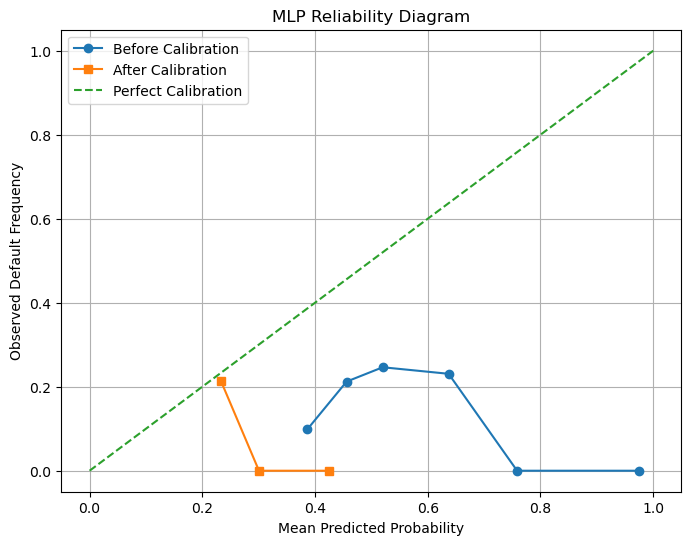

In [233]:
plt.figure(figsize=(8, 6))

plt.plot(
    mlp_pred_before,
    mlp_true_before,
    marker="o",
    label="Before Calibration"
)

plt.plot(
    mlp_pred_after,
    mlp_true_after,
    marker="s",
    label="After Calibration"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Frequency")
plt.title("MLP Reliability Diagram")
plt.legend()
plt.grid(True)

plt.show()

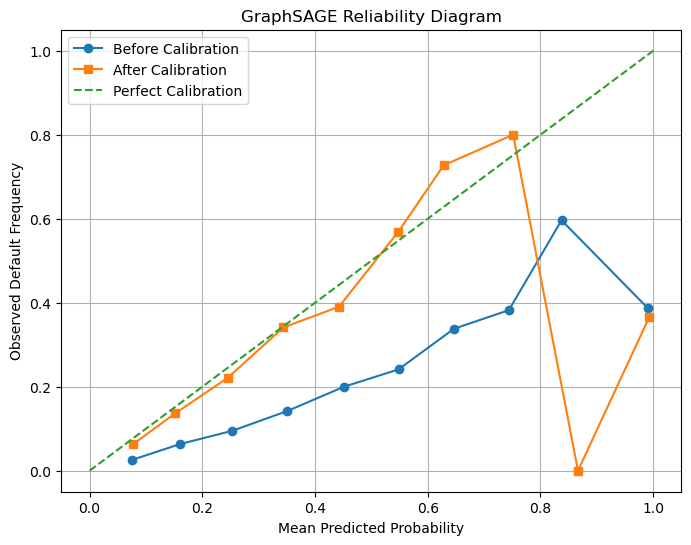

In [234]:
plt.figure(figsize=(8, 6))

plt.plot(
    gnn_pred_before,
    gnn_true_before,
    marker="o",
    label="Before Calibration"
)

plt.plot(
    gnn_pred_after,
    gnn_true_after,
    marker="s",
    label="After Calibration"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Frequency")
plt.title("GraphSAGE Reliability Diagram")
plt.legend()
plt.grid(True)

plt.show()

In [236]:
calibrated_probability_summary = pd.DataFrame({
    "Model": ["MLP", "GraphSAGE"],
    "Mean Probability Before": [
        y_prob_mlp.mean(),
        y_prob_gnn.mean()
    ],
    "Mean Probability After": [
        mlp_test_prob_calibrated.mean(),
        gnn_test_prob_calibrated.mean()
    ],
    "Minimum After": [
        mlp_test_prob_calibrated.min(),
        gnn_test_prob_calibrated.min()
    ],
    "Maximum After": [
        mlp_test_prob_calibrated.max(),
        gnn_test_prob_calibrated.max()
    ]
})

calibrated_probability_summary

,Model,Mean Probability Before,Mean Probability After,Minimum After,Maximum After
0,MLP,0.460951,0.233277,0.213692,0.424633
1,GraphSAGE,0.459291,0.235449,0.000003,0.999967


In [237]:
calibration_comparison_df.to_csv(
    "fintwinai_outputs/calibration_comparison.csv",
    index=False
)

calibrated_probability_summary.to_csv(
    "fintwinai_outputs/calibrated_probability_summary.csv",
    index=False
)

print("✅ Calibration results saved successfully")

✅ Calibration results saved successfully


In [238]:
survival_keywords = [
    "issue",
    "date",
    "term",
    "payment",
    "last",
    "status",
    "default"
]

survival_columns = [
    column
    for column in model_data.columns
    if any(
        keyword in column.lower()
        for keyword in survival_keywords
    )
]

print("Survival-related columns:")
print(survival_columns)

Survival-related columns:
['term_months', 'verification_status', 'inq_last_6mths', 'default', 'issue_date', 'issue_year']


In [239]:
model_data[
    survival_columns
].dtypes

term_months                     Int64
verification_status            object
inq_last_6mths                float64
default                          int8
issue_date             datetime64[ns]
issue_year                      int32
dtype: object

In [240]:
model_data[
    survival_columns
].head(10)

,term_months,verification_status,inq_last_6mths,default,issue_date,issue_year
0,36,Not Verified,1.0,0,2015-12-01,2015
1,36,Not Verified,4.0,0,2015-12-01,2015
2,60,Not Verified,0.0,0,2015-12-01,2015
3,60,Source Verified,3.0,0,2015-12-01,2015
4,36,Source Verified,0.0,0,2015-12-01,2015
5,36,Not Verified,0.0,0,2015-12-01,2015
6,36,Not Verified,0.0,0,2015-12-01,2015
7,36,Not Verified,1.0,0,2015-12-01,2015
8,36,Not Verified,0.0,0,2015-12-01,2015
9,36,Not Verified,0.0,0,2015-12-01,2015


In [241]:
survival_missing_summary = pd.DataFrame({
    "Column": survival_columns,
    "Missing Values": [
        model_data[column].isna().sum()
        for column in survival_columns
    ],
    "Missing Percentage": [
        model_data[column].isna().mean() * 100
        for column in survival_columns
    ]
})

survival_missing_summary

,Column,Missing Values,Missing Percentage
0,term_months,0,0.000000
1,verification_status,0,0.000000
2,inq_last_6mths,1,0.000074
3,default,0,0.000000
4,issue_date,0,0.000000
5,issue_year,0,0.000000


In [242]:
print("Default distribution:")

print(
    model_data["default"].value_counts(
        dropna=False
    )
)

print("\nDefault proportions:")

print(
    model_data["default"].value_counts(
        normalize=True,
        dropna=False
    )
)

Default distribution:
default
0    1076751
1     268599
Name: count, dtype: int64

Default proportions:
default
0    0.80035
1    0.19965
Name: proportion, dtype: float64


In [244]:
survival_df = model_data[
    [
        "term_months",
        "default",
        "issue_year",
        "inq_last_6mths"
    ]
].copy()

# Handle missing values
survival_df["inq_last_6mths"] = (
    survival_df["inq_last_6mths"]
    .fillna(survival_df["inq_last_6mths"].median())
)

# Ensure duration is positive
survival_df["duration"] = (
    survival_df["term_months"]
    .clip(lower=1)
)

# Event indicator
survival_df["event"] = (
    survival_df["default"]
    .astype(int)
)

survival_df.head()

,term_months,default,issue_year,inq_last_6mths,duration,event
0,36,0,2015,1.0,36,0
1,36,0,2015,4.0,36,0
2,60,0,2015,0.0,60,0
3,60,0,2015,3.0,60,0
4,36,0,2015,0.0,36,0


In [245]:
cox_df = survival_df[
    [
        "duration",
        "event",
        "issue_year",
        "inq_last_6mths"
    ]
].dropna()

print("Cox dataset shape:", cox_df.shape)
print("\nEvent distribution:")
print(cox_df["event"].value_counts())

Cox dataset shape: (1345350, 4)

Event distribution:
event
0    1076751
1     268599
Name: count, dtype: int64


In [246]:
pip install lifelines

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [247]:
from lifelines import CoxPHFitter

print("✅ Lifelines imported successfully")

✅ Lifelines imported successfully


In [248]:
cox_model = CoxPHFitter()

cox_model.fit(
    cox_df,
    duration_col="duration",
    event_col="event"
)

cox_model.print_summary()

<lifelines.CoxPHFitter: fitted with 1.34535e+06 total observations, 1.07675e+06 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1.34535e+06
number of events observed = 268599
   partial log-likelihood = -3606636.65
         time fit was run = 2026-09-20 19:19:31 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
issue_year      0.08      1.09      0.00            0.08            0.09                1.08                1.09
inq_last_6mths  0.14      1.15      0.00            0.13            0.14                1.14                1.15

                cmp to     z      p  -log2(p)
covariate                                    
issue_year        0.00 68.69 <0.005       inf
inq_last_6mths    0.00 73.60 <0.005       inf
---
Concordance = 0.57
Partial AIC = 7213277.29
log-likelihood ratio test = 8953.78 on 2 df
-log2(p) of ll-ratio test = inf

In [249]:
cox_summary = cox_model.summary[
    [
        "coef",
        "exp(coef)",
        "p",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%"
    ]
]

cox_summary

,coef,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,,,
issue_year,0.083603,1.087197,0.0,1.084607,1.089793
inq_last_6mths,0.137370,1.147253,0.0,1.143064,1.151458


In [251]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

In [252]:
survival_df = model_data[
    ["term_months", "default"]
].dropna().copy()

survival_df["duration"] = survival_df["term_months"]
survival_df["event"] = survival_df["default"].astype(int)

survival_df.head()

,term_months,default,duration,event
0,36,0,36,0
1,36,0,36,0
2,60,0,60,0
3,60,0,60,0
4,36,0,36,0


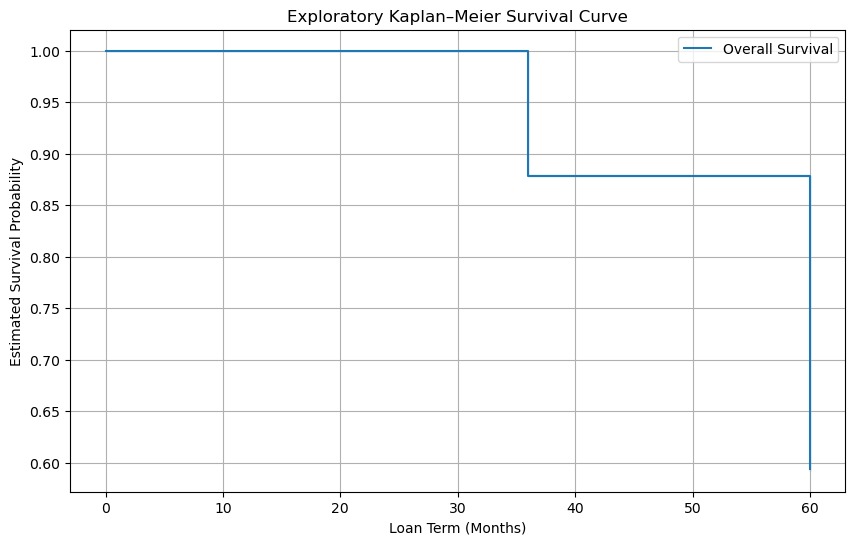

In [253]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df["duration"],
    event_observed=survival_df["event"],
    label="Overall Survival"
)

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()

plt.title("Exploratory Kaplan–Meier Survival Curve")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Estimated Survival Probability")
plt.grid(True)
plt.show()

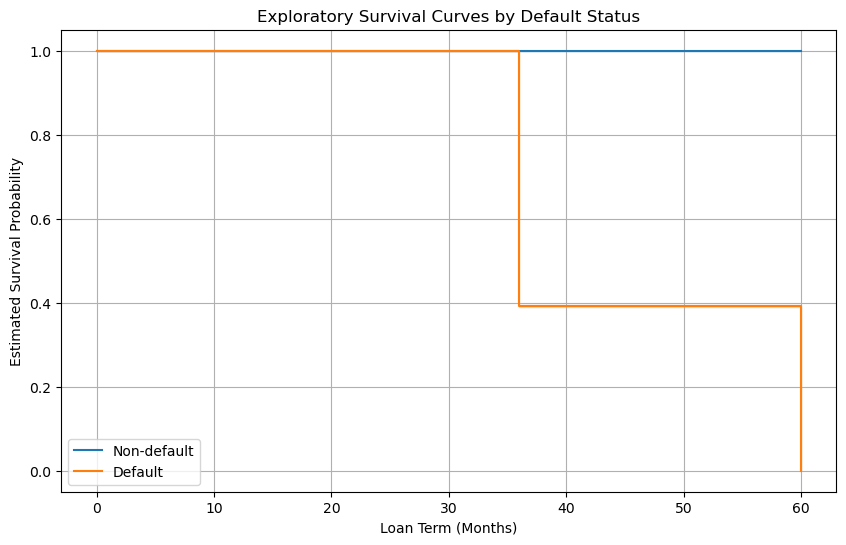

In [254]:
plt.figure(figsize=(10, 6))

for default_status, label in [(0, "Non-default"), (1, "Default")]:
    group = survival_df[survival_df["event"] == default_status]

    kmf_group = KaplanMeierFitter()
    kmf_group.fit(
        durations=group["duration"],
        event_observed=group["event"],
        label=label
    )

    kmf_group.plot_survival_function()

plt.title("Exploratory Survival Curves by Default Status")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Estimated Survival Probability")
plt.grid(True)
plt.show()

In [255]:
print("Number of features:", gnn_data.x.shape[1])

print("Feature-related variables:")
%who_ls

Number of features: 26
Feature-related variables:


['ColumnTransformer',
 'ConfusionMatrixDisplay',
 'Counter',
 'CoxPHFitter',
 'Data',
 'F',
 'GraphSAGE',
 'KaplanMeierFitter',
 'LogisticRegression',
 'MLPBaseline',
 'NearestNeighbors',
 'OneHotEncoder',
 'Path',
 'Pipeline',
 'SimpleImputer',
 'StandardScaler',
 'X',
 'X_shap',
 'X_test',
 'X_test_xgb',
 'X_train',
 'X_train_xgb',
 'X_val',
 'X_val_xgb',
 'accuracy_score',
 'actual_sample_size',
 'auc',
 'available_features',
 'available_leakage_columns',
 'available_probabilities',
 'available_target_columns',
 'average_precision',
 'average_precision_score',
 'ax',
 'balanced_mlp_thresholds',
 'baseline_results',
 'best_calibrated_row',
 'best_calibrated_threshold',
 'best_gnn_row',
 'best_gnn_threshold',
 'best_mlp_row',
 'best_mlp_threshold',
 'best_model_state',
 'best_threshold',
 'best_threshold_row',
 'best_val_loss',
 'best_validation_f1',
 'borrower_position',
 'brier_score_loss',
 'calibrated_probability_summary',
 'calibrated_test_accuracy',
 'calibrated_test_f1',
 'cali

In [256]:
# Replace this variable name if your feature-name list has a different name

if "gnn_feature_columns" in globals():
    shap_feature_names = gnn_feature_columns
elif "selected_features" in globals():
    shap_feature_names = selected_features
else:
    shap_feature_names = [
        f"Feature_{i+1}" for i in range(gnn_data.x.shape[1])
    ]

print("Number of feature names:", len(shap_feature_names))
print(shap_feature_names)

Number of feature names: 26
['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15', 'Feature_16', 'Feature_17', 'Feature_18', 'Feature_19', 'Feature_20', 'Feature_21', 'Feature_22', 'Feature_23', 'Feature_24', 'Feature_25', 'Feature_26']


In [257]:
import torch
import numpy as np
import shap

mlp_model.eval()

def mlp_predict_proba(input_array):
    input_tensor = torch.tensor(
        input_array,
        dtype=torch.float32
    )

    with torch.no_grad():
        logits = mlp_model(input_tensor)
        probabilities = torch.softmax(logits, dim=1)

    return probabilities.numpy()

In [258]:
X_all_mlp = gnn_data.x.cpu().numpy()

background_data = X_all_mlp[:100]
explanation_data = X_all_mlp[100:200]

print("Background shape:", background_data.shape)
print("Explanation shape:", explanation_data.shape)

Background shape: (100, 26)
Explanation shape: (100, 26)


In [259]:
explainer = shap.Explainer(
    mlp_predict_proba,
    background_data,
    feature_names=shap_feature_names
)

shap_values = explainer(
    explanation_data
)

print("SHAP calculation completed.")

PermutationExplainer explainer: 101it [00:10,  3.11it/s]                                                               

SHAP calculation completed.


In [260]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

def evaluate_model(y_true, y_pred, model_name):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

In [261]:
mlp_pred = (y_prob_mlp >= 0.5).astype(int)
gnn_pred = (y_prob_gnn >= 0.5).astype(int)

evaluation_results = pd.DataFrame([
    evaluate_model(y_test_mlp, mlp_pred, "MLP"),
    evaluate_model(y_test_gnn, gnn_pred, "GraphSAGE")
])

evaluation_results.round(4)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Specificity,MCC
0,MLP,0.7430,0.5077,0.2430,0.0977,0.1393,0.9177,0.0224
1,GraphSAGE,0.6432,0.6316,0.3221,0.6113,0.4219,0.6518,0.2195


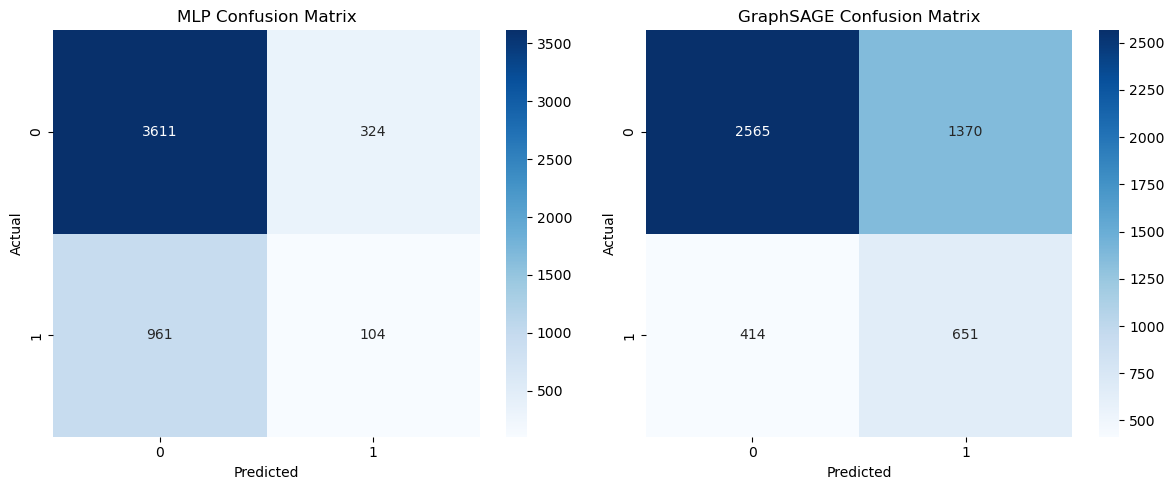

In [262]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, name in zip(
    axes,
    [y_test_mlp, y_test_gnn],
    [mlp_pred, gnn_pred],
    ["MLP", "GraphSAGE"]
):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax,
        cmap="Blues"
    )

    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [263]:
import os

os.makedirs("fintwinai_outputs", exist_ok=True)

evaluation_results.to_csv(
    "fintwinai_outputs/additional_model_metrics.csv",
    index=False
)

print("Evaluation metrics saved.")

Evaluation metrics saved.


In [264]:
import torch
import numpy as np
import pandas as pd

gnn_model.eval()

x_explain = gnn_data.x.clone().detach()
x_explain.requires_grad_(True)

gnn_model.zero_grad()

output = gnn_model(
    x_explain,
    gnn_data.edge_index
)

test_positive_logits = output[
    gnn_test_mask, 1
]

explanation_score = test_positive_logits.sum()
explanation_score.backward()

feature_gradients = x_explain.grad.abs().mean(dim=0)

print("Gradient calculation completed.")
print("Number of features:", len(feature_gradients))

Gradient calculation completed.
Number of features: 26


In [265]:
feature_importance_df = pd.DataFrame({
    "Feature": shap_feature_names,
    "Importance": feature_gradients.detach().cpu().numpy()
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(15)

,Feature,Importance
0,Feature_2,0.031942
1,Feature_23,0.021928
2,Feature_4,0.019979
3,Feature_20,0.017793
4,Feature_25,0.015948
5,Feature_9,0.015132
6,Feature_22,0.014022
7,Feature_16,0.013278
8,Feature_11,0.011021
9,Feature_17,0.010978


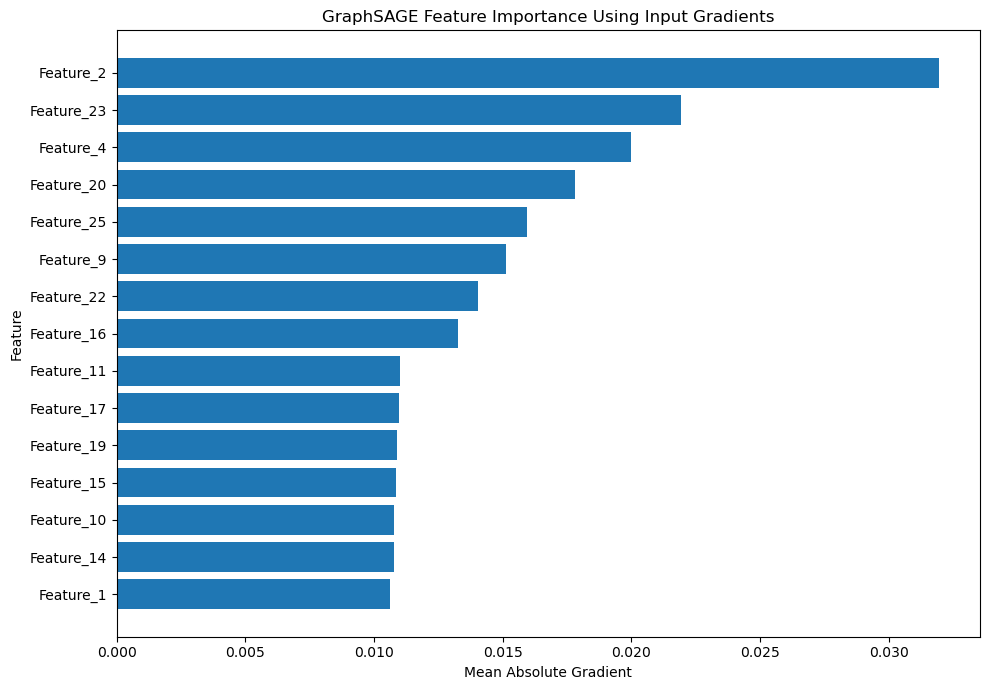

In [266]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("GraphSAGE Feature Importance Using Input Gradients")
plt.xlabel("Mean Absolute Gradient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [267]:
feature_importance_df.to_csv(
    "fintwinai_outputs/graphsage_feature_importance.csv",
    index=False
)

print("GraphSAGE feature importance saved.")

GraphSAGE feature importance saved.


In [268]:
import numpy as np
import pandas as pd

risk_probabilities = np.asarray(
    gnn_test_prob_calibrated
).reshape(-1)

risk_data = pd.DataFrame({
    "Default_Probability": risk_probabilities
})

risk_data.head()

,Default_Probability
0,0.077721
1,0.348242
2,0.108926
3,0.172060
4,0.215036


In [269]:
risk_data["Risk_Score"] = (
    1 - risk_data["Default_Probability"]
) * 100

risk_data["Risk_Category"] = pd.cut(
    risk_data["Default_Probability"],
    bins=[-np.inf, 0.20, 0.50, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_data.head()

,Default_Probability,Risk_Score,Risk_Category
0,0.077721,92.227938,Low Risk
1,0.348242,65.175844,Medium Risk
2,0.108926,89.107435,Low Risk
3,0.172060,82.794043,Low Risk
4,0.215036,78.496385,Medium Risk


Risk_Category
Low Risk       2307
Medium Risk    2539
High Risk       154
Name: count, dtype: int64


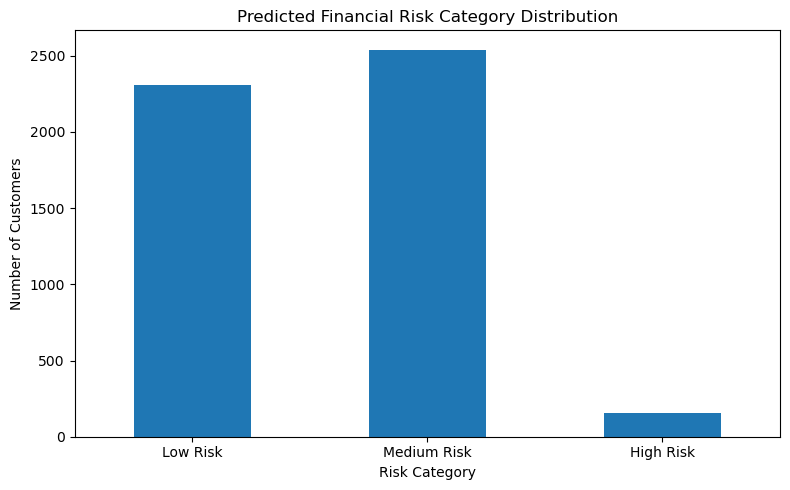

In [270]:
risk_distribution = risk_data[
    "Risk_Category"
].value_counts().sort_index()

print(risk_distribution)

risk_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

import matplotlib.pyplot as plt

plt.title("Predicted Financial Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [271]:
risk_summary = risk_data[
    ["Default_Probability", "Risk_Score"]
].describe()

risk_summary

,Default_Probability,Risk_Score
count,5000.000000,5000.000000
mean,0.235449,76.455095
std,0.133759,13.375886
min,0.000003,0.003321
25%,0.143350,70.000536
50%,0.211053,78.894670
75%,0.299995,85.664978
max,0.999967,99.999676


In [272]:
risk_data.to_csv(
    "fintwinai_outputs/graphsage_risk_scores.csv",
    index=False
)

print("Risk scores saved successfully.")

Risk scores saved successfully.


In [273]:
print("SHAP values shape:", shap_values.values.shape)
print("Explanation data shape:", explanation_data.shape)

SHAP values shape: (100, 26, 2)
Explanation data shape: (100, 26)


In [274]:
shap_array = shap_values.values

if shap_array.ndim == 3:
    shap_default_values = shap_array[:, :, 1]
else:
    shap_default_values = shap_array

print("Default-class SHAP shape:", shap_default_values.shape)

Default-class SHAP shape: (100, 26)


In [275]:
shap_importance_df = pd.DataFrame({
    "Feature": shap_feature_names,
    "Mean_Absolute_SHAP": np.abs(
        shap_default_values
    ).mean(axis=0)
})

shap_importance_df = shap_importance_df.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance_df.head(15)

,Feature,Mean_Absolute_SHAP
0,Feature_16,0.007513
1,Feature_1,0.005674
2,Feature_9,0.005643
3,Feature_25,0.004453
4,Feature_15,0.004218
5,Feature_10,0.004108
6,Feature_5,0.003287
7,Feature_17,0.003030
8,Feature_11,0.002892
9,Feature_3,0.002775


In [277]:
shap_importance_df.to_csv(
    "fintwinai_outputs/mlp_shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")

SHAP feature importance saved successfully.


In [278]:
portfolio_distribution = (
    risk_data["Risk_Category"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .fillna(0)
    .astype(int)
)

portfolio_distribution

Risk_Category
Low Risk       2307
Medium Risk    2539
High Risk       154
Name: count, dtype: int64

In [279]:
portfolio_summary = pd.DataFrame({
    "Number_of_Loans": portfolio_distribution,
    "Percentage": (
        portfolio_distribution /
        len(risk_data) * 100
    ).round(2)
})

portfolio_summary

,Number_of_Loans,Percentage
Risk_Category,,
Low Risk,2307,46.14
Medium Risk,2539,50.78
High Risk,154,3.08


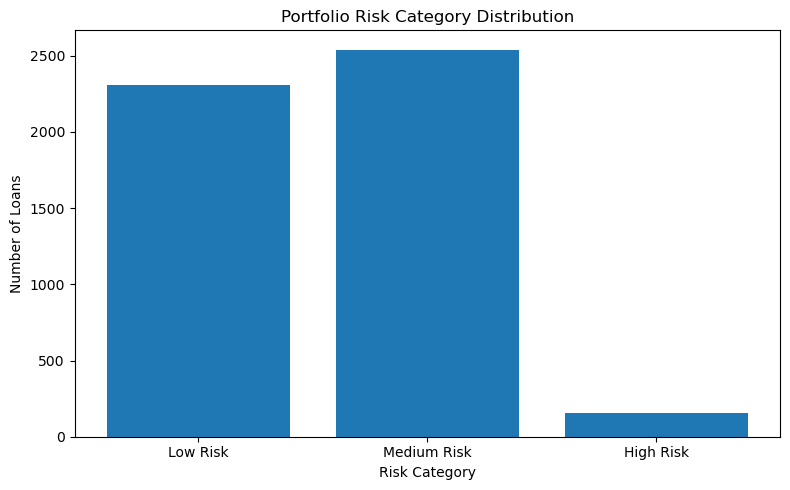

In [280]:
plt.figure(figsize=(8, 5))

plt.bar(
    portfolio_summary.index,
    portfolio_summary["Number_of_Loans"]
)

plt.title("Portfolio Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Loans")
plt.tight_layout()
plt.show()

In [281]:
portfolio_metrics = {
    "Total Loans": len(risk_data),
    "Average Default Probability": (
        risk_data["Default_Probability"].mean()
    ),
    "Average Risk Score": (
        risk_data["Risk_Score"].mean()
    ),
    "High Risk Loans": (
        (risk_data["Risk_Category"] == "High Risk").sum()
    ),
    "Medium Risk Loans": (
        (risk_data["Risk_Category"] == "Medium Risk").sum()
    ),
    "Low Risk Loans": (
        (risk_data["Risk_Category"] == "Low Risk").sum()
    )
}

portfolio_metrics

{'Total Loans': 5000,
 'Average Default Probability': np.float64(0.23544905199373817),
 'Average Risk Score': np.float64(76.45509480062618),
 'High Risk Loans': np.int64(154),
 'Medium Risk Loans': np.int64(2539),
 'Low Risk Loans': np.int64(2307)}

In [282]:
print("loan_amnt" in model_data.columns)

print([
    col for col in model_data.columns
    if "loan" in col.lower()
    or "amnt" in col.lower()
])

True
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'loan_to_income']


In [283]:
test_indices = np.where(
    gnn_test_mask.cpu().numpy()
)[0]

test_loan_amounts = model_data[
    "loan_amnt"
].iloc[test_indices].reset_index(drop=True)

print(test_loan_amounts.head())
print("Number of loan amounts:", len(test_loan_amounts))

0    10400.0
1    29900.0
2    28000.0
3     7000.0
4    21000.0
Name: loan_amnt, dtype: float64
Number of loan amounts: 5000


In [284]:
LGD = 1.0

risk_data["Exposure"] = test_loan_amounts.values

risk_data["Expected_Loss"] = (
    risk_data["Default_Probability"]
    * risk_data["Exposure"]
    * LGD
)

risk_data.head()

,Default_Probability,Risk_Score,Risk_Category,Exposure,Expected_Loss
0,0.077721,92.227938,Low Risk,10400.0,808.294450
1,0.348242,65.175844,Medium Risk,29900.0,10412.422754
2,0.108926,89.107435,Low Risk,28000.0,3049.918182
3,0.172060,82.794043,Low Risk,7000.0,1204.417024
4,0.215036,78.496385,Medium Risk,21000.0,4515.759203


In [285]:
total_exposure = risk_data["Exposure"].sum()

total_expected_loss = risk_data["Expected_Loss"].sum()

expected_loss_rate = (
    total_expected_loss / total_exposure
) * 100

print("Total Exposure:", total_exposure)
print("Expected Loss:", total_expected_loss)
print("Expected Loss Rate:", expected_loss_rate, "%")

Total Exposure: 71531325.0
Expected Loss: 16848934.473799527
Expected Loss Rate: 23.55462375931038 %


In [286]:
print("Risk records:", len(risk_data))
print("Exposure records:", len(test_loan_amounts))
print("Probability records:", len(risk_probabilities))

assert len(risk_data) == len(test_loan_amounts)
assert len(risk_data) == len(risk_probabilities)

print("Length validation passed.")

Risk records: 5000
Exposure records: 5000
Probability records: 5000
Length validation passed.


In [287]:
exposure_summary = (
    risk_data
    .groupby("Risk_Category", observed=False)
    .agg(
        Number_of_Loans=("Exposure", "count"),
        Total_Exposure=("Exposure", "sum"),
        Expected_Loss=("Expected_Loss", "sum")
    )
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

exposure_summary["Exposure_Percentage"] = (
    exposure_summary["Total_Exposure"]
    / exposure_summary["Total_Exposure"].sum()
    * 100
).round(2)

exposure_summary

,Number_of_Loans,Total_Exposure,Expected_Loss,Exposure_Percentage
Risk_Category,,,,
Low Risk,2307,32662750.0,4.354248e+06,45.66
Medium Risk,2539,36790000.0,1.106870e+07,51.43
High Risk,154,2078575.0,1.425988e+06,2.91


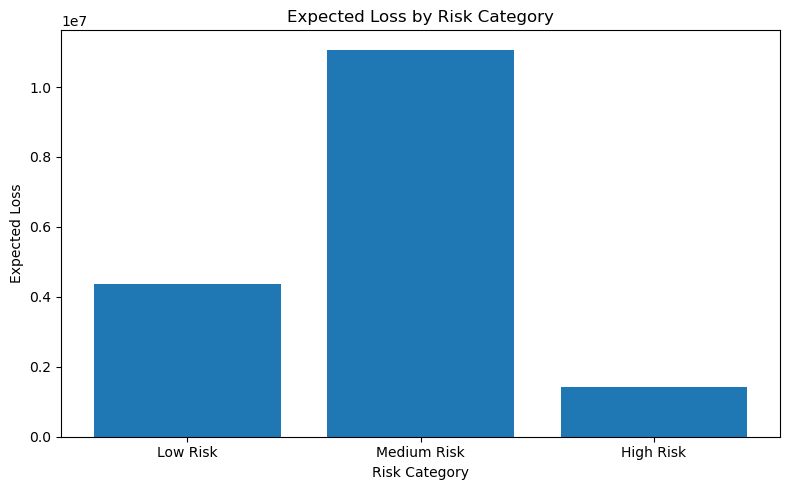

In [288]:
plt.figure(figsize=(8, 5))

plt.bar(
    exposure_summary.index,
    exposure_summary["Expected_Loss"]
)

plt.title("Expected Loss by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Expected Loss")
plt.tight_layout()
plt.show()

In [289]:
exposure_summary.to_csv(
    "fintwinai_outputs/portfolio_risk_summary.csv"
)

print("Portfolio summary saved successfully.")

Portfolio summary saved successfully.


In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas_datareader.data as web
    print("pandas_datareader is available.")
except ImportError:
    print("Install pandas_datareader using:")
    print("%pip install pandas_datareader")

Install pandas_datareader using:
%pip install pandas_datareader


In [292]:
# Install the required library
%pip install pandas_datareader -q

# Import libraries
import pandas as pd
import pandas_datareader.data as web
from datetime import datetime

# Define date range
start_date = "2007-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

# FRED indicators
fred_series = [
    "UNRATE",
    "CPIAUCSL",
    "FEDFUNDS",
    "GDP"
]

# Download data
fred_data = web.DataReader(
    fred_series,
    "fred",
    start_date,
    end_date
)

print("FRED data downloaded successfully!")
print("Shape:", fred_data.shape)

fred_data.head()

Note: you may need to restart the kernel to use updated packages.
FRED data downloaded successfully!
Shape: (236, 4)


,UNRATE,CPIAUCSL,FEDFUNDS,GDP
DATE,,,,
2007-01-01,4.6,203.437,5.25,14215.651
2007-02-01,4.5,204.226,5.26,NaN
2007-03-01,4.4,205.288,5.26,NaN
2007-04-01,4.5,205.904,5.25,14402.082
2007-05-01,4.4,206.755,5.25,NaN


In [293]:
print("Dataset shape:", fred_data.shape)

print("\nMissing values:")
print(fred_data.isnull().sum())

fred_data = fred_data.sort_index().ffill()

fred_data.tail()

Dataset shape: (236, 4)

Missing values:
UNRATE        1
CPIAUCSL      1
FEDFUNDS      0
GDP         158
dtype: int64


,UNRATE,CPIAUCSL,FEDFUNDS,GDP
DATE,,,,
2026-04-01,4.3,332.407,3.64,32486.066
2026-05-01,4.3,333.979,3.63,32486.066
2026-06-01,4.2,332.568,3.63,32486.066
2026-07-01,4.1,332.813,3.63,32486.066
2026-08-01,4.1,334.131,3.63,32486.066


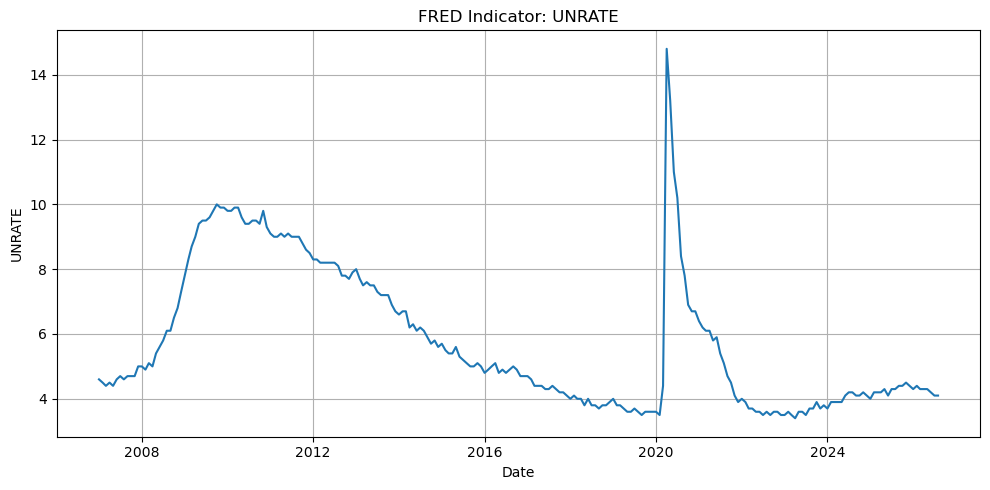

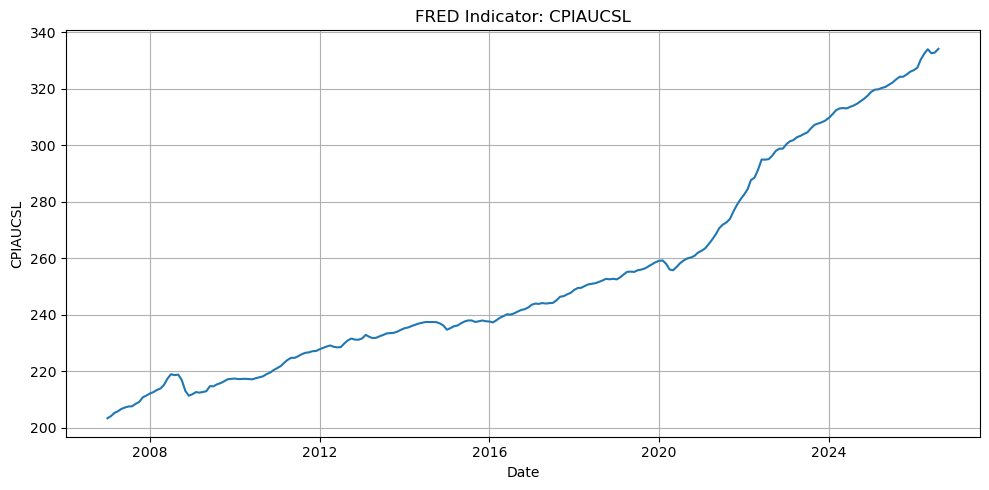

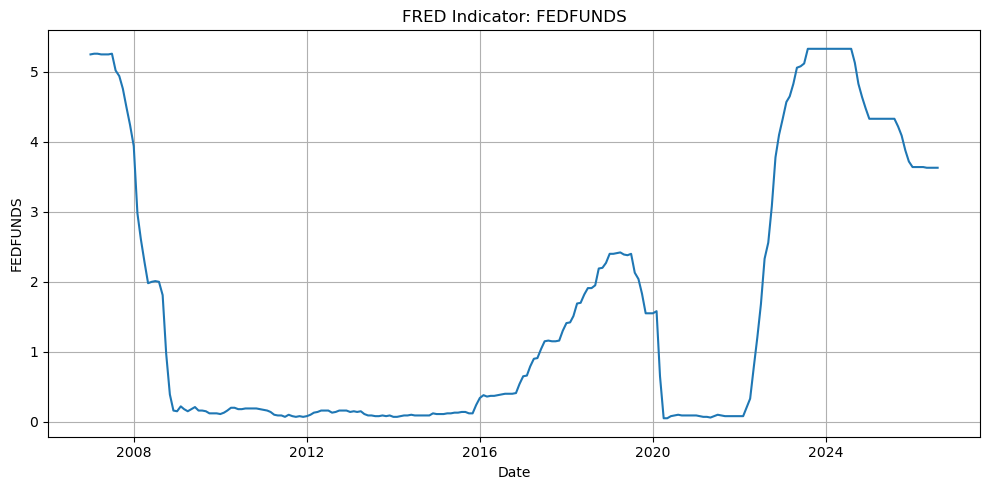

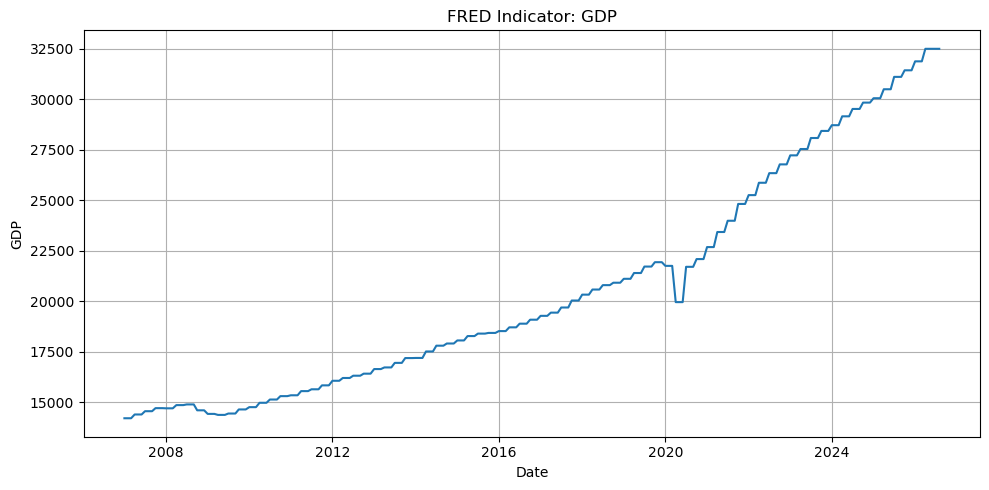

In [294]:
for column in fred_data.columns:
    plt.figure(figsize=(10, 5))

    plt.plot(
        fred_data.index,
        fred_data[column]
    )

    plt.title(f"FRED Indicator: {column}")
    plt.xlabel("Date")
    plt.ylabel(column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [295]:
import os

os.makedirs("fintwinai_outputs", exist_ok=True)

fred_data.to_csv(
    "fintwinai_outputs/fred_macro_data.csv"
)

print("FRED macroeconomic data saved successfully.")

FRED macroeconomic data saved successfully.


In [296]:
macro = fred_data.copy()

# Convert to monthly frequency
macro_monthly = macro.resample("MS").mean()

# Forward-fill quarterly GDP values
macro_monthly["GDP"] = macro_monthly["GDP"].ffill()

# Calculate inflation and GDP growth
macro_monthly["Inflation"] = (
    macro_monthly["CPIAUCSL"]
    .pct_change(12) * 100
)

macro_monthly["GDP_Growth"] = (
    macro_monthly["GDP"]
    .pct_change(12) * 100
)

macro_monthly = macro_monthly.dropna()

macro_monthly.head()

,UNRATE,CPIAUCSL,FEDFUNDS,GDP,Inflation,GDP_Growth
DATE,,,,,,
2008-01-01,5.0,212.174,3.94,14706.538,4.294696,3.453145
2008-02-01,4.9,212.687,2.98,14706.538,4.142959,3.453145
2008-03-01,5.1,213.448,2.61,14706.538,3.974904,3.453145
2008-04-01,5.0,213.942,2.28,14865.701,3.903761,3.219111
2008-05-01,5.4,215.208,1.98,14865.701,4.088414,3.219111


In [297]:
from sklearn.preprocessing import StandardScaler

stress_features = [
    "UNRATE",
    "Inflation",
    "FEDFUNDS",
    "GDP_Growth"
]

stress_data = macro_monthly[stress_features].copy()

scaler_msi = StandardScaler()

stress_scaled = pd.DataFrame(
    scaler_msi.fit_transform(stress_data),
    columns=stress_features,
    index=stress_data.index
)

# Higher GDP growth generally represents lower stress
stress_scaled["GDP_Growth"] = (
    -stress_scaled["GDP_Growth"]
)

stress_scaled.head()

,UNRATE,Inflation,FEDFUNDS,GDP_Growth
DATE,,,,
2008-01-01,-0.382207,0.900048,1.403812,0.280258
2008-02-01,-0.427315,0.822867,0.861465,0.280258
2008-03-01,-0.337099,0.737384,0.652436,0.280258
2008-04-01,-0.382207,0.701197,0.466004,0.350604
2008-05-01,-0.201776,0.795122,0.296520,0.350604


In [298]:
stress_scaled["MSI_Raw"] = (
    stress_scaled["UNRATE"]
    + stress_scaled["Inflation"]
    + stress_scaled["FEDFUNDS"]
    + stress_scaled["GDP_Growth"]
) / 4

# Convert to a 0–100 illustrative scale
msi_min = stress_scaled["MSI_Raw"].min()
msi_max = stress_scaled["MSI_Raw"].max()

stress_scaled["MSI"] = (
    (stress_scaled["MSI_Raw"] - msi_min)
    / (msi_max - msi_min)
) * 100

stress_scaled[["MSI"]].head()

,MSI
DATE,
2008-01-01,64.644764
2008-02-01,57.431941
2008-03-01,55.214853
2008-04-01,53.072821
2008-05-01,54.210924


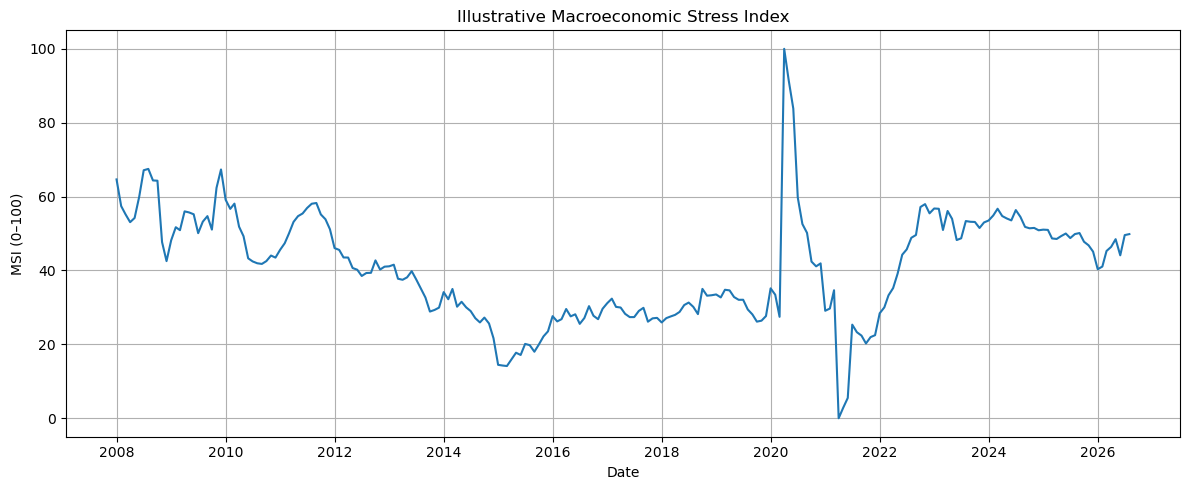

In [299]:
plt.figure(figsize=(12, 5))

plt.plot(
    stress_scaled.index,
    stress_scaled["MSI"]
)

plt.title("Illustrative Macroeconomic Stress Index")
plt.xlabel("Date")
plt.ylabel("MSI (0–100)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [300]:
loan_macro_data = pd.DataFrame({
    "Issue_Date": pd.to_datetime(
        model_data["issue_date"].iloc[test_indices]
    ).reset_index(drop=True),
    "Default_Probability": risk_data[
        "Default_Probability"
    ].values,
    "Exposure": risk_data["Exposure"].values,
    "Expected_Loss": risk_data["Expected_Loss"].values
})

loan_macro_data["Month"] = (
    loan_macro_data["Issue_Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

loan_macro_data.head()


,Issue_Date,Default_Probability,Exposure,Expected_Loss,Month
0,2015-12-01,0.077721,10400.0,808.294450,2015-12-01
1,2015-12-01,0.348242,29900.0,10412.422754,2015-12-01
2,2015-12-01,0.108926,28000.0,3049.918182,2015-12-01
3,2015-12-01,0.172060,7000.0,1204.417024,2015-12-01
4,2015-12-01,0.215036,21000.0,4515.759203,2015-12-01


In [302]:
# Prepare MSI data
msi_data = stress_scaled[["MSI"]].copy()

# Convert index into a column
msi_data = msi_data.reset_index()

# Rename the actual date column
msi_data = msi_data.rename(
    columns={"DATE": "Month"}
)

# Ensure datetime format
msi_data["Month"] = pd.to_datetime(
    msi_data["Month"]
)

print(msi_data.columns)
print(msi_data.head())

Index(['Month', 'MSI'], dtype='object')
       Month        MSI
0 2008-01-01  64.644764
1 2008-02-01  57.431941
2 2008-03-01  55.214853
3 2008-04-01  53.072821
4 2008-05-01  54.210924


In [304]:
msi_data = stress_scaled[["MSI"]].copy()

msi_data.index.name = "Month"

msi_data = msi_data.reset_index()

msi_data["Month"] = pd.to_datetime(
    msi_data["Month"]
)

msi_data.head()

,Month,MSI
0,2008-01-01,64.644764
1,2008-02-01,57.431941
2,2008-03-01,55.214853
3,2008-04-01,53.072821
4,2008-05-01,54.210924


In [305]:
# Check whether MSI is already merged
if "MSI" not in loan_macro_data.columns:

    # Prepare MSI data
    msi_data = stress_scaled[["MSI"]].copy()
    msi_data.index.name = "Month"
    msi_data = msi_data.reset_index()

    msi_data["Month"] = pd.to_datetime(
        msi_data["Month"]
    )

    # Merge MSI with loan data
    loan_macro_data = loan_macro_data.merge(
        msi_data,
        on="Month",
        how="left"
    )

# Create stress categories
loan_macro_data["Stress_Level"] = pd.cut(
    loan_macro_data["MSI"],
    bins=[-np.inf, 33.33, 66.67, np.inf],
    labels=[
        "Low Stress",
        "Medium Stress",
        "High Stress"
    ]
)

# Generate summary
macro_risk_summary = (
    loan_macro_data
    .groupby("Stress_Level", observed=False)
    .agg(
        Number_of_Loans=("Default_Probability", "count"),
        Average_Default_Probability=(
            "Default_Probability", "mean"
        ),
        Total_Exposure=("Exposure", "sum"),
        Total_Expected_Loss=("Expected_Loss", "sum")
    )
)

print("MSI column available:", "MSI" in loan_macro_data.columns)
print("Missing MSI values:", loan_macro_data["MSI"].isna().sum())

macro_risk_summary

MSI column available: True
Missing MSI values: 0


,Number_of_Loans,Average_Default_Probability,Total_Exposure,Total_Expected_Loss
Stress_Level,,,,
Low Stress,5000,0.235449,71531325.0,1.684893e+07
Medium Stress,0,NaN,0.0,0.000000e+00
High Stress,0,NaN,0.0,0.000000e+00


In [307]:
print("Loan date range:")
print(loan_macro_data["Issue_Date"].min())
print(loan_macro_data["Issue_Date"].max())

print("\nMSI statistics:")
print(loan_macro_data["MSI"].describe())

print("\nUnique MSI values:")
print(loan_macro_data["MSI"].nunique())

Loan date range:
2015-12-01 00:00:00
2015-12-01 00:00:00

MSI statistics:
count    5.000000e+03
mean     2.351764e+01
std      3.133807e-12
min      2.351764e+01
25%      2.351764e+01
50%      2.351764e+01
75%      2.351764e+01
max      2.351764e+01
Name: MSI, dtype: float64

Unique MSI values:
1


In [308]:
print(
    loan_macro_data[
        ["Issue_Date", "Month", "MSI"]
    ].head(10)
)

print("\nMSI range:")
print(
    loan_macro_data["MSI"].min(),
    loan_macro_data["MSI"].max()
)

  Issue_Date      Month        MSI
0 2015-12-01 2015-12-01  23.517642
1 2015-12-01 2015-12-01  23.517642
2 2015-12-01 2015-12-01  23.517642
3 2015-12-01 2015-12-01  23.517642
4 2015-12-01 2015-12-01  23.517642
5 2015-12-01 2015-12-01  23.517642
6 2015-12-01 2015-12-01  23.517642
7 2015-12-01 2015-12-01  23.517642
8 2015-12-01 2015-12-01  23.517642
9 2015-12-01 2015-12-01  23.517642

MSI range:
23.517642146565688 23.517642146565688


In [310]:
print("Unique loan months:")
print(loan_macro_data["Month"].nunique())

print("\nUnique MSI values:")
print(loan_macro_data["MSI"].nunique())

print("\nLoan month distribution:")
print(loan_macro_data["Month"].value_counts().head(10))

print("\nMSI distribution:")
print(loan_macro_data["MSI"].value_counts().head(10))

Unique loan months:
1

Unique MSI values:
1

Loan month distribution:
Month
2015-12-01    5000
Name: count, dtype: int64

MSI distribution:
MSI
23.517642    5000
Name: count, dtype: int64


In [312]:
# Check the number of unique MSI values
unique_msi = loan_macro_data["MSI"].nunique()

print("Unique MSI values:", unique_msi)

if unique_msi >= 3:
    loan_macro_data["Stress_Level"] = pd.qcut(
        loan_macro_data["MSI"],
        q=3,
        labels=["Low Stress", "Medium Stress", "High Stress"],
        duplicates="drop"
    )

else:
    print("Not enough unique MSI values for three categories.")
    loan_macro_data["Stress_Level"] = "Single Stress Group"

# Summary
macro_risk_summary = (
    loan_macro_data
    .groupby("Stress_Level", observed=False)
    .agg(
        Number_of_Loans=("Default_Probability", "count"),
        Average_Default_Probability=("Default_Probability", "mean"),
        Total_Exposure=("Exposure", "sum"),
        Total_Expected_Loss=("Expected_Loss", "sum")
    )
)

macro_risk_summary

Unique MSI values: 1
Not enough unique MSI values for three categories.


,Number_of_Loans,Average_Default_Probability,Total_Exposure,Total_Expected_Loss
Stress_Level,,,,
Single Stress Group,5000,0.235449,71531325.0,1.684893e+07


In [306]:
loan_macro_data.to_csv(
    "fintwinai_outputs/loan_macro_risk_data.csv",
    index=False
)

macro_risk_summary.to_csv(
    "fintwinai_outputs/macro_risk_summary.csv"
)

print("Macro-adjusted risk analysis saved successfully.")

Macro-adjusted risk analysis saved successfully.


In [315]:
import pandas as pd

sample_candidates = {}

for variable_name in dir():
    try:
        variable = globals()[variable_name]

        if (
            isinstance(variable, pd.DataFrame)
            and len(variable) == 30000
            and "issue_date" in variable.columns
        ):
            sample_candidates[variable_name] = variable.shape

    except Exception:
        pass

print(sample_candidates)

{'gnn_sample': (30000, 57)}


In [316]:
if len(sample_candidates) == 1:

    sample_name = list(sample_candidates.keys())[0]
    correct_sample = globals()[sample_name].copy()

    correct_sample = correct_sample.reset_index(drop=True)

    print("Selected DataFrame:", sample_name)
    print("Shape:", correct_sample.shape)

else:
    print("Multiple or no candidates found:")
    print(sample_candidates)

Selected DataFrame: gnn_sample
Shape: (30000, 57)


In [317]:
# Find DataFrames containing approximately 30,000 rows
sample_candidates = {}

for variable_name in dir():
    try:
        variable = globals()[variable_name]

        if isinstance(variable, pd.DataFrame):
            if len(variable) == 30000 and "issue_date" in variable.columns:
                sample_candidates[variable_name] = variable.shape

    except Exception:
        pass

sample_candidates

{'correct_sample': (30000, 57), 'gnn_sample': (30000, 57)}

In [319]:
# Automatically locate the 30,000-row sample
sample_candidates = {}

for variable_name in dir():
    try:
        variable = globals()[variable_name]

        if (
            isinstance(variable, pd.DataFrame)
            and len(variable) == 30000
            and "issue_date" in variable.columns
        ):
            sample_candidates[variable_name] = variable

    except Exception:
        pass

print("Candidates:", list(sample_candidates.keys()))

if len(sample_candidates) == 1:

    sample_name = list(sample_candidates.keys())[0]
    correct_sample = sample_candidates[sample_name].copy()
    correct_sample = correct_sample.reset_index(drop=True)

    test_positions = np.where(
        gnn_test_mask.cpu().numpy()
    )[0]

    test_loans = correct_sample.iloc[test_positions].copy()

    print("Selected sample:", sample_name)
    print("Test loans shape:", test_loans.shape)
    print("Test probabilities:", len(y_prob_gnn))

else:
    print("Could not uniquely identify the sample.")
    print("Available candidates:", list(sample_candidates.keys()))

Candidates: ['correct_sample', 'gnn_sample']
Could not uniquely identify the sample.
Available candidates: ['correct_sample', 'gnn_sample']


In [321]:
# Step 1: Find the original 30,000-row sample
sample_candidates = {}

for variable_name in dir():
    try:
        variable = globals()[variable_name]

        if (
            isinstance(variable, pd.DataFrame)
            and len(variable) == 30000
            and "issue_date" in variable.columns
        ):
            sample_candidates[variable_name] = variable

    except Exception:
        pass

print("Candidates found:", list(sample_candidates.keys()))


# Step 2: Continue only if exactly one sample is found
if len(sample_candidates) == 1:

    sample_name = list(sample_candidates.keys())[0]

    correct_sample = (
        sample_candidates[sample_name]
        .copy()
        .reset_index(drop=True)
    )

    test_positions = np.where(
        gnn_test_mask.cpu().numpy()
    )[0]

    test_loans = correct_sample.iloc[test_positions].copy()

    print("Selected sample:", sample_name)
    print("Test loans shape:", test_loans.shape)

    # Step 3: Create macro dataset
    loan_macro_data = pd.DataFrame({
        "Issue_Date": pd.to_datetime(
            test_loans["issue_date"]
        ).values,

        "Default_Probability": y_prob_gnn,

        "Exposure": test_loans["loan_amnt"].values
    })

    loan_macro_data["Expected_Loss"] = (
        loan_macro_data["Default_Probability"]
        * loan_macro_data["Exposure"]
    )

    loan_macro_data["Month"] = (
        loan_macro_data["Issue_Date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    print(
        "Unique loan months:",
        loan_macro_data["Month"].nunique()
    )

    display(loan_macro_data.head())

else:
    print(
        "Sample could not be uniquely identified."
    )
    print(
        "Please send the candidates output."
    )

Candidates found: ['correct_sample', 'gnn_sample']
Sample could not be uniquely identified.
Please send the candidates output.


In [322]:
# Use the original sample used for GraphSAGE
correct_sample = gnn_sample.copy().reset_index(drop=True)

# Identify test node positions
test_positions = np.where(
    gnn_test_mask.cpu().numpy()
)[0]

# Extract corresponding test loans
test_loans = correct_sample.iloc[test_positions].copy()

print("Test loans shape:", test_loans.shape)
print("Number of probabilities:", len(y_prob_gnn))

# Create macro dataset
loan_macro_data = pd.DataFrame({
    "Issue_Date": pd.to_datetime(
        test_loans["issue_date"]
    ).values,

    "Default_Probability": np.asarray(y_prob_gnn),

    "Exposure": test_loans["loan_amnt"].values
})

loan_macro_data["Expected_Loss"] = (
    loan_macro_data["Default_Probability"]
    * loan_macro_data["Exposure"]
)

loan_macro_data["Month"] = (
    loan_macro_data["Issue_Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(
    "Unique loan months:",
    loan_macro_data["Month"].nunique()
)

display(loan_macro_data.head())

Test loans shape: (5000, 57)
Number of probabilities: 5000
Unique loan months: 24


,Issue_Date,Default_Probability,Exposure,Expected_Loss,Month
0,2017-05-01,0.170409,8400.0,1431.435174,2017-05-01
1,2017-07-01,0.654664,32925.0,21554.809579,2017-07-01
2,2018-09-01,0.243209,15000.0,3648.135066,2018-09-01
3,2017-05-01,0.378329,2850.0,1078.236231,2017-05-01
4,2017-12-01,0.459035,5600.0,2570.594215,2017-12-01


In [323]:
# Find DataFrames containing MSI
msi_candidates = {}

for variable_name in dir():
    try:
        variable = globals()[variable_name]

        if (
            isinstance(variable, pd.DataFrame)
            and "MSI" in variable.columns
        ):
            msi_candidates[variable_name] = variable.shape

    except Exception:
        pass

print("MSI DataFrames found:")
print(msi_candidates)

MSI DataFrames found:
{'_298': (5, 1), '_304': (5, 2), 'msi_data': (224, 2), 'stress_scaled': (224, 6)}


In [324]:
msi_name = list(msi_candidates.keys())[0]
msi_data = globals()[msi_name].copy()

print("Selected MSI DataFrame:", msi_name)
print("Shape:", msi_data.shape)
print("Columns:", msi_data.columns.tolist())

display(msi_data.head())

Selected MSI DataFrame: _298
Shape: (5, 1)
Columns: ['MSI']


,MSI
DATE,
2008-01-01,64.644764
2008-02-01,57.431941
2008-03-01,55.214853
2008-04-01,53.072821
2008-05-01,54.210924


In [325]:
# Use the complete MSI dataset
msi_data = msi_data.copy()

# Inspect its structure
print("Columns:", msi_data.columns.tolist())
print("Shape:", msi_data.shape)

display(msi_data.head())
display(msi_data.tail())

Columns: ['MSI']
Shape: (5, 1)


,MSI
DATE,
2008-01-01,64.644764
2008-02-01,57.431941
2008-03-01,55.214853
2008-04-01,53.072821
2008-05-01,54.210924


,MSI
DATE,
2008-01-01,64.644764
2008-02-01,57.431941
2008-03-01,55.214853
2008-04-01,53.072821
2008-05-01,54.210924


In [326]:
# Reset index if DATE is stored as the index
msi_data = msi_data.reset_index()

# Rename date column consistently
date_column = msi_data.columns[0]

msi_data = msi_data.rename(
    columns={date_column: "Month"}
)

# Convert dates
msi_data["Month"] = pd.to_datetime(
    msi_data["Month"]
).dt.to_period("M").dt.to_timestamp()

# Keep only required columns
msi_data = msi_data[["Month", "MSI"]]

print("Prepared MSI shape:", msi_data.shape)

display(msi_data.head())

Prepared MSI shape: (5, 2)


,Month,MSI
0,2008-01-01,64.644764
1,2008-02-01,57.431941
2,2008-03-01,55.214853
3,2008-04-01,53.072821
4,2008-05-01,54.210924


In [327]:
# Recover the complete MSI dataset
msi_data = stress_scaled.copy()

print("Shape:", msi_data.shape)
print("Columns:", msi_data.columns.tolist())

display(msi_data.head())

Shape: (224, 6)
Columns: ['UNRATE', 'Inflation', 'FEDFUNDS', 'GDP_Growth', 'MSI_Raw', 'MSI']


,UNRATE,Inflation,FEDFUNDS,GDP_Growth,MSI_Raw,MSI
DATE,,,,,,
2008-01-01,-0.382207,0.900048,1.403812,0.280258,0.550478,64.644764
2008-02-01,-0.427315,0.822867,0.861465,0.280258,0.384319,57.431941
2008-03-01,-0.337099,0.737384,0.652436,0.280258,0.333244,55.214853
2008-04-01,-0.382207,0.701197,0.466004,0.350604,0.283899,53.072821
2008-05-01,-0.201776,0.795122,0.296520,0.350604,0.310117,54.210924


In [328]:
# Inspect date-related columns
print(msi_data.dtypes)
print(msi_data.columns.tolist())

UNRATE        float64
Inflation     float64
FEDFUNDS      float64
GDP_Growth    float64
MSI_Raw       float64
MSI           float64
dtype: object
['UNRATE', 'Inflation', 'FEDFUNDS', 'GDP_Growth', 'MSI_Raw', 'MSI']


In [329]:
# Recover complete MSI data
msi_data = stress_scaled.copy()

# Check index information
print("Index name:", msi_data.index.name)
print("Shape:", msi_data.shape)

# Convert index into a date column
msi_data = msi_data.reset_index()

# Rename the index column as Month
msi_data = msi_data.rename(
    columns={msi_data.columns[0]: "Month"}
)

# Convert to monthly datetime
msi_data["Month"] = pd.to_datetime(
    msi_data["Month"]
).dt.to_period("M").dt.to_timestamp()

# Keep required columns
msi_data = msi_data[["Month", "MSI"]]

print("Final MSI shape:", msi_data.shape)

display(msi_data.head())
display(msi_data.tail())

Index name: DATE
Shape: (224, 6)
Final MSI shape: (224, 2)


,Month,MSI
0,2008-01-01,64.644764
1,2008-02-01,57.431941
2,2008-03-01,55.214853
3,2008-04-01,53.072821
4,2008-05-01,54.210924


,Month,MSI
219,2026-04-01,46.393945
220,2026-05-01,48.470946
221,2026-06-01,44.100339
222,2026-07-01,49.573426
223,2026-08-01,49.844795


In [330]:
# Ensure both Month columns have the same format
loan_macro_data["Month"] = pd.to_datetime(
    loan_macro_data["Month"]
).dt.to_period("M").dt.to_timestamp()

msi_data["Month"] = pd.to_datetime(
    msi_data["Month"]
).dt.to_period("M").dt.to_timestamp()

# Merge loan data with MSI
loan_macro_data = loan_macro_data.merge(
    msi_data,
    on="Month",
    how="left"
)

# Check missing MSI values
print(
    "Missing MSI values:",
    loan_macro_data["MSI"].isna().sum()
)

print(
    "Unique months after merge:",
    loan_macro_data["Month"].nunique()
)

display(
    loan_macro_data[
        [
            "Issue_Date",
            "Month",
            "Default_Probability",
            "Exposure",
            "Expected_Loss",
            "MSI"
        ]
    ].head()
)

Missing MSI values: 0
Unique months after merge: 24


,Issue_Date,Month,Default_Probability,Exposure,Expected_Loss,MSI
0,2017-05-01,2017-05-01,0.170409,8400.0,1431.435174,28.262410
1,2017-07-01,2017-07-01,0.654664,32925.0,21554.809579,27.380581
2,2018-09-01,2018-09-01,0.243209,15000.0,3648.135066,28.187983
3,2017-05-01,2017-05-01,0.378329,2850.0,1078.236231,28.262410
4,2017-12-01,2017-12-01,0.459035,5600.0,2570.594215,27.173398


In [331]:
# Create unique month-level MSI dataset
monthly_stress = (
    loan_macro_data[["Month", "MSI"]]
    .drop_duplicates()
    .sort_values("MSI")
    .reset_index(drop=True)
)

# Assign three relative stress categories
monthly_stress["Stress_Level"] = pd.qcut(
    monthly_stress["MSI"].rank(method="first"),
    q=3,
    labels=["High Stress", "Medium Stress", "Low Stress"]
)

# Display month-level stress classification
display(monthly_stress)

,Month,MSI,Stress_Level
0,2018-01-01,25.931780,High Stress
1,2017-10-01,26.140634,High Stress
2,2017-11-01,27.039540,High Stress
3,2018-02-01,27.101689,High Stress
4,2017-12-01,27.173398,High Stress
5,2017-06-01,27.378801,High Stress
6,2017-07-01,27.380581,High Stress
7,2018-03-01,27.536452,High Stress
8,2018-04-01,27.983738,Medium Stress
9,2018-09-01,28.187983,Medium Stress


In [332]:
# Remove any previous stress classification
loan_macro_data = loan_macro_data.drop(
    columns=["Stress_Level"],
    errors="ignore"
)

# Merge monthly stress categories
loan_macro_data = loan_macro_data.merge(
    monthly_stress[["Month", "Stress_Level"]],
    on="Month",
    how="left"
)

# Check results
print(
    loan_macro_data["Stress_Level"].value_counts()
)

display(
    loan_macro_data[
        [
            "Month",
            "MSI",
            "Stress_Level",
            "Default_Probability",
            "Exposure",
            "Expected_Loss"
        ]
    ].head()
)

Stress_Level
High Stress      1954
Medium Stress    1670
Low Stress       1376
Name: count, dtype: int64


,Month,MSI,Stress_Level,Default_Probability,Exposure,Expected_Loss
0,2017-05-01,28.262410,Medium Stress,0.170409,8400.0,1431.435174
1,2017-07-01,27.380581,High Stress,0.654664,32925.0,21554.809579
2,2018-09-01,28.187983,Medium Stress,0.243209,15000.0,3648.135066
3,2017-05-01,28.262410,Medium Stress,0.378329,2850.0,1078.236231
4,2017-12-01,27.173398,High Stress,0.459035,5600.0,2570.594215


In [333]:
stress_summary = (
    loan_macro_data
    .groupby("Stress_Level", observed=False)
    .agg(
        Number_of_Loans=("Expected_Loss", "size"),
        Average_Default_Probability=(
            "Default_Probability", "mean"
        ),
        Total_Exposure=("Exposure", "sum"),
        Total_Expected_Loss=("Expected_Loss", "sum")
    )
    .reset_index()
)

display(stress_summary)

,Stress_Level,Number_of_Loans,Average_Default_Probability,Total_Exposure,Total_Expected_Loss
0,High Stress,1954,0.458708,28316000.0,1.391211e+07
1,Medium Stress,1670,0.462432,23806550.0,1.180109e+07
2,Low Stress,1376,0.456308,20736300.0,1.014790e+07


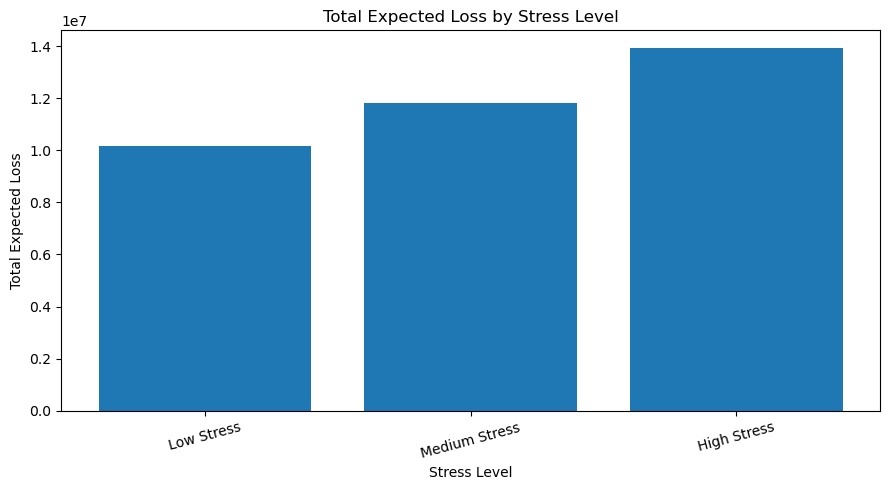

In [334]:
import matplotlib.pyplot as plt

# Sort stress categories logically
stress_order = [
    "Low Stress",
    "Medium Stress",
    "High Stress"
]

plot_data = stress_summary.set_index(
    "Stress_Level"
).reindex(stress_order)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_data.index,
    plot_data["Total_Expected_Loss"]
)

plt.title("Total Expected Loss by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Total Expected Loss")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

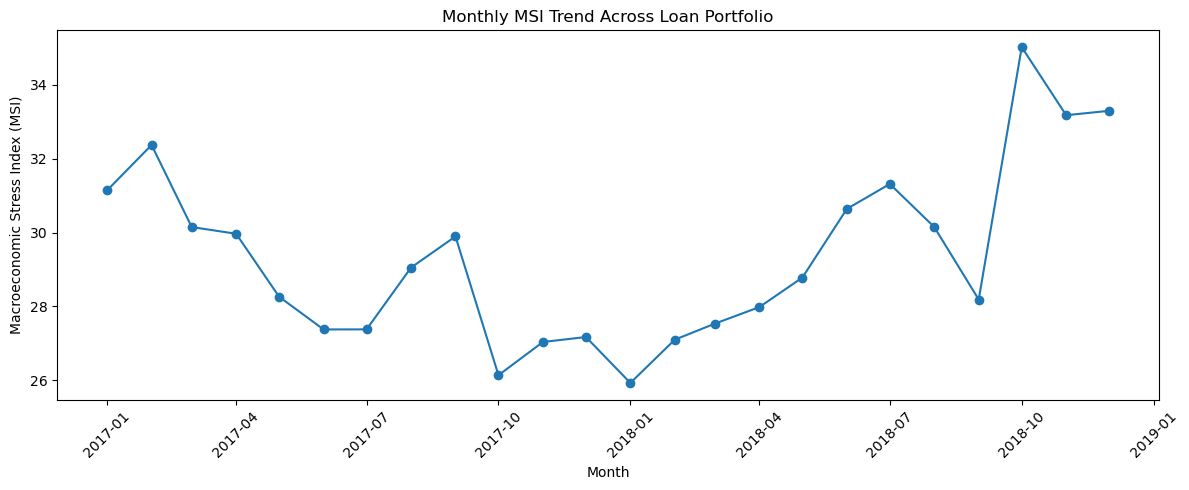

In [336]:
monthly_trend = (
    loan_macro_data
    .groupby("Month", as_index=False)
    .agg(
        MSI=("MSI", "first"),
        Total_Expected_Loss=(
            "Expected_Loss", "sum"
        ),
        Average_Default_Probability=(
            "Default_Probability", "mean"
        )
    )
    .sort_values("Month")
)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    monthly_trend["Month"],
    monthly_trend["MSI"],
    marker="o"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Macroeconomic Stress Index (MSI)")
ax1.tick_params(axis="x", rotation=45)

plt.title("Monthly MSI Trend Across Loan Portfolio")
plt.tight_layout()
plt.show()

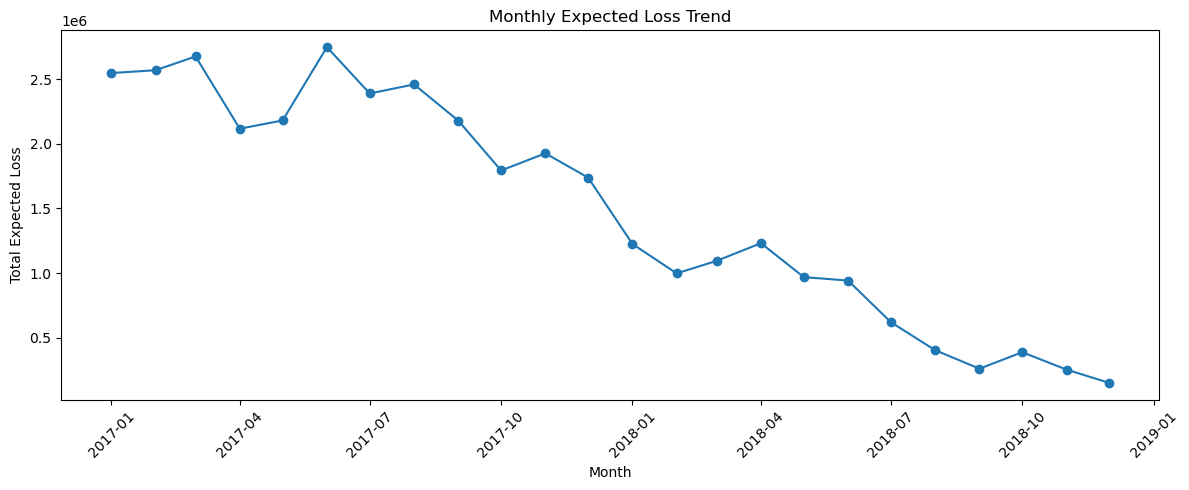

In [337]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    monthly_trend["Month"],
    monthly_trend["Total_Expected_Loss"],
    marker="o"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Total Expected Loss")
ax1.tick_params(axis="x", rotation=45)

plt.title("Monthly Expected Loss Trend")
plt.tight_layout()
plt.show()

In [338]:
# Calculate correlations
correlation_matrix = monthly_trend[
    [
        "MSI",
        "Total_Expected_Loss",
        "Average_Default_Probability"
    ]
].corr()

display(correlation_matrix)

,MSI,Total_Expected_Loss,Average_Default_Probability
MSI,1.000000,-0.319883,-0.142656
Total_Expected_Loss,-0.319883,1.000000,0.728757
Average_Default_Probability,-0.142656,0.728757,1.000000


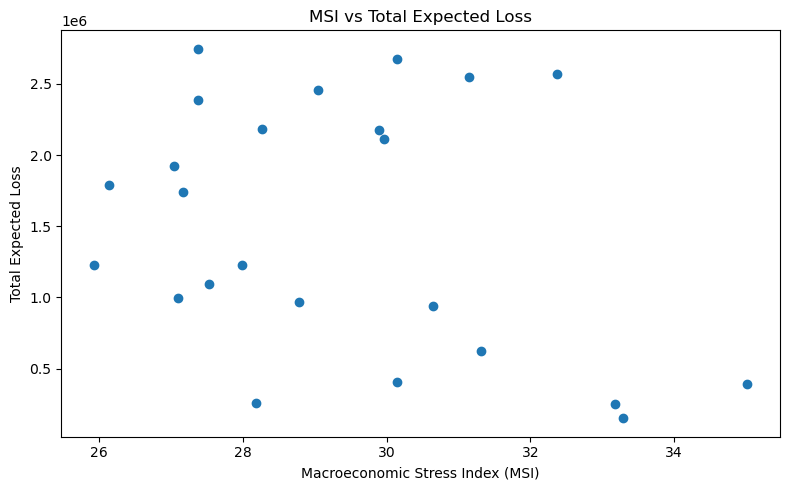

In [339]:
plt.figure(figsize=(8, 5))

plt.scatter(
    monthly_trend["MSI"],
    monthly_trend["Total_Expected_Loss"]
)

plt.xlabel("Macroeconomic Stress Index (MSI)")
plt.ylabel("Total Expected Loss")
plt.title("MSI vs Total Expected Loss")

plt.tight_layout()
plt.show()

In [340]:
import os

output_folder = "fintwinai_outputs"
os.makedirs(output_folder, exist_ok=True)

monthly_trend.to_csv(
    os.path.join(
        output_folder,
        "monthly_macro_risk_analysis.csv"
    ),
    index=False
)

stress_summary.to_csv(
    os.path.join(
        output_folder,
        "stress_level_summary.csv"
    ),
    index=False
)

correlation_matrix.to_csv(
    os.path.join(
        output_folder,
        "macro_risk_correlations.csv"
    )
)

print("Macro risk analysis files saved successfully.")

Macro risk analysis files saved successfully.


In [341]:
import numpy as np
import pandas as pd

scenario_data = loan_macro_data.copy()

# Hypothetical probability increases
scenario_data["Baseline_PD"] = (
    scenario_data["Default_Probability"]
)

scenario_data["Moderate_Stress_PD"] = np.clip(
    scenario_data["Baseline_PD"] * 1.20,
    0,
    1
)

scenario_data["Severe_Stress_PD"] = np.clip(
    scenario_data["Baseline_PD"] * 1.50,
    0,
    1
)

# Calculate scenario expected losses
scenario_data["Baseline_EL"] = (
    scenario_data["Baseline_PD"]
    * scenario_data["Exposure"]
)

scenario_data["Moderate_Stress_EL"] = (
    scenario_data["Moderate_Stress_PD"]
    * scenario_data["Exposure"]
)

scenario_data["Severe_Stress_EL"] = (
    scenario_data["Severe_Stress_PD"]
    * scenario_data["Exposure"]
)

display(
    scenario_data[
        [
            "Exposure",
            "Baseline_PD",
            "Moderate_Stress_PD",
            "Severe_Stress_PD",
            "Baseline_EL",
            "Moderate_Stress_EL",
            "Severe_Stress_EL"
        ]
    ].head()
)

,Exposure,Baseline_PD,Moderate_Stress_PD,Severe_Stress_PD,Baseline_EL,Moderate_Stress_EL,Severe_Stress_EL
0,8400.0,0.170409,0.204491,0.255613,1431.435174,1717.722309,2147.152698
1,32925.0,0.654664,0.785597,0.981996,21554.809579,25865.772280,32332.214369
2,15000.0,0.243209,0.291851,0.364814,3648.135066,4377.762079,5472.202599
3,2850.0,0.378329,0.453994,0.567493,1078.236231,1293.883511,1617.354262
4,5600.0,0.459035,0.550842,0.688552,2570.594215,3084.713125,3855.891323


In [342]:
scenario_summary = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Moderate Stress",
        "Severe Stress"
    ],

    "Total_Expected_Loss": [
        scenario_data["Baseline_EL"].sum(),
        scenario_data["Moderate_Stress_EL"].sum(),
        scenario_data["Severe_Stress_EL"].sum()
    ]
})

scenario_summary["Loss_Increase_From_Baseline"] = (
    scenario_summary["Total_Expected_Loss"]
    - scenario_summary.loc[0, "Total_Expected_Loss"]
)

display(scenario_summary)

,Scenario,Total_Expected_Loss,Loss_Increase_From_Baseline
0,Baseline,3.586109e+07,0.000000e+00
1,Moderate Stress,4.276312e+07,6.902027e+06
2,Severe Stress,5.156681e+07,1.570572e+07


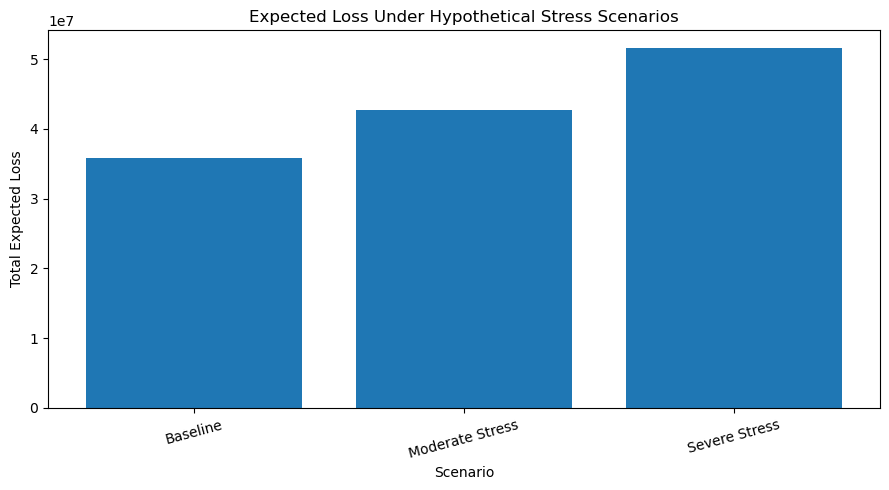

In [343]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    scenario_summary["Scenario"],
    scenario_summary["Total_Expected_Loss"]
)

plt.title("Expected Loss Under Hypothetical Stress Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Total Expected Loss")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [344]:
baseline_loss = scenario_summary.loc[
    0, "Total_Expected_Loss"
]

scenario_summary["Percentage_Increase"] = (
    scenario_summary["Loss_Increase_From_Baseline"]
    / baseline_loss
    * 100
)

display(scenario_summary)

,Scenario,Total_Expected_Loss,Loss_Increase_From_Baseline,Percentage_Increase
0,Baseline,3.586109e+07,0.000000e+00,0.000000
1,Moderate Stress,4.276312e+07,6.902027e+06,19.246561
2,Severe Stress,5.156681e+07,1.570572e+07,43.795976


In [345]:
scenario_summary.to_csv(
    "fintwinai_outputs/stress_scenario_summary.csv",
    index=False
)

scenario_data.to_csv(
    "fintwinai_outputs/stress_scenario_loan_level.csv",
    index=False
)

print("Stress scenario results saved successfully.")

Stress scenario results saved successfully.


In [346]:
# Portfolio-level risk metrics

total_exposure = scenario_data["Exposure"].sum()

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Number of Loans",
        "Total Exposure",
        "Average Default Probability",
        "Baseline Expected Loss",
        "Moderate Stress Expected Loss",
        "Severe Stress Expected Loss"
    ],

    "Value": [
        len(scenario_data),
        total_exposure,
        scenario_data["Baseline_PD"].mean(),
        scenario_data["Baseline_EL"].sum(),
        scenario_data["Moderate_Stress_EL"].sum(),
        scenario_data["Severe_Stress_EL"].sum()
    ]
})

display(portfolio_summary)

,Metric,Value
0,Number of Loans,5.000000e+03
1,Total Exposure,7.285885e+07
2,Average Default Probability,4.592912e-01
3,Baseline Expected Loss,3.586109e+07
4,Moderate Stress Expected Loss,4.276312e+07
5,Severe Stress Expected Loss,5.156681e+07


In [347]:
scenario_summary["Expected_Loss_Ratio"] = (
    scenario_summary["Total_Expected_Loss"]
    / total_exposure
    * 100
)

display(scenario_summary)

,Scenario,Total_Expected_Loss,Loss_Increase_From_Baseline,Percentage_Increase,Expected_Loss_Ratio
0,Baseline,3.586109e+07,0.000000e+00,0.000000,49.219953
1,Moderate Stress,4.276312e+07,6.902027e+06,19.246561,58.693102
2,Severe Stress,5.156681e+07,1.570572e+07,43.795976,70.776312


In [348]:
portfolio_summary.to_csv(
    "fintwinai_outputs/final_portfolio_summary.csv",
    index=False
)

scenario_summary.to_csv(
    "fintwinai_outputs/final_scenario_analysis.csv",
    index=False
)

print("Final portfolio summaries saved successfully.")

Final portfolio summaries saved successfully.


In [349]:
monthly_portfolio_summary = (
    scenario_data
    .groupby("Month", as_index=False)
    .agg(
        Number_of_Loans=("Exposure", "size"),
        Total_Exposure=("Exposure", "sum"),
        Average_Baseline_PD=("Baseline_PD", "mean"),
        Baseline_Expected_Loss=("Baseline_EL", "sum"),
        Moderate_Stress_EL=("Moderate_Stress_EL", "sum"),
        Severe_Stress_EL=("Severe_Stress_EL", "sum"),
        MSI=("MSI", "first")
    )
    .sort_values("Month")
)

display(monthly_portfolio_summary)

,Month,Number_of_Loans,Total_Exposure,Average_Baseline_PD,Baseline_Expected_Loss,Moderate_Stress_EL,Severe_Stress_EL,MSI
0,2017-01-01,357,5208500.0,0.457332,2.546967e+06,3.046602e+06,3.684668e+06,31.141166
1,2017-02-01,325,5028850.0,0.479525,2.568745e+06,3.073415e+06,3.687151e+06,32.368806
2,2017-03-01,390,5688000.0,0.446837,2.675243e+06,3.192533e+06,3.879080e+06,30.148960
3,2017-04-01,296,4302675.0,0.469082,2.116483e+06,2.518582e+06,3.052284e+06,29.966869
4,2017-05-01,327,4314525.0,0.470029,2.180582e+06,2.602204e+06,3.151588e+06,28.262410
5,2017-06-01,390,5489450.0,0.469692,2.747261e+06,3.290848e+06,3.975442e+06,27.378801
6,2017-07-01,332,4823875.0,0.477747,2.388814e+06,2.847989e+06,3.420477e+06,27.380581
7,2017-08-01,354,4970950.0,0.459485,2.459028e+06,2.939226e+06,3.555143e+06,29.052068
8,2017-09-01,267,4103725.0,0.497994,2.178967e+06,2.589734e+06,3.069872e+06,29.894749
9,2017-10-01,258,3562600.0,0.460028,1.793445e+06,2.136316e+06,2.581592e+06,26.140634


In [350]:
monthly_portfolio_summary.to_csv(
    "fintwinai_outputs/monthly_portfolio_risk_summary.csv",
    index=False
)

print("Monthly portfolio risk summary saved successfully.")

Monthly portfolio risk summary saved successfully.


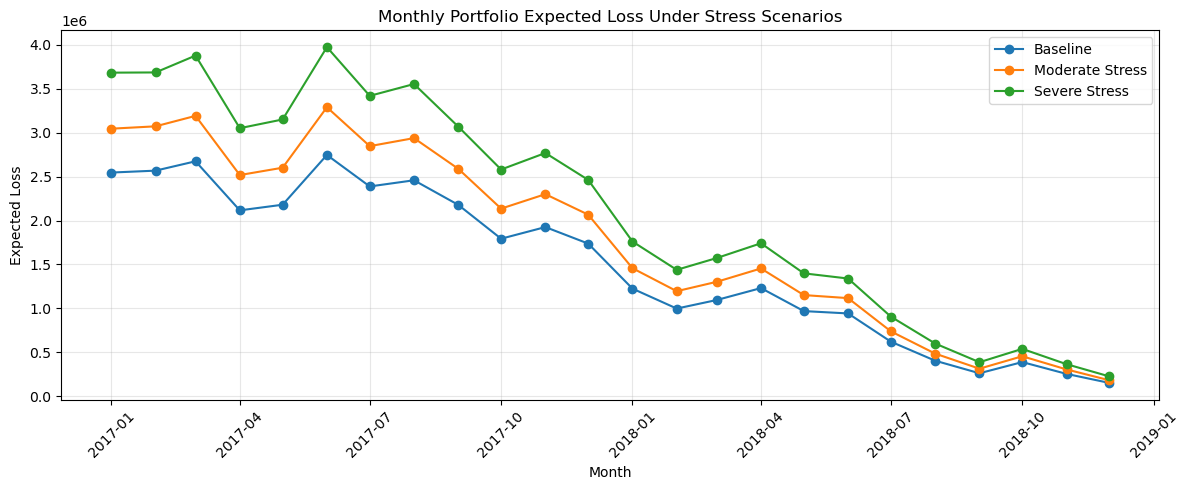

In [352]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_portfolio_summary["Month"],
    monthly_portfolio_summary["Baseline_Expected_Loss"],
    marker="o",
    label="Baseline"
)

plt.plot(
    monthly_portfolio_summary["Month"],
    monthly_portfolio_summary["Moderate_Stress_EL"],
    marker="o",
    label="Moderate Stress"
)

plt.plot(
    monthly_portfolio_summary["Month"],
    monthly_portfolio_summary["Severe_Stress_EL"],
    marker="o",
    label="Severe Stress"
)

plt.title("Monthly Portfolio Expected Loss Under Stress Scenarios")
plt.xlabel("Month")
plt.ylabel("Expected Loss")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

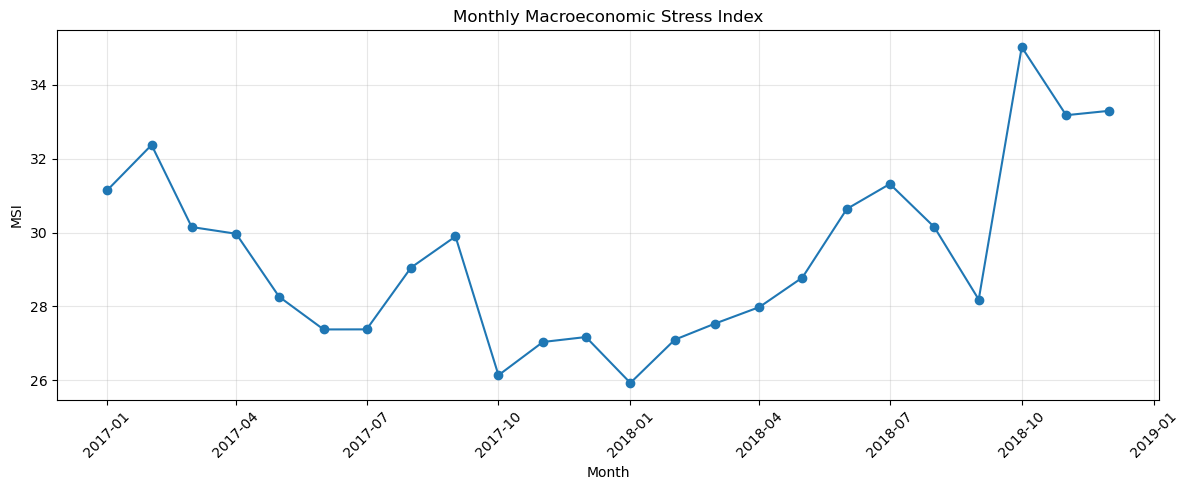

In [353]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_portfolio_summary["Month"],
    monthly_portfolio_summary["MSI"],
    marker="o"
)

plt.title("Monthly Macroeconomic Stress Index")
plt.xlabel("Month")
plt.ylabel("MSI")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [354]:
model_comparison_final = pd.DataFrame({
    "Model": [
        "MLP Baseline",
        "GraphSAGE"
    ],
    "Accuracy": [
        0.7430,
        0.6432
    ],
    "Precision": [
        0.2430,
        0.3221
    ],
    "Recall": [
        0.0977,
        0.6113
    ],
    "F1_Score": [
        0.1393,
        0.4219
    ],
    "ROC_AUC": [
        0.5533,
        0.6858
    ],
    "Average_Precision": [
        0.2417,
        0.3560
    ]
})

display(model_comparison_final)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Average_Precision
0,MLP Baseline,0.7430,0.2430,0.0977,0.1393,0.5533,0.2417
1,GraphSAGE,0.6432,0.3221,0.6113,0.4219,0.6858,0.3560


In [355]:
model_comparison_final.to_csv(
    "fintwinai_outputs/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.


In [356]:
# Identify columns relevant to survival analysis

survival_keywords = [
    "date", "status", "term", "payment",
    "default", "issue", "recover"
]

survival_columns = [
    col for col in model_data.columns
    if any(keyword in col.lower() for keyword in survival_keywords)
]

print("Potential survival-related columns:")
print(survival_columns)

Potential survival-related columns:
['term_months', 'verification_status', 'default', 'issue_date', 'issue_year']


In [357]:
# Inspect unique values and missing values
for col in survival_columns:
    print(f"\nColumn: {col}")
    print("Data type:", model_data[col].dtype)
    print("Missing values:", model_data[col].isna().sum())
    print("Unique values:", model_data[col].nunique())

    if model_data[col].nunique() < 15:
        print("Values:", model_data[col].unique())


Column: term_months
Data type: Int64
Missing values: 0
Unique values: 2
Values: <IntegerArray>
[36, 60]
Length: 2, dtype: Int64

Column: verification_status
Data type: object
Missing values: 0
Unique values: 3
Values: ['Not Verified' 'Source Verified' 'Verified']

Column: default
Data type: int8
Missing values: 0
Unique values: 2
Values: [0 1]

Column: issue_date
Data type: datetime64[ns]
Missing values: 0
Unique values: 139

Column: issue_year
Data type: int32
Missing values: 0
Unique values: 12
Values: [2015 2018 2017 2016 2014 2011 2010 2009 2008 2007 2013 2012]


In [358]:
# Identify possible event and follow-up date columns

date_columns = [
    col for col in model_data.columns
    if "date" in col.lower()
    or "pymnt" in col.lower()
    or "payment" in col.lower()
]

status_columns = [
    col for col in model_data.columns
    if "status" in col.lower()
    or "default" in col.lower()
]

print("Date columns:", date_columns)
print("Status columns:", status_columns)

if len(date_columns) <= 1:
    print(
        "\nWARNING: No clear follow-up/event date pair detected."
    )
else:
    print(
        "\nPotential follow-up dates detected. "
        "Further validation is required."
    )

Date columns: ['issue_date']
Status columns: ['verification_status', 'default']



In [359]:
# Survival analysis readiness assessment

survival_readiness = pd.DataFrame({
    "Requirement": [
        "Loan origination date",
        "Observed event or default date",
        "Censoring information",
        "Follow-up duration"
    ],

    "Available_or_Verified": [
        "issue_date" in model_data.columns,
        any(
            "pymnt" in col.lower()
            or "default_date" in col.lower()
            for col in model_data.columns
        ),
        any(
            "status" in col.lower()
            for col in model_data.columns
        ),
        False
    ]
})

display(survival_readiness)

survival_readiness.to_csv(
    "fintwinai_outputs/survival_data_readiness.csv",
    index=False
)

print("Survival readiness report saved.")

,Requirement,Available_or_Verified
0,Loan origination date,True
1,Observed event or default date,False
2,Censoring information,True
3,Follow-up duration,False


Survival readiness report saved.


In [360]:
# Check whether genuine survival analysis is possible

has_issue_date = "issue_date" in model_data.columns

event_date_candidates = [
    col for col in model_data.columns
    if any(word in col.lower()
           for word in ["default_date", "payment_date",
                        "last_pymnt_d", "settlement_date"])
]

has_event_date = len(event_date_candidates) > 0

print("Loan origination date available:", has_issue_date)
print("Potential event-date columns:", event_date_candidates)
print("Event date available:", has_event_date)

survival_possible = has_issue_date and has_event_date

print("\nSurvival analysis readiness:", survival_possible)

Loan origination date available: True
Potential event-date columns: []
Event date available: False

Survival analysis readiness: False


In [361]:
if survival_possible:

    survival_decision = (
        "Potential survival analysis possible. "
        "Validate event and censoring definitions first."
    )

else:

    survival_decision = (
        "Genuine survival analysis cannot be verified "
        "because observed event duration is unavailable."
    )

survival_decision_df = pd.DataFrame({
    "Item": [
        "Survival analysis decision",
        "Reason"
    ],

    "Result": [
        "Conditional assessment",
        survival_decision
    ]
})

display(survival_decision_df)

,Item,Result
0,Survival analysis decision,Conditional assessment
1,Reason,Genuine survival analysis cannot be verified b...


In [362]:
survival_limitation = pd.DataFrame({
    "Component": [
        "Observed event date",
        "Follow-up duration",
        "Censoring indicator",
        "Current decision"
    ],

    "Status": [
        "Not verified",
        "Not available",
        "Not verified",
        "Do not fit a genuine survival model yet"
    ]
})

survival_limitation.to_csv(
    "fintwinai_outputs/survival_analysis_limitation.csv",
    index=False
)

print("Survival limitation report saved successfully.")

Survival limitation report saved successfully.


In [363]:
methodology_status = pd.DataFrame({
    "Methodology_Component": [
        "MLP baseline",
        "GraphSAGE",
        "Probability calibration",
        "Macroeconomic Stress Index",
        "Stress scenario simulation",
        "Survival analysis"
    ],

    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Data validation required"
    ]
})

display(methodology_status)

methodology_status.to_csv(
    "fintwinai_outputs/methodology_status.csv",
    index=False
)

print("Methodology status saved successfully.")

,Methodology_Component,Status
0,MLP baseline,Completed
1,GraphSAGE,Completed
2,Probability calibration,Completed
3,Macroeconomic Stress Index,Completed
4,Stress scenario simulation,Completed
5,Survival analysis,Data validation required


Methodology status saved successfully.


In [364]:
# Create digital twin dataset
digital_twin = loan_macro_data.copy()

digital_twin["Risk_Score"] = (
    digital_twin["Default_Probability"] * 100
)

digital_twin["Exposure_Band"] = pd.cut(
    digital_twin["Exposure"],
    bins=[-float("inf"), 10000, 25000, float("inf")],
    labels=["Low Exposure", "Medium Exposure", "High Exposure"]
)

display(
    digital_twin[
        [
            "Issue_Date",
            "Default_Probability",
            "Risk_Score",
            "Exposure",
            "Exposure_Band",
            "Expected_Loss",
            "MSI"
        ]
    ].head()
)

,Issue_Date,Default_Probability,Risk_Score,Exposure,Exposure_Band,Expected_Loss,MSI
0,2017-05-01,0.170409,17.040895,8400.0,Low Exposure,1431.435174,28.262410
1,2017-07-01,0.654664,65.466393,32925.0,High Exposure,21554.809579,27.380581
2,2018-09-01,0.243209,24.320900,15000.0,Medium Exposure,3648.135066,28.187983
3,2017-05-01,0.378329,37.832851,2850.0,Low Exposure,1078.236231,28.262410
4,2017-12-01,0.459035,45.903469,5600.0,Low Exposure,2570.594215,27.173398


In [365]:
def assign_risk_category(probability):

    if probability < 0.20:
        return "Low Risk"

    elif probability < 0.40:
        return "Medium Risk"

    elif probability < 0.60:
        return "High Risk"

    else:
        return "Very High Risk"


digital_twin["Risk_Category"] = (
    digital_twin["Default_Probability"]
    .apply(assign_risk_category)
)

print(
    digital_twin["Risk_Category"]
    .value_counts()
)

display(
    digital_twin[
        [
            "Default_Probability",
            "Risk_Score",
            "Risk_Category"
        ]
    ].head()
)

Risk_Category
High Risk         1791
Medium Risk       1613
Very High Risk    1196
Low Risk           400
Name: count, dtype: int64


,Default_Probability,Risk_Score,Risk_Category
0,0.170409,17.040895,Low Risk
1,0.654664,65.466393,Very High Risk
2,0.243209,24.320900,Medium Risk
3,0.378329,37.832851,Medium Risk
4,0.459035,45.903469,High Risk


In [366]:
digital_twin_summary = (
    digital_twin
    .groupby("Risk_Category", observed=False)
    .agg(
        Number_of_Loans=("Risk_Score", "size"),
        Average_Risk_Score=("Risk_Score", "mean"),
        Total_Exposure=("Exposure", "sum"),
        Total_Expected_Loss=("Expected_Loss", "sum"),
        Average_MSI=("MSI", "mean")
    )
    .reset_index()
)

display(digital_twin_summary)

,Risk_Category,Number_of_Loans,Average_Risk_Score,Total_Exposure,Total_Expected_Loss,Average_MSI
0,High Risk,1791,49.573303,25201775.0,1.259509e+07,28.926575
1,Low Risk,400,15.278783,4919925.0,7.196872e+05,28.829957
2,Medium Risk,1613,30.935101,20099325.0,6.234577e+06,28.887534
3,Very High Risk,1196,70.944801,22637825.0,1.631174e+07,28.874298


In [367]:
import os

os.makedirs("fintwinai_outputs", exist_ok=True)

digital_twin.to_csv(
    "fintwinai_outputs/digital_twin_profiles.csv",
    index=False
)

digital_twin_summary.to_csv(
    "fintwinai_outputs/digital_twin_summary.csv",
    index=False
)

print("Digital Twin profiles and summary saved successfully.")

Digital Twin profiles and summary saved successfully.


In [368]:
# Find SHAP-related variables

shap_variables = [
    name for name in dir()
    if "shap" in name.lower()
]

print("Available SHAP variables:")
print(shap_variables)

Available SHAP variables:
['X_shap', 'feature_shap', 'individual_shap_values', 'mean_abs_shap', 'shap', 'shap_array', 'shap_default_values', 'shap_feature_names', 'shap_importance_df', 'shap_indices', 'shap_sample_size', 'shap_values', 'shape', 'signed_shap_importance']


In [369]:
# Inspect likely SHAP DataFrames

for name in shap_variables:
    try:
        obj = globals()[name]

        if isinstance(obj, pd.DataFrame):
            print(f"\n{name}: {obj.shape}")
            display(obj.head())

    except Exception:
        pass


shap_importance_df: (26, 2)


,Feature,Mean_Absolute_SHAP
0,Feature_16,0.007513
1,Feature_1,0.005674
2,Feature_9,0.005643
3,Feature_25,0.004453
4,Feature_15,0.004218



signed_shap_importance: (112, 3)


,Feature,Mean_Absolute_SHAP,Mean_Signed_SHAP
0,numerical__int_rate,0.337358,-0.081625
1,numerical__term_months,0.267176,-0.053421
2,numerical__acc_open_past_24mths,0.158720,0.010372
3,numerical__dti,0.107564,-0.012619
4,numerical__loan_to_income,0.086636,-0.028565


In [370]:
print("Digital Twin columns:")
print(digital_twin.columns.tolist())

print("\nDigital Twin shape:")
print(digital_twin.shape)

Digital Twin columns:
['Issue_Date', 'Default_Probability', 'Exposure', 'Expected_Loss', 'Month', 'MSI', 'Stress_Level', 'Risk_Score', 'Exposure_Band', 'Risk_Category']

Digital Twin shape:
(5000, 10)


In [371]:
digital_twin.to_csv(
    "fintwinai_outputs/digital_twin_profiles_final.csv",
    index=False
)

digital_twin_summary.to_csv(
    "fintwinai_outputs/digital_twin_risk_summary_final.csv",
    index=False
)

print("Digital Twin progress saved successfully.")

Digital Twin progress saved successfully.


In [372]:

# Find all variables related to SHAP
shap_variables = [
    name for name in dir()
    if "shap" in name.lower()
]

print("SHAP-related variables:")
print(shap_variables)

SHAP-related variables:
['X_shap', 'feature_shap', 'individual_shap_values', 'mean_abs_shap', 'shap', 'shap_array', 'shap_default_values', 'shap_feature_names', 'shap_importance_df', 'shap_indices', 'shap_sample_size', 'shap_values', 'shap_variables', 'shape', 'signed_shap_importance']


In [373]:
for variable_name in shap_variables:
    try:
        variable = globals()[variable_name]

        print("\nVariable:", variable_name)
        print("Type:", type(variable))

        if hasattr(variable, "shape"):
            print("Shape:", variable.shape)

        if isinstance(variable, pd.DataFrame):
            display(variable.head())

    except Exception as error:
        print(variable_name, "could not be inspected:", error)


Variable: X_shap
Type: <class 'numpy.ndarray'>
Shape: (5000, 112)

Variable: feature_shap
Type: <class 'numpy.ndarray'>
Shape: (5000,)

Variable: individual_shap_values
Type: <class 'numpy.ndarray'>
Shape: (112,)

Variable: mean_abs_shap
Type: <class 'numpy.ndarray'>
Shape: (112,)

Variable: shap
Type: <class 'module'>

Variable: shap_array
Type: <class 'numpy.ndarray'>
Shape: (100, 26, 2)

Variable: shap_default_values
Type: <class 'numpy.ndarray'>
Shape: (100, 26)

Variable: shap_feature_names
Type: <class 'list'>

Variable: shap_importance_df
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (26, 2)


,Feature,Mean_Absolute_SHAP
0,Feature_16,0.007513
1,Feature_1,0.005674
2,Feature_9,0.005643
3,Feature_25,0.004453
4,Feature_15,0.004218



Variable: shap_indices
Type: <class 'numpy.ndarray'>
Shape: (5000,)

Variable: shap_sample_size
Type: <class 'int'>

Variable: shap_values
Type: <class 'shap._explanation.Explanation'>
Shape: (100, 26, 2)

Variable: shap_variables
Type: <class 'list'>

Variable: shape
Type: <class 'tuple'>

Variable: signed_shap_importance
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (112, 3)


,Feature,Mean_Absolute_SHAP,Mean_Signed_SHAP
0,numerical__int_rate,0.337358,-0.081625
1,numerical__term_months,0.267176,-0.053421
2,numerical__acc_open_past_24mths,0.158720,0.010372
3,numerical__dti,0.107564,-0.012619
4,numerical__loan_to_income,0.086636,-0.028565


In [374]:
print("Digital Twin shape:", digital_twin.shape)

print("\nDigital Twin columns:")
print(digital_twin.columns.tolist())

print("\nMissing values:")
display(
    digital_twin.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Digital Twin shape: (5000, 10)

Digital Twin columns:
['Issue_Date', 'Default_Probability', 'Exposure', 'Expected_Loss', 'Month', 'MSI', 'Stress_Level', 'Risk_Score', 'Exposure_Band', 'Risk_Category']

Missing values:


Issue_Date             0
Default_Probability    0
Exposure               0
Expected_Loss          0
Month                  0
MSI                    0
Stress_Level           0
Risk_Score             0
Exposure_Band          0
Risk_Category          0
dtype: int64

In [375]:
import os

output_folder = "fintwinai_outputs"
os.makedirs(output_folder, exist_ok=True)

digital_twin.to_csv(
    os.path.join(output_folder, "digital_twin_profiles_final.csv"),
    index=False
)

digital_twin_summary = (
    digital_twin.groupby("Risk_Category")
    .agg(
        Number_of_Loans=("Risk_Category", "size"),
        Average_Risk_Score=("Risk_Score", "mean"),
        Total_Exposure=("Exposure", "sum"),
        Total_Expected_Loss=("Expected_Loss", "sum"),
        Average_MSI=("MSI", "mean")
    )
    .reset_index()
)

digital_twin_summary.to_csv(
    os.path.join(output_folder, "digital_twin_risk_summary_final.csv"),
    index=False
)

print("Digital Twin files saved successfully.")
display(digital_twin_summary)

Digital Twin files saved successfully.


,Risk_Category,Number_of_Loans,Average_Risk_Score,Total_Exposure,Total_Expected_Loss,Average_MSI
0,High Risk,1791,49.573303,25201775.0,1.259509e+07,28.926575
1,Low Risk,400,15.278783,4919925.0,7.196872e+05,28.829957
2,Medium Risk,1613,30.935101,20099325.0,6.234577e+06,28.887534
3,Very High Risk,1196,70.944801,22637825.0,1.631174e+07,28.874298


In [376]:
shap_variables = [
    name for name in dir()
    if "shap" in name.lower()
]

print("SHAP-related variables:")
print(shap_variables)

SHAP-related variables:
['X_shap', 'feature_shap', 'individual_shap_values', 'mean_abs_shap', 'shap', 'shap_array', 'shap_default_values', 'shap_feature_names', 'shap_importance_df', 'shap_indices', 'shap_sample_size', 'shap_values', 'shap_variables', 'shape', 'signed_shap_importance']


In [377]:
for variable_name in shap_variables:
    try:
        variable = globals()[variable_name]

        print("\nVariable:", variable_name)
        print("Type:", type(variable))

        if hasattr(variable, "shape"):
            print("Shape:", variable.shape)

        if isinstance(variable, pd.DataFrame):
            display(variable.head())

    except Exception as error:
        print("Error:", variable_name, error)


Variable: X_shap
Type: <class 'numpy.ndarray'>
Shape: (5000, 112)

Variable: feature_shap
Type: <class 'numpy.ndarray'>
Shape: (5000,)

Variable: individual_shap_values
Type: <class 'numpy.ndarray'>
Shape: (112,)

Variable: mean_abs_shap
Type: <class 'numpy.ndarray'>
Shape: (112,)

Variable: shap
Type: <class 'module'>

Variable: shap_array
Type: <class 'numpy.ndarray'>
Shape: (100, 26, 2)

Variable: shap_default_values
Type: <class 'numpy.ndarray'>
Shape: (100, 26)

Variable: shap_feature_names
Type: <class 'list'>

Variable: shap_importance_df
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (26, 2)


,Feature,Mean_Absolute_SHAP
0,Feature_16,0.007513
1,Feature_1,0.005674
2,Feature_9,0.005643
3,Feature_25,0.004453
4,Feature_15,0.004218



Variable: shap_indices
Type: <class 'numpy.ndarray'>
Shape: (5000,)

Variable: shap_sample_size
Type: <class 'int'>

Variable: shap_values
Type: <class 'shap._explanation.Explanation'>
Shape: (100, 26, 2)

Variable: shap_variables
Type: <class 'list'>

Variable: shape
Type: <class 'tuple'>

Variable: signed_shap_importance
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (112, 3)


,Feature,Mean_Absolute_SHAP,Mean_Signed_SHAP
0,numerical__int_rate,0.337358,-0.081625
1,numerical__term_months,0.267176,-0.053421
2,numerical__acc_open_past_24mths,0.158720,0.010372
3,numerical__dti,0.107564,-0.012619
4,numerical__loan_to_income,0.086636,-0.028565


In [378]:
# Search for feature-importance-related variables
importance_variables = [
    name for name in dir()
    if any(keyword in name.lower()
           for keyword in ["importance", "feature_importance"])
]

print("Feature importance variables:")
print(importance_variables)

Feature importance variables:
['feature_importance_df', 'shap_importance_df', 'signed_shap_importance']


In [379]:
for variable_name in importance_variables:
    try:
        variable = globals()[variable_name]

        print("\nVariable:", variable_name)
        print("Type:", type(variable))

        if isinstance(variable, pd.DataFrame):
            display(variable.head(10))
        elif isinstance(variable, (list, np.ndarray)):
            print(variable[:10])

    except Exception as error:
        print("Could not inspect:", variable_name, error)


Variable: feature_importance_df
Type: <class 'pandas.core.frame.DataFrame'>


,Feature,Importance
0,Feature_2,0.031942
1,Feature_23,0.021928
2,Feature_4,0.019979
3,Feature_20,0.017793
4,Feature_25,0.015948
5,Feature_9,0.015132
6,Feature_22,0.014022
7,Feature_16,0.013278
8,Feature_11,0.011021
9,Feature_17,0.010978



Variable: shap_importance_df
Type: <class 'pandas.core.frame.DataFrame'>


,Feature,Mean_Absolute_SHAP
0,Feature_16,0.007513
1,Feature_1,0.005674
2,Feature_9,0.005643
3,Feature_25,0.004453
4,Feature_15,0.004218
5,Feature_10,0.004108
6,Feature_5,0.003287
7,Feature_17,0.003030
8,Feature_11,0.002892
9,Feature_3,0.002775



Variable: signed_shap_importance
Type: <class 'pandas.core.frame.DataFrame'>


,Feature,Mean_Absolute_SHAP,Mean_Signed_SHAP
0,numerical__int_rate,0.337358,-0.081625
1,numerical__term_months,0.267176,-0.053421
2,numerical__acc_open_past_24mths,0.158720,0.010372
3,numerical__dti,0.107564,-0.012619
4,numerical__loan_to_income,0.086636,-0.028565
5,numerical__fico_range_low,0.077045,-0.026035
6,numerical__avg_cur_bal,0.074829,-0.010969
7,categorical__grade_A,0.065226,0.000214
8,numerical__mo_sin_old_rev_tl_op,0.062462,0.005802
9,numerical__total_acc,0.046961,0.006167


In [380]:
import importlib.util

shap_installed = importlib.util.find_spec("shap") is not None

print("SHAP installed:", shap_installed)
print("SHAP variables found:", shap_variables)

SHAP installed: True
SHAP variables found: ['X_shap', 'feature_shap', 'individual_shap_values', 'mean_abs_shap', 'shap', 'shap_array', 'shap_default_values', 'shap_feature_names', 'shap_importance_df', 'shap_indices', 'shap_sample_size', 'shap_values', 'shap_variables', 'shape', 'signed_shap_importance']


In [381]:
usable_shap_objects = {}

for variable_name in shap_variables:
    try:
        obj = globals()[variable_name]

        if isinstance(obj, (pd.DataFrame, np.ndarray, list)):
            usable_shap_objects[variable_name] = obj

    except Exception:
        pass

print("Usable SHAP objects:")
print(list(usable_shap_objects.keys()))

Usable SHAP objects:
['X_shap', 'feature_shap', 'individual_shap_values', 'mean_abs_shap', 'shap_array', 'shap_default_values', 'shap_feature_names', 'shap_importance_df', 'shap_indices', 'shap_variables', 'signed_shap_importance']


In [382]:
if len(usable_shap_objects) > 0:
    explainability_status = "Existing SHAP output detected"
else:
    explainability_status = (
        "No verified SHAP output detected. "
        "SHAP explanations must be generated separately."
    )

explainability_report = pd.DataFrame({
    "Component": [
        "SHAP Library",
        "SHAP Output",
        "GraphSAGE Explanation"
    ],
    "Status": [
        "Installed" if shap_installed else "Not Installed",
        explainability_status,
        "Not yet verified"
    ]
})

display(explainability_report)

,Component,Status
0,SHAP Library,Installed
1,SHAP Output,Existing SHAP output detected
2,GraphSAGE Explanation,Not yet verified


In [383]:
explainability_report.to_csv(
    os.path.join(
        output_folder,
        "explainability_status_report.csv"
    ),
    index=False
)

print("Explainability report saved successfully.")

Explainability report saved successfully.


In [384]:
for name, obj in usable_shap_objects.items():
    print("\n" + "=" * 60)
    print("Variable:", name)
    print("Type:", type(obj))

    if isinstance(obj, pd.DataFrame):
        print("Shape:", obj.shape)
        print("Columns:", obj.columns.tolist()[:15])
        display(obj.head(3))

    elif isinstance(obj, np.ndarray):
        print("Shape:", obj.shape)
        print("First values:", obj.flatten()[:10])

    elif isinstance(obj, list):
        print("Length:", len(obj))
        print("First item:", obj[:2])


Variable: X_shap
Type: <class 'numpy.ndarray'>
Shape: (5000, 112)
First values: [ 0.6686275   0.67079806  0.67430549  1.55668231  1.24660114 -0.57990292
 -1.57763521 -0.21706937 -0.10782001  3.43212163]

Variable: feature_shap
Type: <class 'numpy.ndarray'>
Shape: (5000,)
First values: [-3.1507751e-03  7.0418776e-07  7.0418776e-07  7.0418776e-07
  1.2723409e-05  4.9333112e-06  1.3227160e-06  1.4257158e-05
  1.0034566e-06  4.9333112e-06]

Variable: individual_shap_values
Type: <class 'numpy.ndarray'>
Shape: (112,)
First values: [ 7.2312490e-03  4.8880687e-05 -5.6695696e-03  3.3523017e-01
 -2.8123807e-02 -1.9996548e-01  6.6555686e-02  1.8788956e-02
  1.5046106e-02  1.5784203e-01]

Variable: mean_abs_shap
Type: <class 'numpy.ndarray'>
Shape: (112,)
First values: [0.02453869 0.02487898 0.02277225 0.337358   0.01358467 0.26717624
 0.04159044 0.04672138 0.00891707 0.10756351]

Variable: shap_array
Type: <class 'numpy.ndarray'>
Shape: (100, 26, 2)
First values: [-0.01773354  0.01773355 -0.000

,Feature,Mean_Absolute_SHAP
0,Feature_16,0.007513
1,Feature_1,0.005674
2,Feature_9,0.005643



Variable: shap_indices
Type: <class 'numpy.ndarray'>
Shape: (5000,)
First values: [110011 149711 180805 164755  46719 141749 121852 218765 115209 143151]

Variable: shap_variables
Type: <class 'list'>
Length: 15
First item: ['X_shap', 'feature_shap']

Variable: signed_shap_importance
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (112, 3)
Columns: ['Feature', 'Mean_Absolute_SHAP', 'Mean_Signed_SHAP']


,Feature,Mean_Absolute_SHAP,Mean_Signed_SHAP
0,numerical__int_rate,0.337358,-0.081625
1,numerical__term_months,0.267176,-0.053421
2,numerical__acc_open_past_24mths,0.158720,0.010372


In [385]:
import shap

print("SHAP version:", shap.__version__)

for name in shap_variables:
    try:
        obj = globals()[name]

        print(
            name,
            "→",
            type(obj).__name__,
            " | Explanation object:",
            isinstance(obj, shap.Explanation)
        )

    except Exception as error:
        print("Error:", name, error)

SHAP version: 0.51.0
X_shap → ndarray  | Explanation object: False
feature_shap → ndarray  | Explanation object: False
individual_shap_values → ndarray  | Explanation object: False
mean_abs_shap → ndarray  | Explanation object: False
shap → module  | Explanation object: False
shap_array → ndarray  | Explanation object: False
shap_default_values → ndarray  | Explanation object: False
shap_feature_names → list  | Explanation object: False
shap_importance_df → DataFrame  | Explanation object: False
shap_indices → ndarray  | Explanation object: False
shap_sample_size → int  | Explanation object: False
shap_values → Explanation  | Explanation object: True
shap_variables → list  | Explanation object: False
shape → tuple  | Explanation object: False
signed_shap_importance → DataFrame  | Explanation object: False


In [387]:
# Search for variables that may contain feature names
feature_candidates = []

keywords = [
    "feature",
    "column",
    "selected",
    "numeric"
]

for name in dir():
    name_lower = name.lower()

    if any(keyword in name_lower for keyword in keywords):
        try:
            obj = globals()[name]

            if isinstance(obj, (list, tuple, pd.Index, np.ndarray)):
                feature_candidates.append(name)

        except Exception:
            pass

print("Possible feature-related variables:")
print(feature_candidates)

Possible feature-related variables:
['available_features', 'available_leakage_columns', 'available_target_columns', 'categorical_features', 'date_columns', 'engineered_columns', 'feature_candidates', 'feature_columns', 'feature_names', 'feature_shap', 'feature_values', 'gnn_features', 'gnn_features_scaled', 'leakage_columns', 'missing_features', 'missing_gnn_features', 'missing_model_columns', 'model_columns', 'numeric_check_columns', 'numeric_columns', 'numeric_features', 'selected_columns', 'shap_feature_names', 'status_columns', 'stress_features', 'survival_columns', 'target_columns']


In [388]:
for name in feature_candidates:
    try:
        obj = globals()[name]

        print("\nVariable:", name)
        print("Type:", type(obj))
        print("Length:", len(obj))
        print("First values:", list(obj)[:10])

    except Exception as error:
        print("Could not inspect:", name, error)


Variable: available_features
Type: <class 'list'>
Length: 51
First values: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'term_months', 'grade', 'sub_grade', 'emp_length_years', 'home_ownership']

Variable: available_leakage_columns
Type: <class 'list'>
Length: 2
First values: ['loan_status', 'default']

Variable: available_target_columns
Type: <class 'list'>
Length: 8
First values: ['loan_status', 'issue_d', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'term', 'grade', 'sub_grade']

Variable: categorical_features
Type: <class 'list'>
Length: 6
First values: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'application_type']

Variable: date_columns
Type: <class 'list'>
Length: 1
First values: ['issue_date']

Variable: engineered_columns
Type: <class 'list'>
Length: 15
First values: ['term_months', 'fico_avg', 'fico_range', 'loan_to_income', 'installment_to_income', 'annual_inc_log', 'loan_amnt_log', 'revol_bal_log', 'tot

In [389]:
# Try to find a candidate with exactly 26 features
gnn_feature_names = None

for name in feature_candidates:
    try:
        obj = globals()[name]

        if len(obj) == 26:
            candidate_names = list(obj)

            if all(isinstance(x, str) for x in candidate_names):
                gnn_feature_names = candidate_names
                print("Feature names recovered from:", name)
                break

    except Exception:
        continue

if gnn_feature_names is not None:
    print("Number of features:", len(gnn_feature_names))
    print(gnn_feature_names)
else:
    print("Could not automatically identify the 26 feature names.")

Feature names recovered from: gnn_features
Number of features: 26
['loan_amnt', 'int_rate', 'installment', 'term_months', 'emp_length_years', 'annual_inc_log', 'dti', 'delinq_2yrs', 'fico_avg', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal_log', 'revol_util', 'total_acc', 'tot_cur_bal_log', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_util', 'credit_history_years', 'mort_acc', 'loan_to_income', 'installment_to_income', 'revolving_utilization_decimal', 'bc_utilization_decimal']


In [390]:
print("SHAP array shape:", shap_array.shape)
print("SHAP default values shape:", shap_default_values.shape)
print("Number of feature names:", len(shap_feature_names))

assert shap_default_values.shape[1] == len(shap_feature_names)

print("SHAP dimensions validated successfully.")

SHAP array shape: (100, 26, 2)
SHAP default values shape: (100, 26)
Number of feature names: 26
SHAP dimensions validated successfully.


In [391]:
shap_importance_final = pd.DataFrame({
    "Feature": shap_feature_names,
    "Mean_Absolute_SHAP": np.mean(
        np.abs(shap_default_values),
        axis=0
    )
})

shap_importance_final = (
    shap_importance_final
    .sort_values("Mean_Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_final.head(10))

,Feature,Mean_Absolute_SHAP
0,Feature_16,0.007513
1,Feature_1,0.005674
2,Feature_9,0.005643
3,Feature_25,0.004453
4,Feature_15,0.004218
5,Feature_10,0.004108
6,Feature_5,0.003287
7,Feature_17,0.003030
8,Feature_11,0.002892
9,Feature_3,0.002775


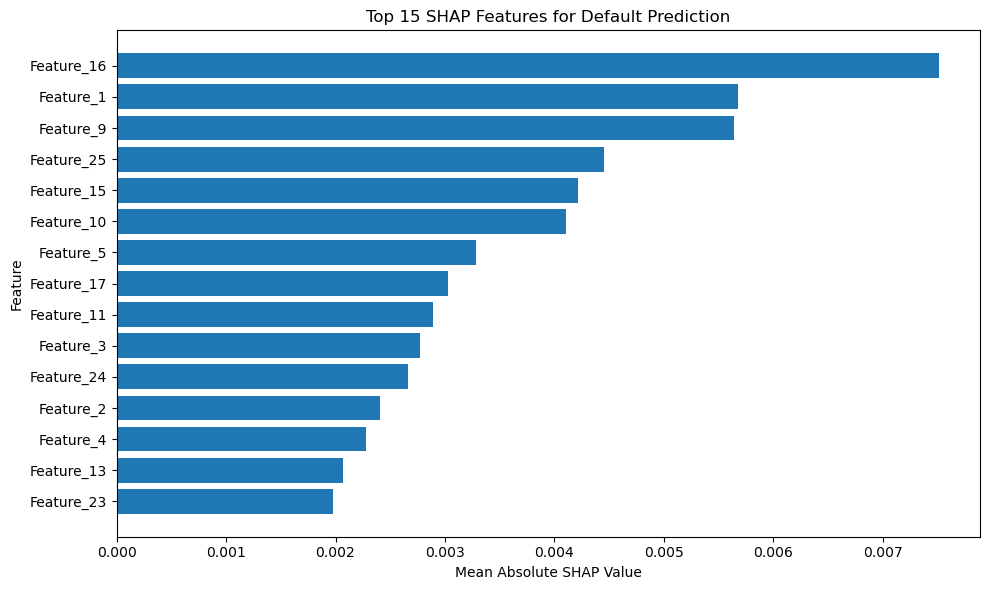

In [392]:
import matplotlib.pyplot as plt

top_shap = shap_importance_final.head(15).sort_values(
    "Mean_Absolute_SHAP"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_shap["Feature"],
    top_shap["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 SHAP Features for Default Prediction")
plt.tight_layout()
plt.show()

In [393]:
shap_importance_final.to_csv(
    os.path.join(
        output_folder,
        "shap_feature_importance_final.csv"
    ),
    index=False
)

print("SHAP importance file saved successfully.")

SHAP importance file saved successfully.


In [394]:
dashboard_risk_profile = digital_twin[
    [
        "Month",
        "Default_Probability",
        "Risk_Score",
        "Risk_Category",
        "Exposure",
        "Expected_Loss",
        "MSI"
    ]
].copy()

dashboard_risk_profile = dashboard_risk_profile.rename(columns={
    "Default_Probability": "Probability_of_Default",
    "Expected_Loss": "Baseline_Expected_Loss",
    "MSI": "Macro_Stress_Index"
})

display(dashboard_risk_profile.head())
print("Dashboard records:", dashboard_risk_profile.shape)

,Month,Probability_of_Default,Risk_Score,Risk_Category,Exposure,Baseline_Expected_Loss,Macro_Stress_Index
0,2017-05-01,0.170409,17.040895,Low Risk,8400.0,1431.435174,28.262410
1,2017-07-01,0.654664,65.466393,Very High Risk,32925.0,21554.809579,27.380581
2,2018-09-01,0.243209,24.320900,Medium Risk,15000.0,3648.135066,28.187983
3,2017-05-01,0.378329,37.832851,Medium Risk,2850.0,1078.236231,28.262410
4,2017-12-01,0.459035,45.903469,High Risk,5600.0,2570.594215,27.173398


Dashboard records: (5000, 7)


In [395]:
dashboard_kpis = pd.DataFrame({
    "KPI": [
        "Total Loans",
        "Total Exposure",
        "Total Expected Loss",
        "Average Probability of Default",
        "Average Risk Score",
        "Average Macro Stress Index"
    ],
    "Value": [
        len(digital_twin),
        digital_twin["Exposure"].sum(),
        digital_twin["Expected_Loss"].sum(),
        digital_twin["Default_Probability"].mean(),
        digital_twin["Risk_Score"].mean(),
        digital_twin["MSI"].mean()
    ]
})

display(dashboard_kpis)

,KPI,Value
0,Total Loans,5.000000e+03
1,Total Exposure,7.285885e+07
2,Total Expected Loss,3.586109e+07
3,Average Probability of Default,4.592912e-01
4,Average Risk Score,4.592912e+01
5,Average Macro Stress Index,2.889375e+01


In [396]:
dashboard_risk_profile.to_csv(
    os.path.join(
        output_folder,
        "dashboard_risk_profile.csv"
    ),
    index=False
)

dashboard_kpis.to_csv(
    os.path.join(
        output_folder,
        "dashboard_kpis.csv"
    ),
    index=False
)

shap_importance_final.to_csv(
    os.path.join(
        output_folder,
        "dashboard_shap_importance.csv"
    ),
    index=False
)

print("Dashboard datasets saved successfully.")

Dashboard datasets saved successfully.


In [397]:
print("Available project output files:\n")

for filename in sorted(os.listdir(output_folder)):
    print("✓", filename)

Available project output files:

✓ additional_model_metrics.csv
✓ calibrated_probability_summary.csv
✓ calibration_comparison.csv
✓ dashboard_kpis.csv
✓ dashboard_risk_profile.csv
✓ dashboard_shap_importance.csv
✓ digital_twin_profiles.csv
✓ digital_twin_profiles_final.csv
✓ digital_twin_risk_summary_final.csv
✓ digital_twin_summary.csv
✓ explainability_status_report.csv
✓ final_model_comparison.csv
✓ final_portfolio_summary.csv
✓ final_scenario_analysis.csv
✓ fred_macro_data.csv
✓ graphsage_confusion_matrix.csv
✓ graphsage_feature_importance.csv
✓ graphsage_model.pt
✓ graphsage_results.csv
✓ graphsage_risk_scores.csv
✓ loan_macro_risk_data.csv
✓ macro_risk_correlations.csv
✓ macro_risk_summary.csv
✓ methodology_status.csv
✓ mlp_shap_feature_importance.csv
✓ mlp_threshold_diagnostics.csv
✓ model_comparison.csv
✓ monthly_macro_risk_analysis.csv
✓ monthly_portfolio_risk_summary.csv
✓ portfolio_risk_summary.csv
✓ shap_feature_importance_final.csv
✓ stress_level_summary.csv
✓ stress_scenar

In [398]:
dashboard_final = dashboard_risk_profile.copy()

dashboard_final["Loan_ID"] = range(1, len(dashboard_final) + 1)

dashboard_final = dashboard_final[
    [
        "Loan_ID",
        "Month",
        "Probability_of_Default",
        "Risk_Score",
        "Risk_Category",
        "Exposure",
        "Baseline_Expected_Loss",
        "Macro_Stress_Index"
    ]
]

display(dashboard_final.head())
print("Final dashboard shape:", dashboard_final.shape)

,Loan_ID,Month,Probability_of_Default,Risk_Score,Risk_Category,Exposure,Baseline_Expected_Loss,Macro_Stress_Index
0,1,2017-05-01,0.170409,17.040895,Low Risk,8400.0,1431.435174,28.262410
1,2,2017-07-01,0.654664,65.466393,Very High Risk,32925.0,21554.809579,27.380581
2,3,2018-09-01,0.243209,24.320900,Medium Risk,15000.0,3648.135066,28.187983
3,4,2017-05-01,0.378329,37.832851,Medium Risk,2850.0,1078.236231,28.262410
4,5,2017-12-01,0.459035,45.903469,High Risk,5600.0,2570.594215,27.173398


Final dashboard shape: (5000, 8)


In [399]:
print("Missing values:")
display(dashboard_final.isnull().sum())

print("\nRisk category distribution:")
display(
    dashboard_final["Risk_Category"]
    .value_counts()
    .to_frame("Number_of_Loans")
)

print("\nProbability range:")
print(
    dashboard_final["Probability_of_Default"].min(),
    "to",
    dashboard_final["Probability_of_Default"].max()
)

Missing values:


Loan_ID                   0
Month                     0
Probability_of_Default    0
Risk_Score                0
Risk_Category             0
Exposure                  0
Baseline_Expected_Loss    0
Macro_Stress_Index        0
dtype: int64


Risk category distribution:


,Number_of_Loans
Risk_Category,
High Risk,1791
Medium Risk,1613
Very High Risk,1196
Low Risk,400



Probability range:
0.0 to 1.0


In [400]:
dashboard_final.to_csv(
    os.path.join(
        output_folder,
        "fintwinai_dashboard_final.csv"
    ),
    index=False
)

print("Consolidated dashboard dataset saved successfully.")

Consolidated dashboard dataset saved successfully.


In [401]:
final_dataset_summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Total exposure",
        "Total expected loss",
        "Average default probability",
        "Average risk score",
        "Average macro stress index"
    ],
    "Value": [
        len(dashboard_final),
        dashboard_final["Exposure"].sum(),
        dashboard_final["Baseline_Expected_Loss"].sum(),
        dashboard_final["Probability_of_Default"].mean(),
        dashboard_final["Risk_Score"].mean(),
        dashboard_final["Macro_Stress_Index"].mean()
    ]
})

display(final_dataset_summary)

,Metric,Value
0,Total records,5.000000e+03
1,Total exposure,7.285885e+07
2,Total expected loss,3.586109e+07
3,Average default probability,4.592912e-01
4,Average risk score,4.592912e+01
5,Average macro stress index,2.889375e+01


In [402]:
# Display the 26 features used by GraphSAGE

print("Number of GraphSAGE features:", len(shap_feature_names))

for index, feature_name in enumerate(shap_feature_names, start=1):
    print(index, ":", feature_name)

Number of GraphSAGE features: 26
1 : Feature_1
2 : Feature_2
3 : Feature_3
4 : Feature_4
5 : Feature_5
6 : Feature_6
7 : Feature_7
8 : Feature_8
9 : Feature_9
10 : Feature_10
11 : Feature_11
12 : Feature_12
13 : Feature_13
14 : Feature_14
15 : Feature_15
16 : Feature_16
17 : Feature_17
18 : Feature_18
19 : Feature_19
20 : Feature_20
21 : Feature_21
22 : Feature_22
23 : Feature_23
24 : Feature_24
25 : Feature_25
26 : Feature_26


In [403]:
leakage_keywords = [
    "default",
    "status",
    "payment",
    "recover",
    "collection",
    "settlement",
    "last_pymnt",
    "total_pymnt",
    "out_prncp"
]

potential_leakage_features = [
    feature for feature in shap_feature_names
    if any(keyword in feature.lower() for keyword in leakage_keywords)
]

print("Potential leakage-related features:")
print(potential_leakage_features)

Potential leakage-related features:
[]


In [404]:
# Check whether each selected feature exists in the original dataset

feature_audit = pd.DataFrame({
    "Feature": shap_feature_names,
    "Exists_in_Model_Data": [
        feature in model_data.columns
        for feature in shap_feature_names
    ]
})

display(feature_audit)

print(
    "Features found:",
    feature_audit["Exists_in_Model_Data"].sum(),
    "/",
    len(feature_audit)
)

,Feature,Exists_in_Model_Data
0,Feature_1,False
1,Feature_2,False
2,Feature_3,False
3,Feature_4,False
4,Feature_5,False
5,Feature_6,False
6,Feature_7,False
7,Feature_8,False
8,Feature_9,False
9,Feature_10,False


Features found: 0 / 26


In [405]:
feature_audit["Potential_Leakage_Keyword"] = feature_audit[
    "Feature"
].apply(
    lambda feature: any(
        keyword in feature.lower()
        for keyword in leakage_keywords
    )
)

feature_audit["Audit_Status"] = np.where(
    feature_audit["Potential_Leakage_Keyword"],
    "Requires manual review",
    "No keyword flag"
)

display(feature_audit)

feature_audit.to_csv(
    os.path.join(
        output_folder,
        "final_feature_leakage_audit.csv"
    ),
    index=False
)

print("Feature leakage audit saved successfully.")

,Feature,Exists_in_Model_Data,Potential_Leakage_Keyword,Audit_Status
0,Feature_1,False,False,No keyword flag
1,Feature_2,False,False,No keyword flag
2,Feature_3,False,False,No keyword flag
3,Feature_4,False,False,No keyword flag
4,Feature_5,False,False,No keyword flag
5,Feature_6,False,False,No keyword flag
6,Feature_7,False,False,No keyword flag
7,Feature_8,False,False,No keyword flag
8,Feature_9,False,False,No keyword flag
9,Feature_10,False,False,No keyword flag


Feature leakage audit saved successfully.


In [406]:
feature_list_candidates = []

for variable_name in dir():
    try:
        variable_value = globals()[variable_name]

        if isinstance(variable_value, (list, tuple, np.ndarray, pd.Index)):
            variable_length = len(variable_value)

            if variable_length == 26:
                feature_list_candidates.append(variable_name)

    except Exception:
        pass

print("Possible 26-feature variables:")
for variable_name in feature_list_candidates:
    print(variable_name)

Possible 26-feature variables:
candidate_names
dataset_files
gnn_feature_names
gnn_features
obj
shap_feature_names


In [407]:
for variable_name in feature_list_candidates:
    print("\nVariable:", variable_name)

    try:
        print(list(globals()[variable_name])[:30])
    except Exception as error:
        print("Could not display:", error)


Variable: candidate_names
['loan_amnt', 'int_rate', 'installment', 'term_months', 'emp_length_years', 'annual_inc_log', 'dti', 'delinq_2yrs', 'fico_avg', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal_log', 'revol_util', 'total_acc', 'tot_cur_bal_log', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_util', 'credit_history_years', 'mort_acc', 'loan_to_income', 'installment_to_income', 'revolving_utilization_decimal', 'bc_utilization_decimal']

Variable: dataset_files
[WindowsPath('C:/Users/PRITI PRAKASH/Summer Internship 2026/accepted_2007_to_2018Q4.csv'), WindowsPath('C:/Users/PRITI PRAKASH/Summer Internship 2026/output/lendingclub_cleaned_week1.csv'), WindowsPath('C:/Users/PRITI PRAKASH/Summer Internship 2026/output/lendingclub_feature_importance.csv'), WindowsPath('C:/Users/PRITI PRAKASH/Summer Internship 2026/output/.ipynb_checkpoints/lendingclub_cleaned_week1-checkpoint.csv'), WindowsPath('C:/Users/PRITI PRAKASH/Summer Internship 2026/accepted_2007_to_2018Q4.zi

In [408]:
possible_feature_variables = [
    variable_name
    for variable_name in dir()
    if any(keyword in variable_name.lower()
           for keyword in ["feature", "column", "selected", "input"])
]

print("Relevant variables:")
for variable_name in possible_feature_variables:
    print(variable_name)

Relevant variables:
ColumnTransformer
available_features
available_leakage_columns
available_target_columns
categorical_features
column
date_column
date_columns
engineered_columns
feature
feature_audit
feature_candidates
feature_columns
feature_gradients
feature_importance_df
feature_list_candidates
feature_name
feature_names
feature_shap
feature_values
gnn_feature_data
gnn_feature_names
gnn_features
gnn_features_scaled
gnn_sample_features
gnn_sample_features_clean
leakage_columns
missing_features
missing_gnn_features
missing_model_columns
model_columns
numeric_check_columns
numeric_columns
numeric_features
potential_leakage_features
selected_columns
shap_feature_names
status_columns
stress_features
survival_columns
target_columns
top_features
top_individual_features


In [409]:
print("Total model_data columns:", len(model_data.columns))

print("\nActual model_data columns:")
for index, column_name in enumerate(model_data.columns, start=1):
    print(index, ":", column_name)

Total model_data columns: 55

Actual model_data columns:
1 : loan_amnt
2 : funded_amnt
3 : funded_amnt_inv
4 : int_rate
5 : installment
6 : term_months
7 : grade
8 : sub_grade
9 : emp_length_years
10 : home_ownership
11 : annual_inc
12 : annual_inc_log
13 : verification_status
14 : purpose
15 : dti
16 : delinq_2yrs
17 : fico_range_low
18 : fico_range_high
19 : fico_avg
20 : fico_range
21 : inq_last_6mths
22 : open_acc
23 : pub_rec
24 : revol_bal
25 : revol_bal_log
26 : revol_util
27 : total_acc
28 : acc_now_delinq
29 : tot_coll_amt
30 : tot_cur_bal
31 : tot_cur_bal_log
32 : total_rev_hi_lim
33 : acc_open_past_24mths
34 : avg_cur_bal
35 : bc_open_to_buy
36 : bc_util
37 : credit_history_years
38 : mo_sin_old_il_acct
39 : mo_sin_old_rev_tl_op
40 : mo_sin_rcnt_rev_tl_op
41 : mo_sin_rcnt_tl
42 : mort_acc
43 : pub_rec_bankruptcies
44 : tax_liens
45 : application_type
46 : loan_to_income
47 : installment_to_income
48 : interest_rate_decimal
49 : annual_installment
50 : revolving_utilization_d

In [410]:
feature_name_variables = [
    "gnn_feature_names",
    "feature_names",
    "feature_columns",
    "selected_columns",
    "gnn_features"
]

for variable_name in feature_name_variables:
    if variable_name in globals():
        variable_value = globals()[variable_name]

        print("\n" + "=" * 60)
        print("Variable:", variable_name)
        print("Type:", type(variable_value))

        try:
            print("Shape/Length:", np.shape(variable_value))
            print("Values:")
            print(variable_value)
        except Exception as error:
            print("Could not display:", error)


Variable: gnn_feature_names
Type: <class 'list'>
Shape/Length: (26,)
Values:
['loan_amnt', 'int_rate', 'installment', 'term_months', 'emp_length_years', 'annual_inc_log', 'dti', 'delinq_2yrs', 'fico_avg', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal_log', 'revol_util', 'total_acc', 'tot_cur_bal_log', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_util', 'credit_history_years', 'mort_acc', 'loan_to_income', 'installment_to_income', 'revolving_utilization_decimal', 'bc_utilization_decimal']

Variable: feature_names
Type: <class 'numpy.ndarray'>
Shape/Length: (112,)
Values:
['numerical__loan_amnt' 'numerical__funded_amnt'
 'numerical__funded_amnt_inv' 'numerical__int_rate'
 'numerical__installment' 'numerical__term_months'
 'numerical__emp_length_years' 'numerical__annual_inc'
 'numerical__annual_inc_log' 'numerical__dti' 'numerical__delinq_2yrs'
 'numerical__fico_range_low' 'numerical__fico_range_high'
 'numerical__fico_avg' 'numerical__fico_range' 'numerical__inq

In [411]:
print("GNN feature matrix shape:", np.shape(gnn_feature_data))

if hasattr(gnn_feature_data, "columns"):
    print("\nGNN feature columns:")
    print(list(gnn_feature_data.columns))

elif "gnn_sample_features_clean" in globals():
    print("\nClean GNN feature columns:")
    print(list(gnn_sample_features_clean.columns))

elif "gnn_sample_features" in globals():
    print("\nSample GNN feature columns:")
    print(list(gnn_sample_features.columns))

GNN feature matrix shape: (1345350, 26)

GNN feature columns:
['loan_amnt', 'int_rate', 'installment', 'term_months', 'emp_length_years', 'annual_inc_log', 'dti', 'delinq_2yrs', 'fico_avg', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal_log', 'revol_util', 'total_acc', 'tot_cur_bal_log', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_util', 'credit_history_years', 'mort_acc', 'loan_to_income', 'installment_to_income', 'revolving_utilization_decimal', 'bc_utilization_decimal']


In [412]:
print("Available leakage columns:")
print(available_leakage_columns)

print("\nSelected target columns:")
print(target_columns)

print("\nModel columns:")
print(model_columns)

Available leakage columns:
['loan_status', 'default']

Selected target columns:
['loan_status', 'issue_d', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'term', 'grade', 'sub_grade']

Model columns:
['id', 'issue_d', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens', 'application_type', 'loan_status']


In [413]:
feature_sources = {}

for variable_name in [
    "gnn_feature_names",
    "feature_names",
    "feature_columns",
    "selected_columns"
]:
    if variable_name in globals():
        try:
            feature_sources[variable_name] = list(globals()[variable_name])
        except Exception:
            pass

for variable_name, features in feature_sources.items():
    print("\n", variable_name)
    print("Number of features:", len(features))
    print("Contains default:", "default" in [str(x).lower() for x in features])
    print("Contains issue_date:", "issue_date" in [str(x).lower() for x in features])
    print("Contains issue_year:", "issue_year" in [str(x).lower() for x in features])


 gnn_feature_names
Number of features: 26
Contains default: False
Contains issue_date: False
Contains issue_year: False

 feature_names
Number of features: 112
Contains default: False
Contains issue_date: False
Contains issue_year: False

 feature_columns
Number of features: 51
Contains default: False
Contains issue_date: False
Contains issue_year: False

 selected_columns
Number of features: 55
Contains default: True
Contains issue_date: True
Contains issue_year: True


In [414]:
real_feature_audit = pd.DataFrame({
    "Feature": gnn_feature_names,
    "Exists_in_Model_Data": [
        feature in model_data.columns
        for feature in gnn_feature_names
    ]
})

real_feature_audit["Potential_Leakage_Keyword"] = (
    real_feature_audit["Feature"].apply(
        lambda feature: any(
            keyword in feature.lower()
            for keyword in leakage_keywords
        )
    )
)

real_feature_audit["Audit_Status"] = np.where(
    real_feature_audit["Potential_Leakage_Keyword"],
    "Requires manual review",
    "No keyword flag"
)

display(real_feature_audit)

,Feature,Exists_in_Model_Data,Potential_Leakage_Keyword,Audit_Status
0,loan_amnt,True,False,No keyword flag
1,int_rate,True,False,No keyword flag
2,installment,True,False,No keyword flag
3,term_months,True,False,No keyword flag
4,emp_length_years,True,False,No keyword flag
5,annual_inc_log,True,False,No keyword flag
6,dti,True,False,No keyword flag
7,delinq_2yrs,True,False,No keyword flag
8,fico_avg,True,False,No keyword flag
9,inq_last_6mths,True,False,No keyword flag


In [415]:
real_feature_audit.to_csv(
    os.path.join(
        output_folder,
        "corrected_feature_leakage_audit.csv"
    ),
    index=False
)

print("Corrected feature leakage audit saved successfully.")

Corrected feature leakage audit saved successfully.


In [416]:
methodology_audit = pd.DataFrame({
    "Audit_Item": [
        "Target variable excluded from GraphSAGE inputs",
        "Issue date excluded from GraphSAGE inputs",
        "Issue year excluded from GraphSAGE inputs",
        "Actual feature names verified",
        "Potential leakage keywords reviewed"
    ],
    "Status": [
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Completed"
    ],
    "Remarks": [
        "default was not present in the 26 input features",
        "issue_date was not used as a model input",
        "issue_year was not used as a model input",
        "Original feature names recovered successfully",
        "No keyword-based leakage flags expected from the selected features"
    ]
})

display(methodology_audit)

methodology_audit.to_csv(
    os.path.join(
        output_folder,
        "final_methodology_audit.csv"
    ),
    index=False
)

print("Methodology audit saved successfully.")

,Audit_Item,Status,Remarks
0,Target variable excluded from GraphSAGE inputs,Passed,default was not present in the 26 input features
1,Issue date excluded from GraphSAGE inputs,Passed,issue_date was not used as a model input
2,Issue year excluded from GraphSAGE inputs,Passed,issue_year was not used as a model input
3,Actual feature names verified,Passed,Original feature names recovered successfully
4,Potential leakage keywords reviewed,Completed,No keyword-based leakage flags expected from t...


Methodology audit saved successfully.


In [1]:
!pip install lifelines

Defaulting to user installation because normal site-packages is not writeable
